In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm 
import seaborn as sns
import math

from scipy.stats import gaussian_kde
from scipy.signal import argrelextrema

# set figure size for better visibility
sc.settings.set_figure_params(dpi=100, frameon=False)
sc.settings.verbosity = 3  # verbosity: errors (0), warnings (1), info (2), hints (3)

Functions:

In [2]:
## Spatial heatmap plot (sanity check for technical experimental effects)
def plot_plate_heatmap(adata_obj, metric_col, title_suffix=""):
    
    # Rows mapping (A-P)
    rows_letters = list("ABCDEFGHIJKLMNOP")
    row_map = {letter: i for i, letter in enumerate(rows_letters)}
    cols_numbers = list(range(1, 25))

    # Coord mapper
    def well_to_coord(well_id):
        try:
            r = well_id[0] # Letter
            c = int(well_id[1:]) # Number
            return row_map[r], c - 1 # 0-based index
        except (KeyError, ValueError, IndexError, TypeError):
            return None, None

    # Iteration over experiments
    experiments = adata_obj.obs['experiment'].unique()

    for exp in experiments:
        subset = adata_obj.obs[adata_obj.obs['experiment'] == exp]
        plates = sorted(subset['plate'].unique())
        n_plates = len(plates)
        
        # Grid layout calculation
        n_cols = min(n_plates, 3)
        n_rows = math.ceil(n_plates / n_cols)
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 6 * n_rows), constrained_layout=True)
        
        # Main Title
        fig.suptitle(f"Exp: {exp} | {title_suffix}", 
                     fontsize=20, fontweight='bold', y=1.05)
        
        if n_plates > 1:
            axes = axes.flatten()
        else:
            axes = [axes]
        
        for i, plate in enumerate(plates):
            ax = axes[i]
            plate_data = subset[subset['plate'] == plate]
            
            # Initialize empty matrix (NaN for visualization)
            matrix = np.full((16, 24), np.nan)
            
            for _, row in plate_data.iterrows():
                # Ensure we use the correct column for well ID
                # Adjust 'well_ID' or 'well_id' based on your previous steps
                r_idx, c_idx = well_to_coord(row.get('well_ID', row.get('well_id'))) 
                
                if r_idx is not None and 0 <= c_idx < 24:
                    # +1 to avoid log(0)
                    matrix[r_idx, c_idx] = row[metric_col] + 1
            
            # Contrast Strategy
            # 95th percentile to handle outliers
            vmax_val = np.nanpercentile(matrix, 95)
            vmin_val = 1 # Floor for LogNorm
            
            # Plot Heatmap
            sns.heatmap(
                matrix, 
                ax=ax, 
                cmap="magma", 
                norm=LogNorm(vmin=vmin_val, vmax=vmax_val), 
                cbar_kws={'label': metric_col, 'shrink': 0.8},
                xticklabels=cols_numbers,
                yticklabels=rows_letters,
                square=True,
                linewidths=0.5, linecolor='gray'
            )
            
            ax.set_title(f"{plate}", fontsize=16, fontweight='bold')
            ax.set_xlabel("Column", fontsize=12, fontweight='bold')
            ax.set_ylabel("Row", fontsize=12, fontweight='bold')
            ax.tick_params(axis='x', rotation=0)
            ax.tick_params(axis='y', rotation=0)

        # Turn off unused axes
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        plt.show()

## Find valley in bimodal distributions for count filtering
def find_valley(counts, title="", ax=None):
    """
    Analytically finds the local minimum (valley) between noise and signal in bimodal distributions.
    """
    # 1. Log-transform (Essential for power-law distributions)
    data_log = np.log10(counts + 1)
    
    # 2. Kernel Density Estimation (Continuous PDF approximation)
    kde = gaussian_kde(data_log)
    x_grid = np.linspace(data_log.min(), data_log.max(), 1000)
    y_curve = kde(x_grid)
    
    # 3. Find local minima where derivative is zero and convex
    minima_indices = argrelextrema(y_curve, np.less)[0]
    
    valley_log = None
    
    # Logic to select the minima (we ignore minima at the very edges)
    valid_minima = [x_grid[i] for i in minima_indices if 1.5 < x_grid[i] < 4.5]
    
    if len(valid_minima) > 0:
        # If multiple, take the one with lowest density 
        valley_log = valid_minima[np.argmin(kde(valid_minima))]
    
    # --- PLOTTING FOR VISUAL CHECK ---
    if ax is None:
        fig, ax = plt.subplots()
        
    sns.histplot(data_log, bins=50, stat='density', alpha=0.3, color='gray', ax=ax, element="step")
    ax.plot(x_grid, y_curve, 'b-', label='KDE Model')
    
    if valley_log:
        ax.axvline(valley_log, color='r', linestyle='--', label=f'Valley: {10**valley_log:.0f}')
    else:
        ax.text(0.5, 0.5, "UNIMODAL (No Valley)", transform=ax.transAxes, color='red', ha='center')
        
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)
    
    # Return linear value or None
    return 10**valley_log if valley_log else None

## LOAD COUNT MATRIX

In [3]:
# matrix.mtx stored as (n_genes x n_cells).
adata = sc.read_mtx("../data/matrix.mtx") 

# Scanpy expect (n_cells x n_genes) --> transpose
adata = adata.T

## LOAD METADATA (BARCODES AND GENES)

In [4]:
# Pandas to read the TSV files. 
# 'header=None' is important because raw outputs usually don't have column names.

## Load cell barcodes
# ==> "barcodes.tsv" has one column with IDs like "experiment_plate1_A13"
barcodes = pd.read_csv("../data/barcodes.tsv", header=None, sep="\t")

## Load gene names
genes = pd.read_csv("../data/features.tsv", header=None, sep="\t")

## Gene biotypes (for later annotation)
gene_annotation = pd.read_csv('../data/gene_biotypes.tsv', sep='\t')

## Construct scanpy ANNDATA object

For the biological analysis we need labels in the matrix. AnnData (Annotated Data) of Scanpy have attributes such as:

.X: matrix with numbers (counts)

.var: Variables, a DataFrame where index are the gene names.

.obs: observations, i.e. DataFrame where index are the barcodes <experiment>_plate<nº>_<WellID> and columns are the metadata (plate, exp. contition, ...)

=> important after for identifying groups in UMAP: sc.pl.umap(adata, color=['plate', 'condition'])

=> also for correcting batch effects, e.g. grouping by plates in PCA: batch_key='plate' to differentiate 



In [5]:
# --- ASSEMBLE THE ANNDATA OBJECT ---

# Assign cell names to the observations index
# Ensures the length matches the matrix rows
if len(barcodes) == adata.n_obs:
    adata.obs_names = barcodes[0].values
    # Ensure names are unique
    adata.obs_names_make_unique()
else:
    print(f"Error: Matrix has {adata.n_obs} cells but barcodes file has {len(barcodes)} lines.")

# Assign gene names to the variables index
if len(genes) == adata.n_vars:
    adata.var_names = genes[0].values 
    adata.var_names_make_unique()
else:
    print(f"Error: Matrix has {adata.n_vars} genes but features file has {len(genes)} lines.")

# --- PARSE EXPERIMENTAL METADATA ---
# Extract barcode features (experiment, plate, ...) into separate columns.

# Extract the string index
ids = adata.obs.index.to_series()

# Split by underscore '_' (from right to left since experimentos can have '_' in the name)
#
# rsplit: cut from right (split from left)
# n=2: maximum 2 cuts 
# expand=True creates a DataFrame with one column per split part
split_ids = ids.str.rsplit('_', n=2, expand=True)

# Assign to new metadata columns in adata.obs
try:
    # Assuming format: Condition_Plate_WellID (3 parts)
    adata.obs['experiment'] = split_ids[0]  # e.g., "gld"
    adata.obs['plate'] = split_ids[1]      # e.g., "plate1"
    adata.obs['well_ID'] = split_ids[2]       # e.g., "A13"
except KeyError:
    print("Warning: Barcode format didn't match the expected 3 parts split.")

# --- DEFINITION OF WELL LISTS (Topology of the Plate) ---
# Lists provided by the user for standard plates
empty_wells = ['M24','N24','O24','P24']  
mESC_wells = [
    'A01','B01','C01','D01','E01','F01','G01','H01','I01','J01','K01','L01','M01','N01','O01','P01',
    'A02','B02','C02','D02','E02','F02','G02','H02','I02','J02','K02','L02','M02','N02','O02','P02',
    'A03','B03','C03','D03','E03','F03','G03','H03'
]

# Function to assign category based on well ID
def assign_sample_type(well_id):
    if well_id in empty_wells:
        return 'Empty'
    elif well_id in mESC_wells:
        return 'mESC'
    else:
        return 'Differentiated' # default for others (Ectoderm, etc.)

# --- APPLY GLOBAL MAPPING ---

adata.obs['sample_type'] = adata.obs['well_ID'].apply(assign_sample_type)

## Correct for gastruloid experiment where we do not haver mESC wells
adata.obs.loc[adata.obs['experiment'] == 'gld', 'sample_type'] = 'Differentiated'

# --- CREATE BATCH CHECK VARIABLE ---
# We create a composite key: "SampleType_Plate" only for mESC.
# This allows checking if "mESC_plate1" overlaps with "mESC_plate2" in UMAP later on.
# Everything else (Differentiated, Empty) will be NaN.

# Initialize column with NaN 
adata.obs['batch_check'] = np.nan 

# Create a boolean mask for the mESC
mask_mesc = adata.obs['sample_type'] == 'mESC'

# Assign values ONLY to the mESC cells using .loc
# Format: "mESC_plate1", "mESC_plate2", etc.
adata.obs.loc[mask_mesc, 'batch_check'] = (
    'mESC_' + adata.obs.loc[mask_mesc, 'plate'].astype(str)
)

# --- CREATE DIFFERENTIATION PROTOCOL VARIABLE ---
# To see experiments and mESC in the UMAP
# Copy the experiment column as strings to avoid categorical immutability issues

adata.obs['diff_protocol'] = adata.obs['experiment'].astype(str)
adata.obs.loc[mask_mesc, 'diff_protocol'] = 'mESC'

# 4. Convert to category for optimized plotting and memory
adata.obs['diff_protocol'] = adata.obs['diff_protocol'].astype('category')

# --- VERIFICATION ---
print("--- Global Sample Type Counts ---")
print(adata.obs['sample_type'].value_counts())

print("\nCounts for the new 'diff_protocol' axis:")
print(adata.obs['diff_protocol'].value_counts())

# --- SAVE ---
print(f"\nFinal shape: {adata.shape}")
print("First 5 cells metadata:")
print(adata.obs.head())

# Save the assembled object
adata.write("../data/raw_data_assembled.h5ad")

--- Global Sample Type Counts ---
sample_type
Differentiated    4925
mESC               357
Empty               36
Name: count, dtype: int64

Counts for the new 'diff_protocol' axis:
diff_protocol
gld                           1915
mES_ectodiff_asoC13            688
mES_mesodiff                   673
mES_ectodiff_asoRMST1          671
mES_ectodiff                   670
mESC                           357
mES_ectodiff_asoNegControl     344
Name: count, dtype: int64

Final shape: (5318, 244197)
First 5 cells metadata:
               experiment   plate well_ID     sample_type batch_check  \
gld_plate1_A06        gld  plate1     A06  Differentiated         NaN   
gld_plate1_A07        gld  plate1     A07  Differentiated         NaN   
gld_plate1_A08        gld  plate1     A08  Differentiated         NaN   
gld_plate1_A09        gld  plate1     A09  Differentiated         NaN   
gld_plate1_A10        gld  plate1     A10  Differentiated         NaN   

               diff_protocol  
gld_plate

/var/folders/x7/st5qbw1x4w3gr8j8_kcwrvgc0000gn/T/ipykernel_80368/4025200103.py:79: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['mESC_plate1' 'mESC_plate1' 'mESC_plate1' 'mESC_plate1' 'mESC_plate1'
 'mESC_plate1' 'mESC_plate1' 'mESC_plate1' 'mESC_plate1' 'mESC_plate1'
 'mESC_plate1' 'mESC_plate1' 'mESC_plate1' 'mESC_plate1' 'mESC_plate1'
 'mESC_plate1' 'mESC_plate1' 'mESC_plate1' 'mESC_plate1' 'mESC_plate1'
 'mESC_plate1' 'mESC_plate1' 'mESC_plate1' 'mESC_plate1' 'mESC_plate1'
 'mESC_plate1' 'mESC_plate1' 'mESC_plate1' 'mESC_plate1' 'mESC_plate1'
 'mESC_plate1' 'mESC_plate1' 'mESC_plate1' 'mESC_plate1' 'mESC_plate1'
 'mESC_plate1' 'mESC_plate1' 'mESC_plate1' 'mESC_plate1' 'mESC_plate1'
 'mESC_plate2' 'mESC_plate2' 'mESC_plate2' 'mESC_plate2' 'mESC_plate2'
 'mESC_plate2' 'mESC_plate2' 'mESC_plate2' 'mESC_plate2' 'mESC_plate2'
 'mESC_plate2' 'mESC_plate2' 'mESC_plate2' 'mESC_plate2' 'mESC_plate2'
 'mESC_

Check format:

In [6]:
adata.obs

,experiment,plate,well_ID,sample_type,batch_check,diff_protocol
gld_plate1_A06,gld,plate1,A06,Differentiated,NaN,gld
gld_plate1_A07,gld,plate1,A07,Differentiated,NaN,gld
gld_plate1_A08,gld,plate1,A08,Differentiated,NaN,gld
gld_plate1_A09,gld,plate1,A09,Differentiated,NaN,gld
gld_plate1_A10,gld,plate1,A10,Differentiated,NaN,gld
...,...,...,...,...,...,...
mES_mesodiff_plate2_P20,mES_mesodiff,plate2,P20,Differentiated,NaN,mES_mesodiff
mES_mesodiff_plate2_P21,mES_mesodiff,plate2,P21,Differentiated,NaN,mES_mesodiff
mES_mesodiff_plate2_P22,mES_mesodiff,plate2,P22,Differentiated,NaN,mES_mesodiff
mES_mesodiff_plate2_P23,mES_mesodiff,plate2,P23,Differentiated,NaN,mES_mesodiff


In [7]:
adata.var	

""
4933401J01Rik
Gm26206
Xkr4
Gm18956
Gm37180
...
ERCC-00164
ERCC-00165
ERCC-00168
ERCC-00170


In [8]:
adata.X

<Compressed Sparse Column sparse matrix of dtype 'float32'
	with 23152132 stored elements and shape (5318, 244197)>

In [9]:
adata.obs_names

Index(['gld_plate1_A06', 'gld_plate1_A07', 'gld_plate1_A08', 'gld_plate1_A09',
       'gld_plate1_A10', 'gld_plate1_A11', 'gld_plate1_A12', 'gld_plate1_A13',
       'gld_plate1_A14', 'gld_plate1_A15',
       ...
       'mES_mesodiff_plate2_P15', 'mES_mesodiff_plate2_P16',
       'mES_mesodiff_plate2_P17', 'mES_mesodiff_plate2_P18',
       'mES_mesodiff_plate2_P19', 'mES_mesodiff_plate2_P20',
       'mES_mesodiff_plate2_P21', 'mES_mesodiff_plate2_P22',
       'mES_mesodiff_plate2_P23', 'mES_mesodiff_plate2_P24'],
      dtype='object', length=5318)

In [10]:
adata.n_obs

5318

In [11]:
adata.n_vars

244197

In [12]:
adata.obs.loc[adata.obs['sample_type'] == 'Empty', 'well_ID']

mES_ectodiff_asoC13_plate1_M24           M24
mES_ectodiff_asoC13_plate1_N24           N24
mES_ectodiff_asoC13_plate1_O24           O24
mES_ectodiff_asoC13_plate1_P24           P24
mES_ectodiff_asoC13_plate2_M24           M24
mES_ectodiff_asoC13_plate2_N24           N24
mES_ectodiff_asoC13_plate2_O24           O24
mES_ectodiff_asoC13_plate2_P24           P24
mES_ectodiff_asoNegControl_plate1_M24    M24
mES_ectodiff_asoNegControl_plate1_N24    N24
mES_ectodiff_asoNegControl_plate1_O24    O24
mES_ectodiff_asoNegControl_plate1_P24    P24
mES_ectodiff_asoRMST1_plate1_M24         M24
mES_ectodiff_asoRMST1_plate1_N24         N24
mES_ectodiff_asoRMST1_plate1_O24         O24
mES_ectodiff_asoRMST1_plate1_P24         P24
mES_ectodiff_asoRMST1_plate2_M24         M24
mES_ectodiff_asoRMST1_plate2_N24         N24
mES_ectodiff_asoRMST1_plate2_O24         O24
mES_ectodiff_asoRMST1_plate2_P24         P24
mES_ectodiff_plate1_M24                  M24
mES_ectodiff_plate1_N24                  N24
mES_ectodi

In [13]:
adata.obs.loc[adata.obs['sample_type'] == 'mESC', 'well_ID']

mES_ectodiff_asoC13_plate1_A01    A01
mES_ectodiff_asoC13_plate1_A02    A02
mES_ectodiff_asoC13_plate1_A03    A03
mES_ectodiff_asoC13_plate1_B01    B01
mES_ectodiff_asoC13_plate1_B02    B02
                                 ... 
mES_mesodiff_plate2_N02           N02
mES_mesodiff_plate2_O01           O01
mES_mesodiff_plate2_O02           O02
mES_mesodiff_plate2_P01           P01
mES_mesodiff_plate2_P02           P02
Name: well_ID, Length: 357, dtype: category
Categories (384, object): ['A01', 'A02', 'A03', 'A04', ..., 'P21', 'P22', 'P23', 'P24']

## QC METRICS (WITH ERCC)

Calculate QC metrics:

1. total_counts : sequencing depth
2. n_genes_by_counts : # genes with counts > 0
3. pct_counts_mt : mitochondrial noise fraction (with lysis it gets >20-30%)
4. pct_counts_mERCC : ERCC noise fraction


NOTE: here we consider ERCC exogenous RNA.

In [14]:
# --- IDENTIFY GENE GROUPS (MITOCHONDRIAL & ERCC) ---
# Mark mitochondrial and ribosomal genes (start with "mt-"")
adata.var['mt'] = adata.var_names.str.lower().str.startswith('mt-') 
adata.var['ribo'] = adata.var_names.str.lower().str.startswith(('rps', 'rpl'))  # Since .lower() is used, we use 'rps' and 'rpl'
                                                                              # instead of the real names 'Rps' and 'Rpl' 

# Mark ERCC spike-in genes
adata.var['ERCC'] = adata.var_names.str.startswith('ERCC-')

print(f"Mitochondrial genes found: {adata.var['mt'].sum()}")
print(f"Ribosomal genes found: {adata.var['ribo'].sum()}")
print(f"ERCC spike-in genes found: {adata.var['ERCC'].sum()}")

# --- CALCULATE METRICS ---
# We specify 'mt', 'ribo' and 'ERCC' in qc_vars to get their own metrics
sc.pp.calculate_qc_metrics(
    adata, 
    qc_vars=['mt', 'ribo', 'ERCC'], 
    percent_top=None, 
    log1p=False, 
    inplace=True
)

# --- RENAME COLUMNS TO PRESERVE RAW INFO ---
# Scanpy saves total counts in 'total_counts'. We rename it to '_with_ERCC'
# to distinguish it from the biological counts we will calculate later.
adata.obs['total_counts_with_ERCC'] = adata.obs['total_counts']
adata.obs['n_genes_with_ERCC'] = adata.obs['n_genes_by_counts']

Mitochondrial genes found: 37
Ribosomal genes found: 423
ERCC spike-in genes found: 92


Also add protein coding and histone labels:

In [15]:
# Group by gene name to handle duplicates, joining unique biotypes
gene_annotation = gene_annotation.groupby('gene_name').agg(lambda x: '-'.join(set(x)))
# Merge into adata.var
adata.var = adata.var.join(gene_annotation)

# Create boolean masks for protein coding (useful for later filtering)
adata.var['is_protein_coding'] = adata.var['gene_biotype'] == 'protein_coding'

# Identify histone genes (using prefix matching)
histone_prefixes = ('H1f', 'H2a', 'H2b', 'H3c', 'H3f', 'H4c', 'H4f')
adata.var['is_histone'] = adata.var_names.str.startswith(histone_prefixes)

## HEATMAP VISUALIZATION (WITH ERCC)

Check visually the plates in order to detect if there is some patterns that reveal technical failures (e.g. a horizontal row with less expression, since pipetting by rows).

Identify the empty wells in the experiments.

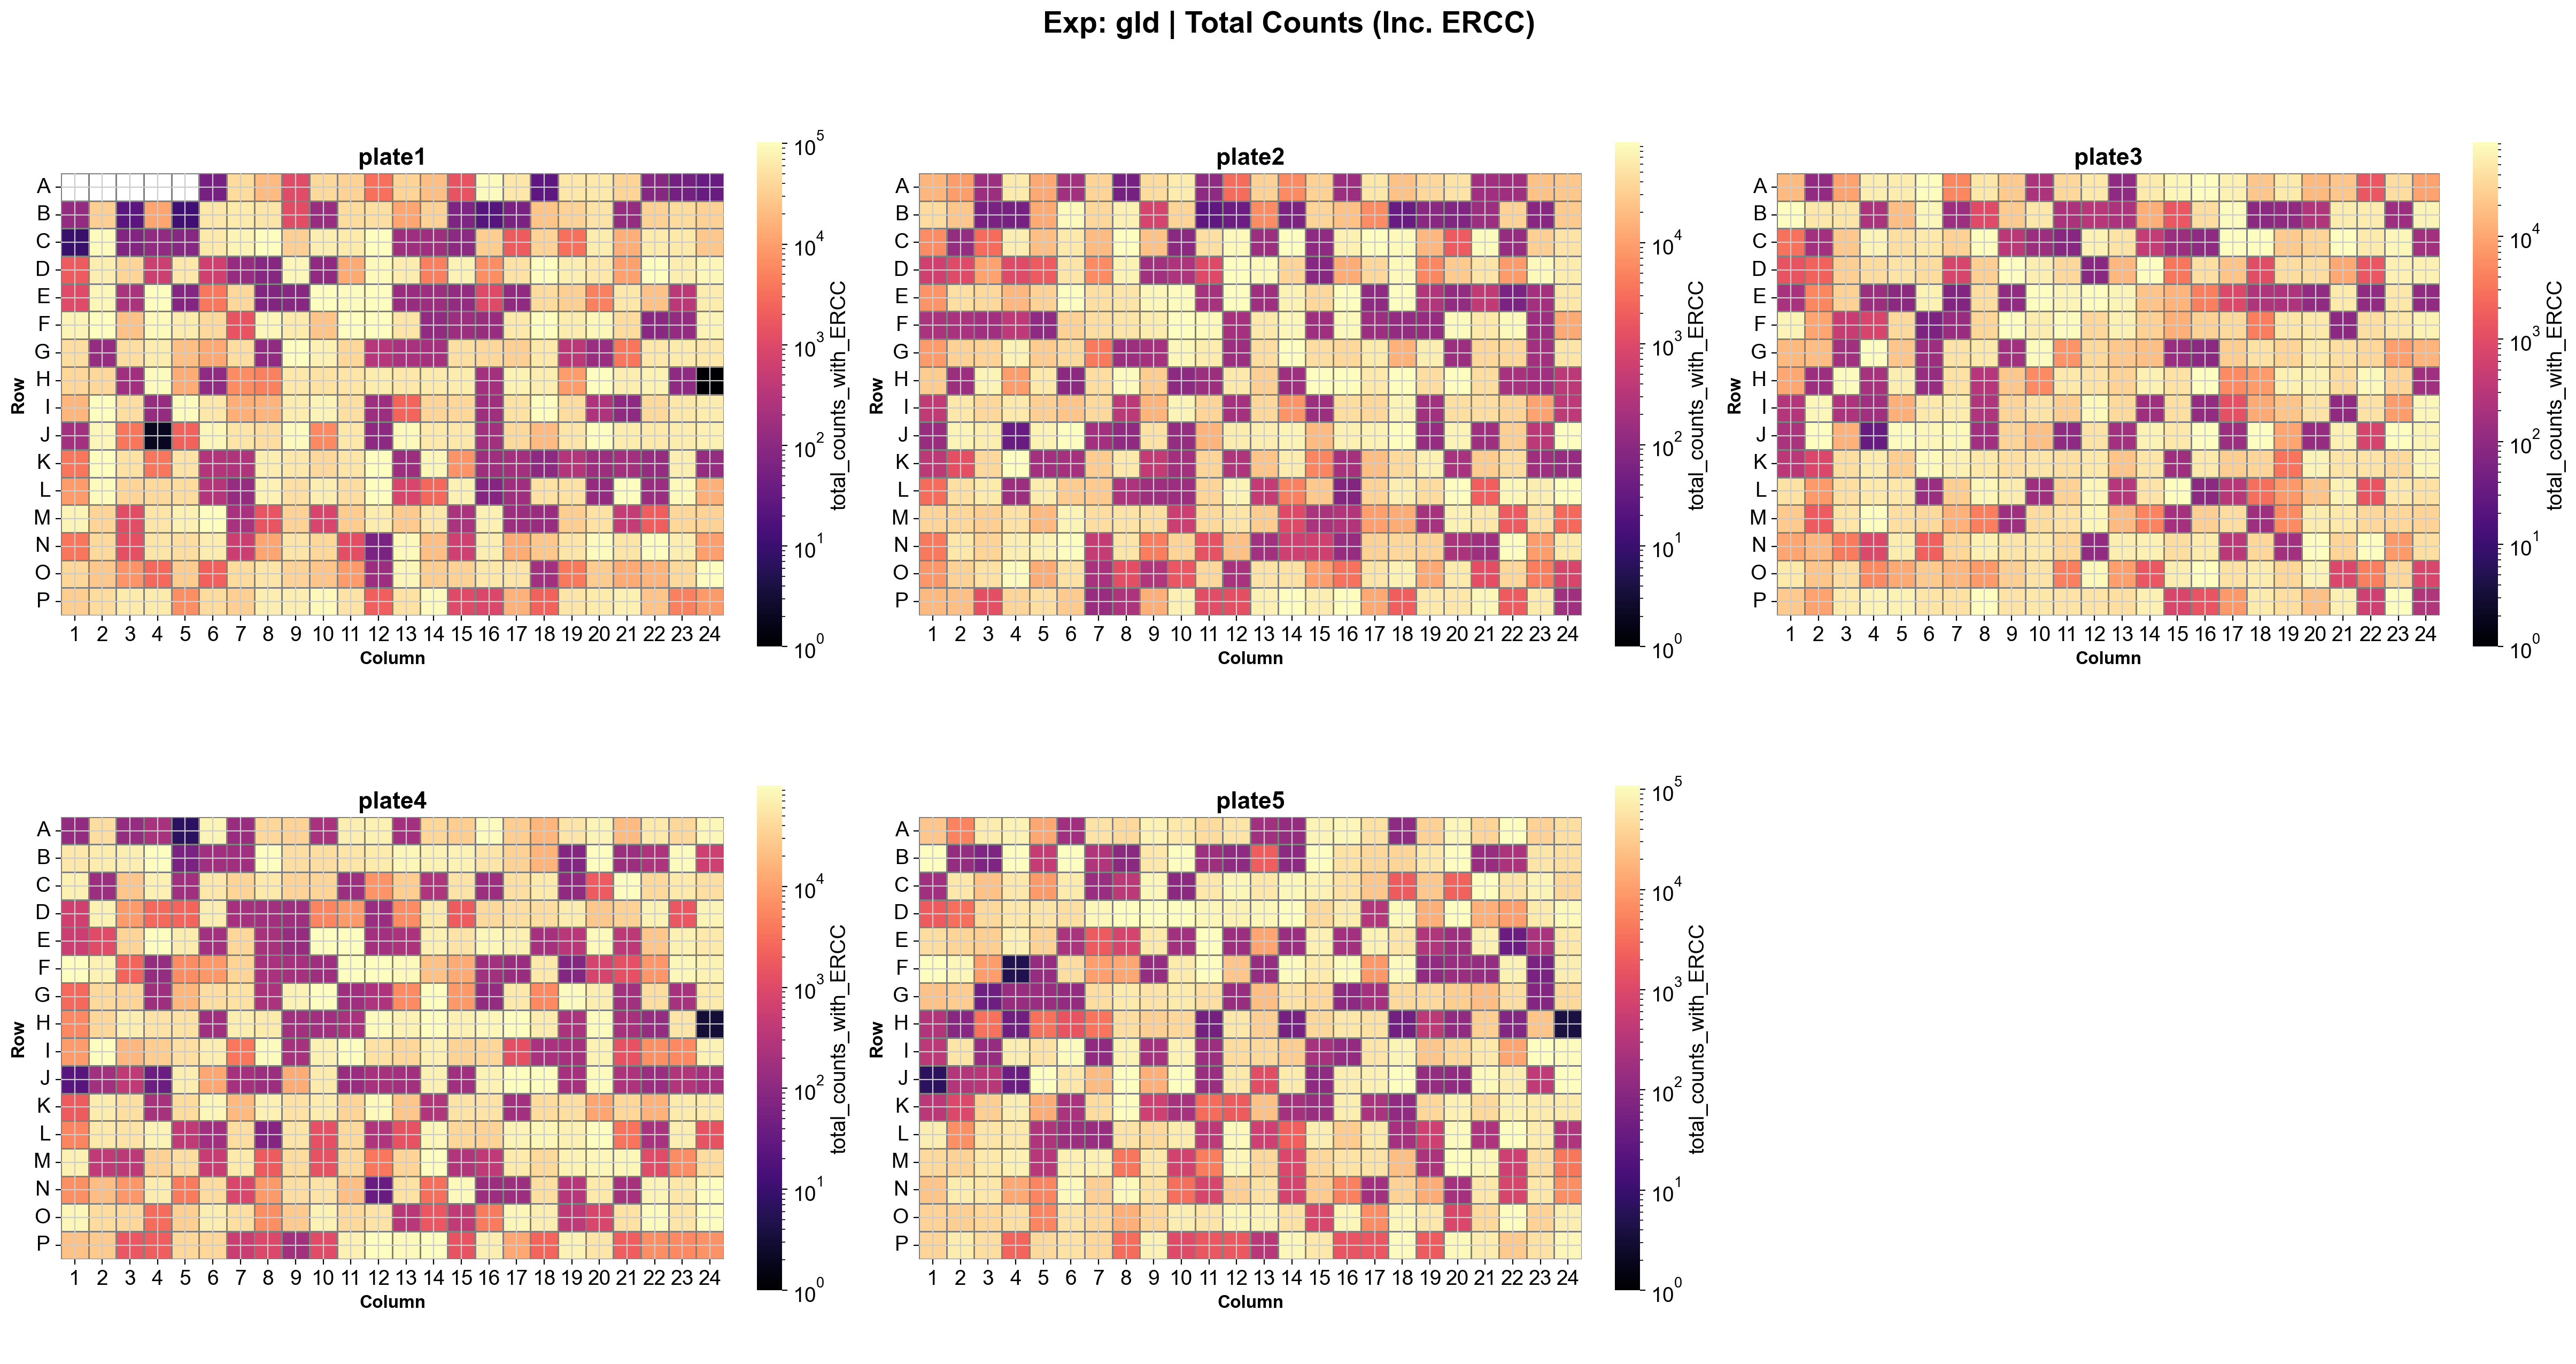

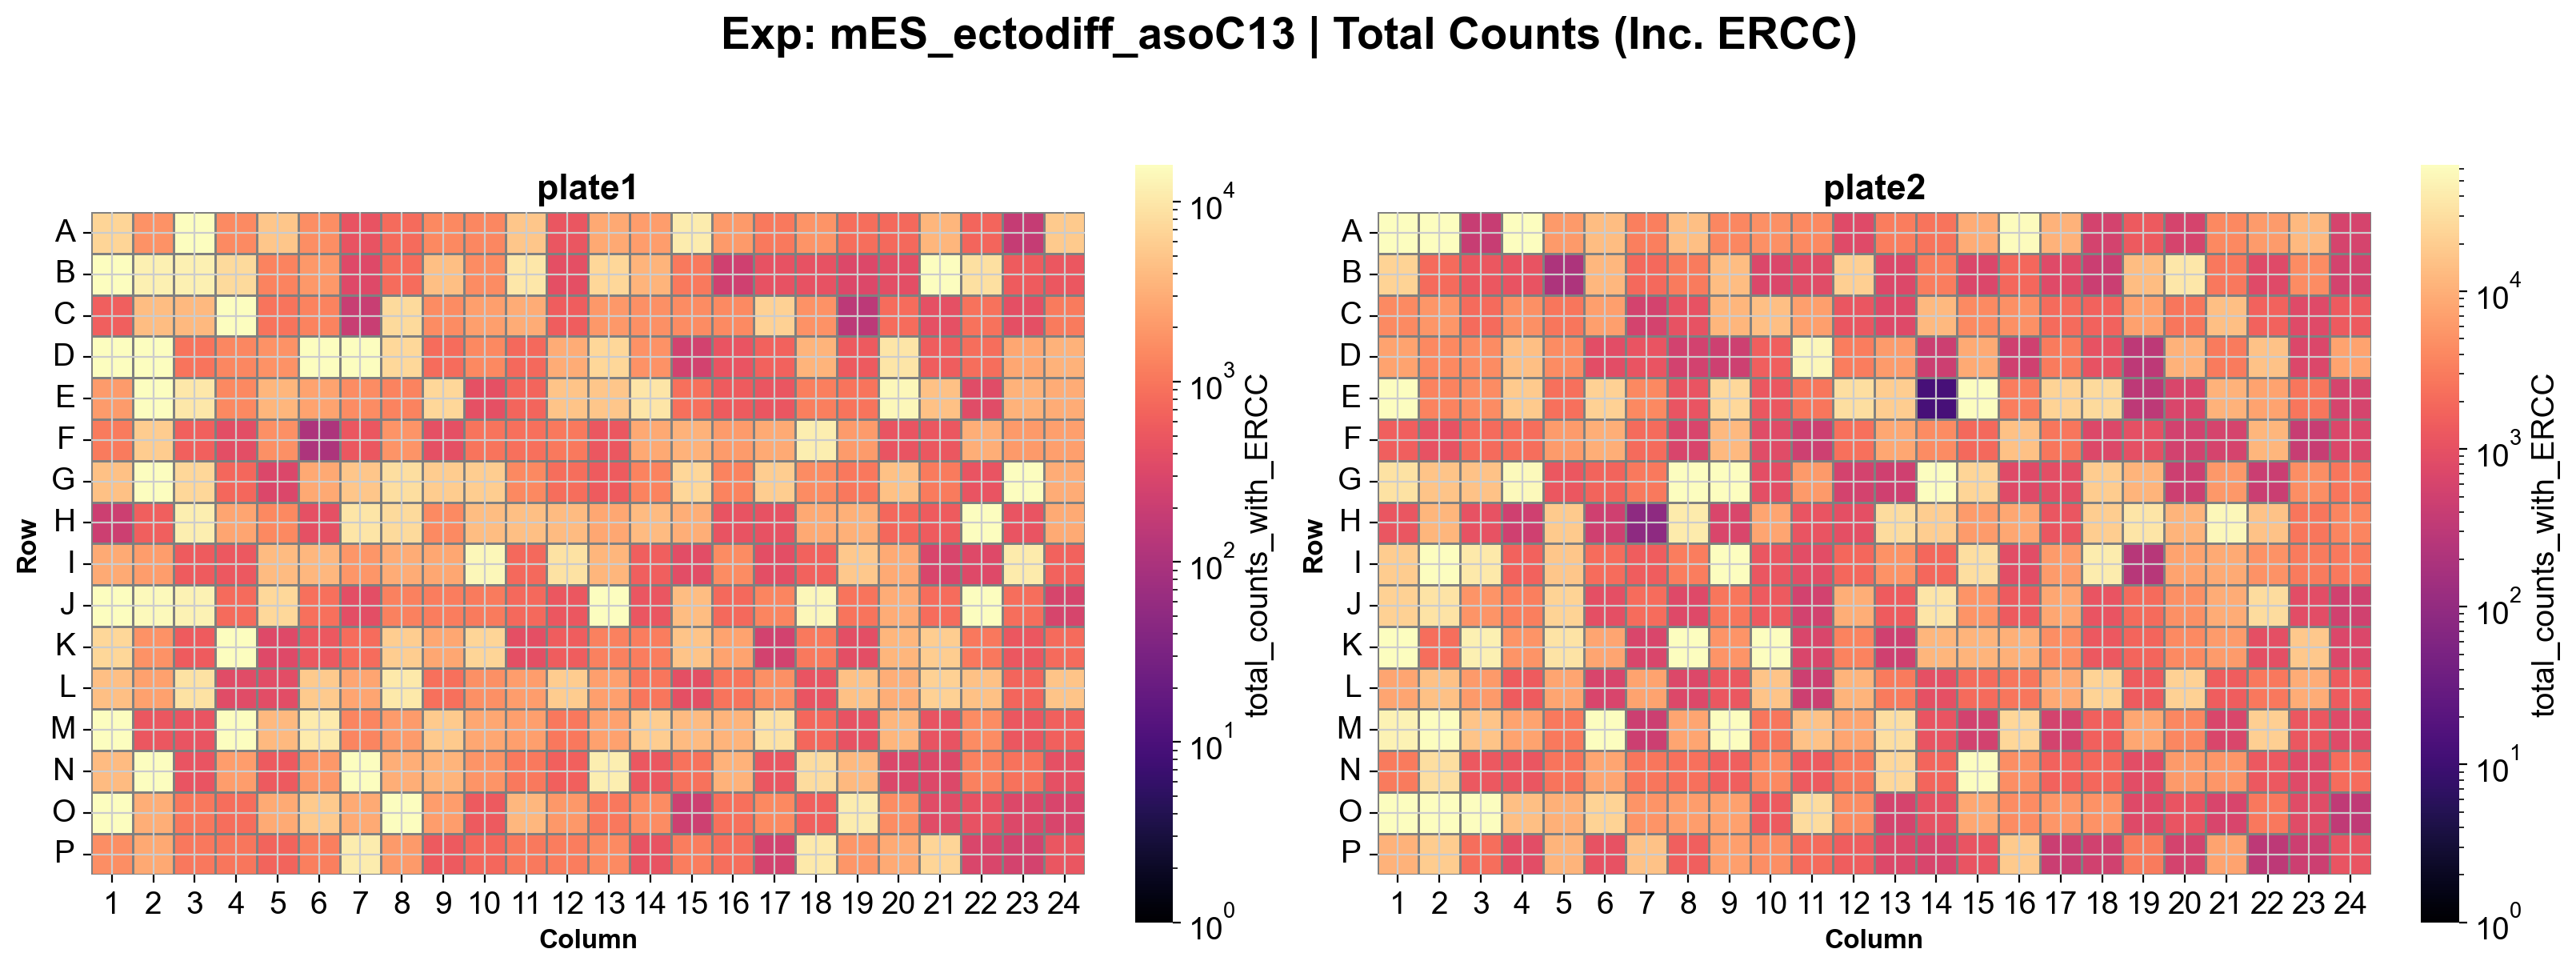

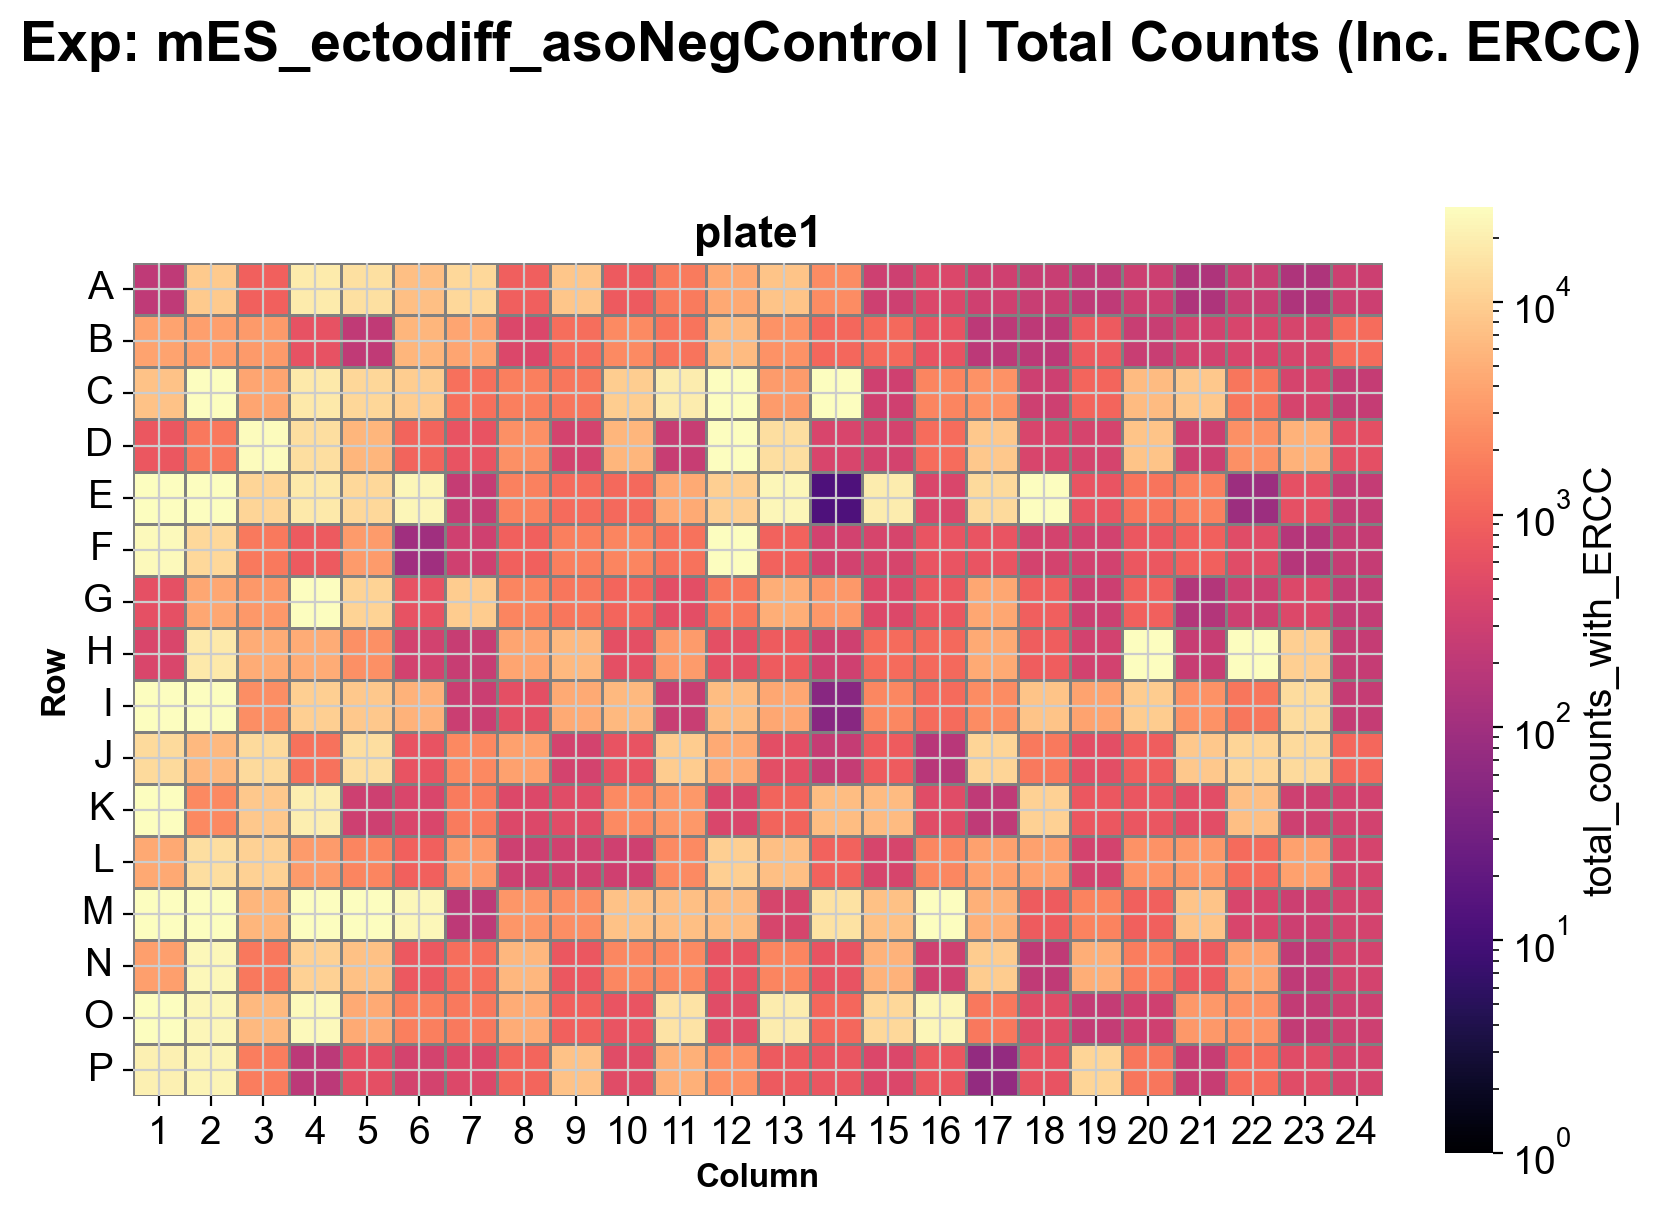

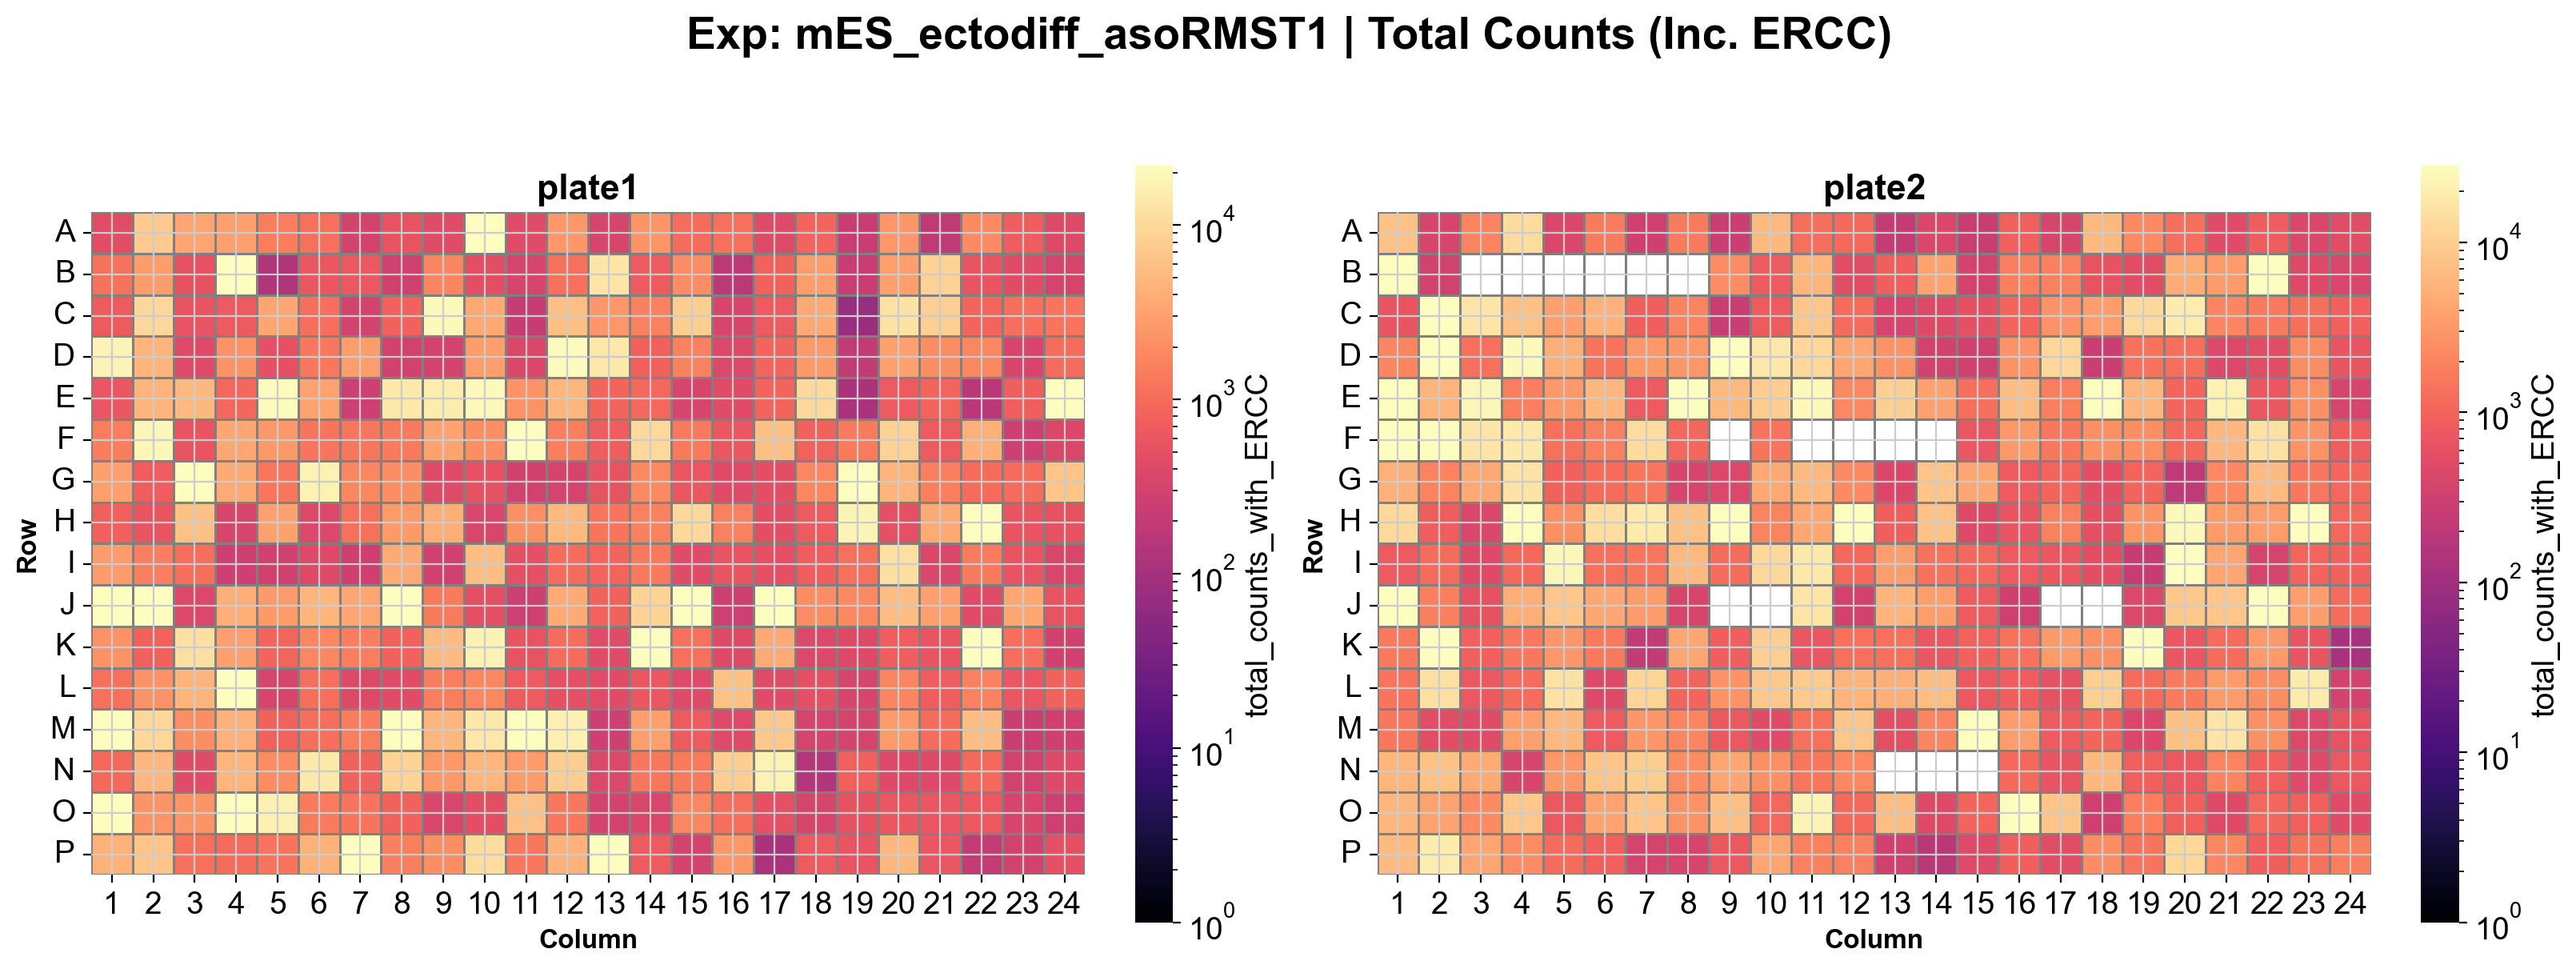

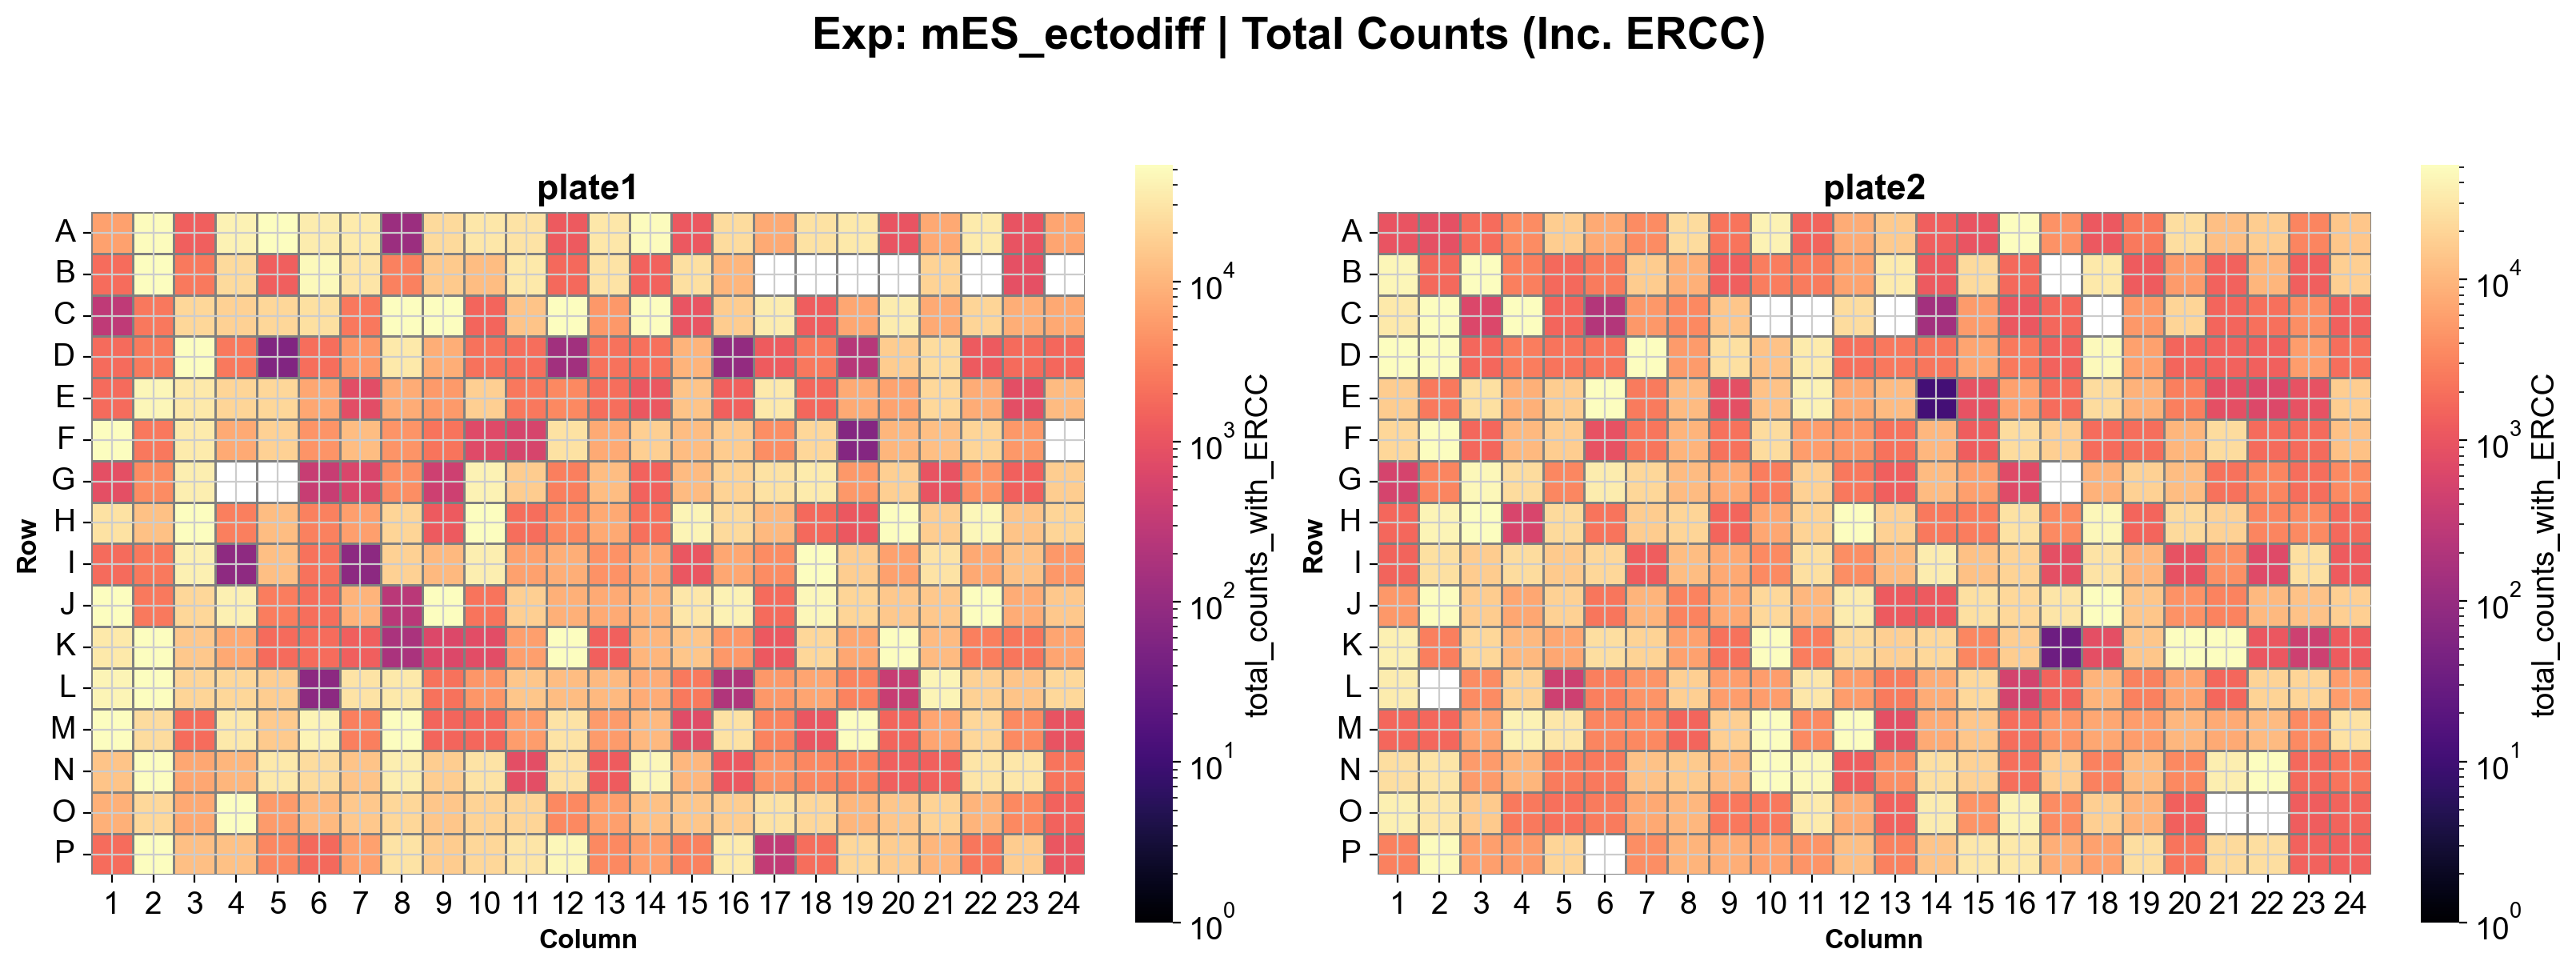

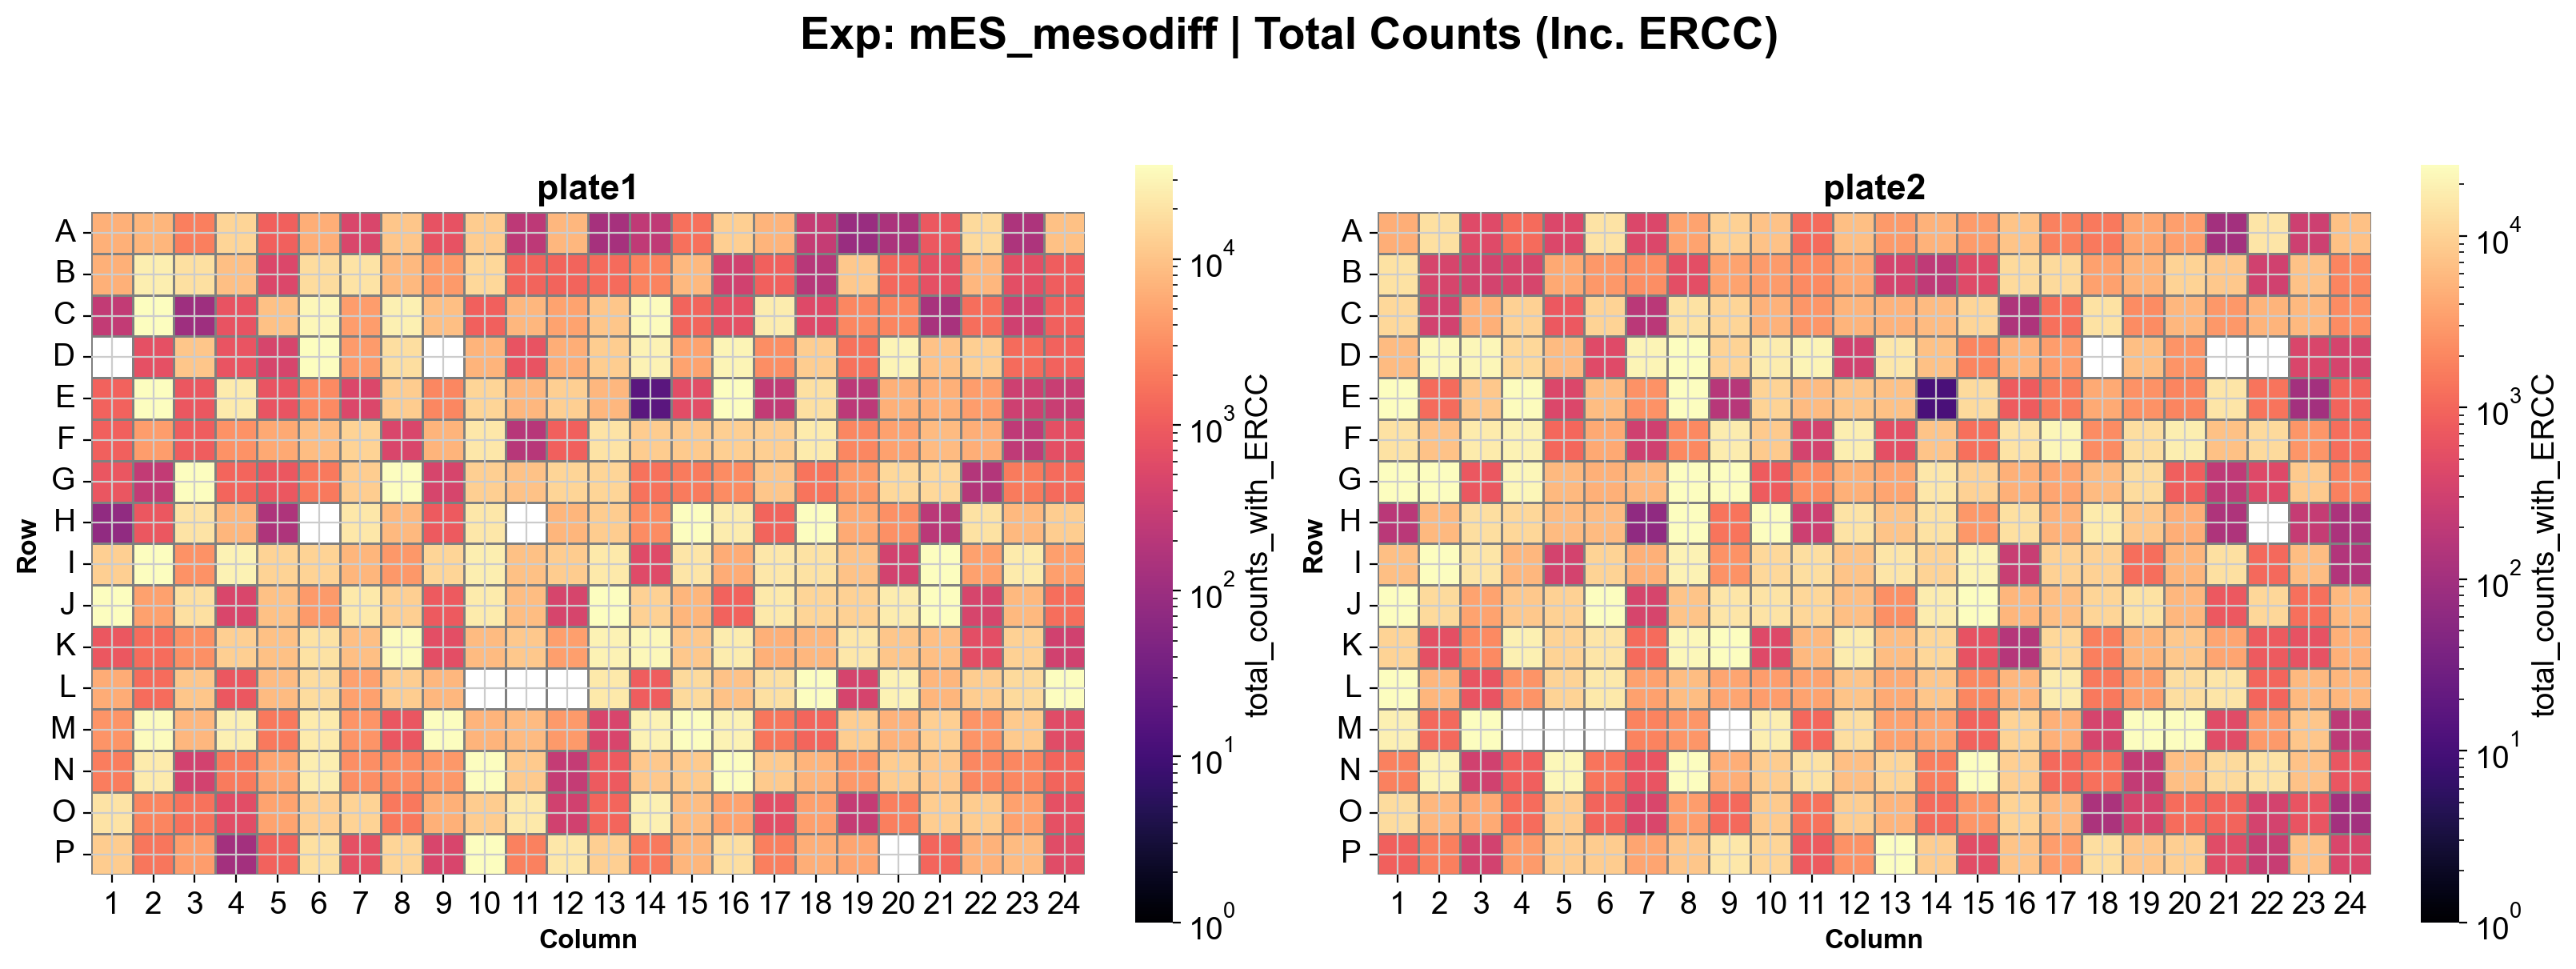

In [16]:
plot_plate_heatmap(adata, 'total_counts_with_ERCC', title_suffix="Total Counts (Inc. ERCC)")

## QC METRICS (WITHOUT ERCC)

Discarding ERCC RNA counts.

In [17]:
# --- DEFINE ERCC GENES ---
# Ensure we capture them correctly 
ercc_mask = adata.var_names.str.startswith('ERCC-')
n_ercc = ercc_mask.sum()
print(f"Detected {n_ercc} ERCC spike-in genes.")

if n_ercc == 0:
    print("WARNING: No ERCC genes found with prefix 'ERCC-'. Check gene names.")
else:
    # --- STATISTICS BEFORE REMOVAL ---
    # We look specifically at empty wells (if they exist) and mESC
    if 'Empty' in adata.obs['sample_type'].values:
        empty_subset = adata[adata.obs['sample_type'] == 'Empty']
        mean_before = empty_subset.obs['total_counts'].mean()
        median_before = empty_subset.obs['total_counts'].median()
        
        # Calculate what % of the Empty well signal is ERCC
        ercc_counts = np.sum(empty_subset[:, ercc_mask].X, axis=1)
        mean_ercc_counts = np.mean(ercc_counts)
        
        print(f"\n--- PRE-FILTERING DATA EMPTY WELLS ---")
        print(f"Mean Total Counts: {mean_before:.2f}")
        print(f"Mean ERCC Counts:  {mean_ercc_counts:.2f}")
        print(f"ERCC Contribution: {(mean_ercc_counts/mean_before)*100:.2f}%")
    
    # --- FILTERING ---
    print("\n... Removing ERCC genes ...")
    # Invert mask to keep non-ERCC
    adata = adata[:, ~ercc_mask].copy()
    
    # --- RECALCULATE QC METRICS without ERCC---
    # This updates 'total_counts' to reflect ONLY endogenous RNA
    sc.pp.calculate_qc_metrics(
        adata, 
        qc_vars=['mt'], # ERCC is gone
        percent_top=None, 
        log1p=False, 
        inplace=True
    )
    
    # --- STATISTICS AFTER REMOVAL ---
    if 'Empty' in adata.obs['sample_type'].values:
        empty_subset_after = adata[adata.obs['sample_type'] == 'Empty']
        mean_after = empty_subset_after.obs['total_counts'].mean()
        
        print(f"\n--- POST-FILTERING DIAGNOSTICS (EMPTY WELLS) ---")
        print(f"Mean Total Counts (Endogenous Only): {mean_after:.2f}")
        
        # --- CHECK ---
        delta = mean_before - mean_after
        print(f"\n--- CONCLUSION ---")
        print(f"Signal Removed (Calibration): {delta:.2f}")
        print(f"Residual Noise (Ambient RNA): {mean_after:.2f}")
        
        if mean_after < mean_before * 0.1:
            print(">> SUCCESS: Empty wells were mostly ERCC. Residual noise is low.")
        elif mean_after > mean_before * 0.9:
            print(">> WARNING: Filtering ERCC had little effect. Empty wells contain mostly Ambient RNA (or no ERCC were added).")

Detected 92 ERCC spike-in genes.

--- PRE-FILTERING DATA EMPTY WELLS ---
Mean Total Counts: 1514.27
Mean ERCC Counts:  474.00
ERCC Contribution: 31.30%

... Removing ERCC genes ...

--- POST-FILTERING DIAGNOSTICS (EMPTY WELLS) ---
Mean Total Counts (Endogenous Only): 1040.27

--- CONCLUSION ---
Signal Removed (Calibration): 474.00
Residual Noise (Ambient RNA): 1040.27


## HEATMAPS (WITHOUT ERCC)

Now we observe the empty wells in the experiment.

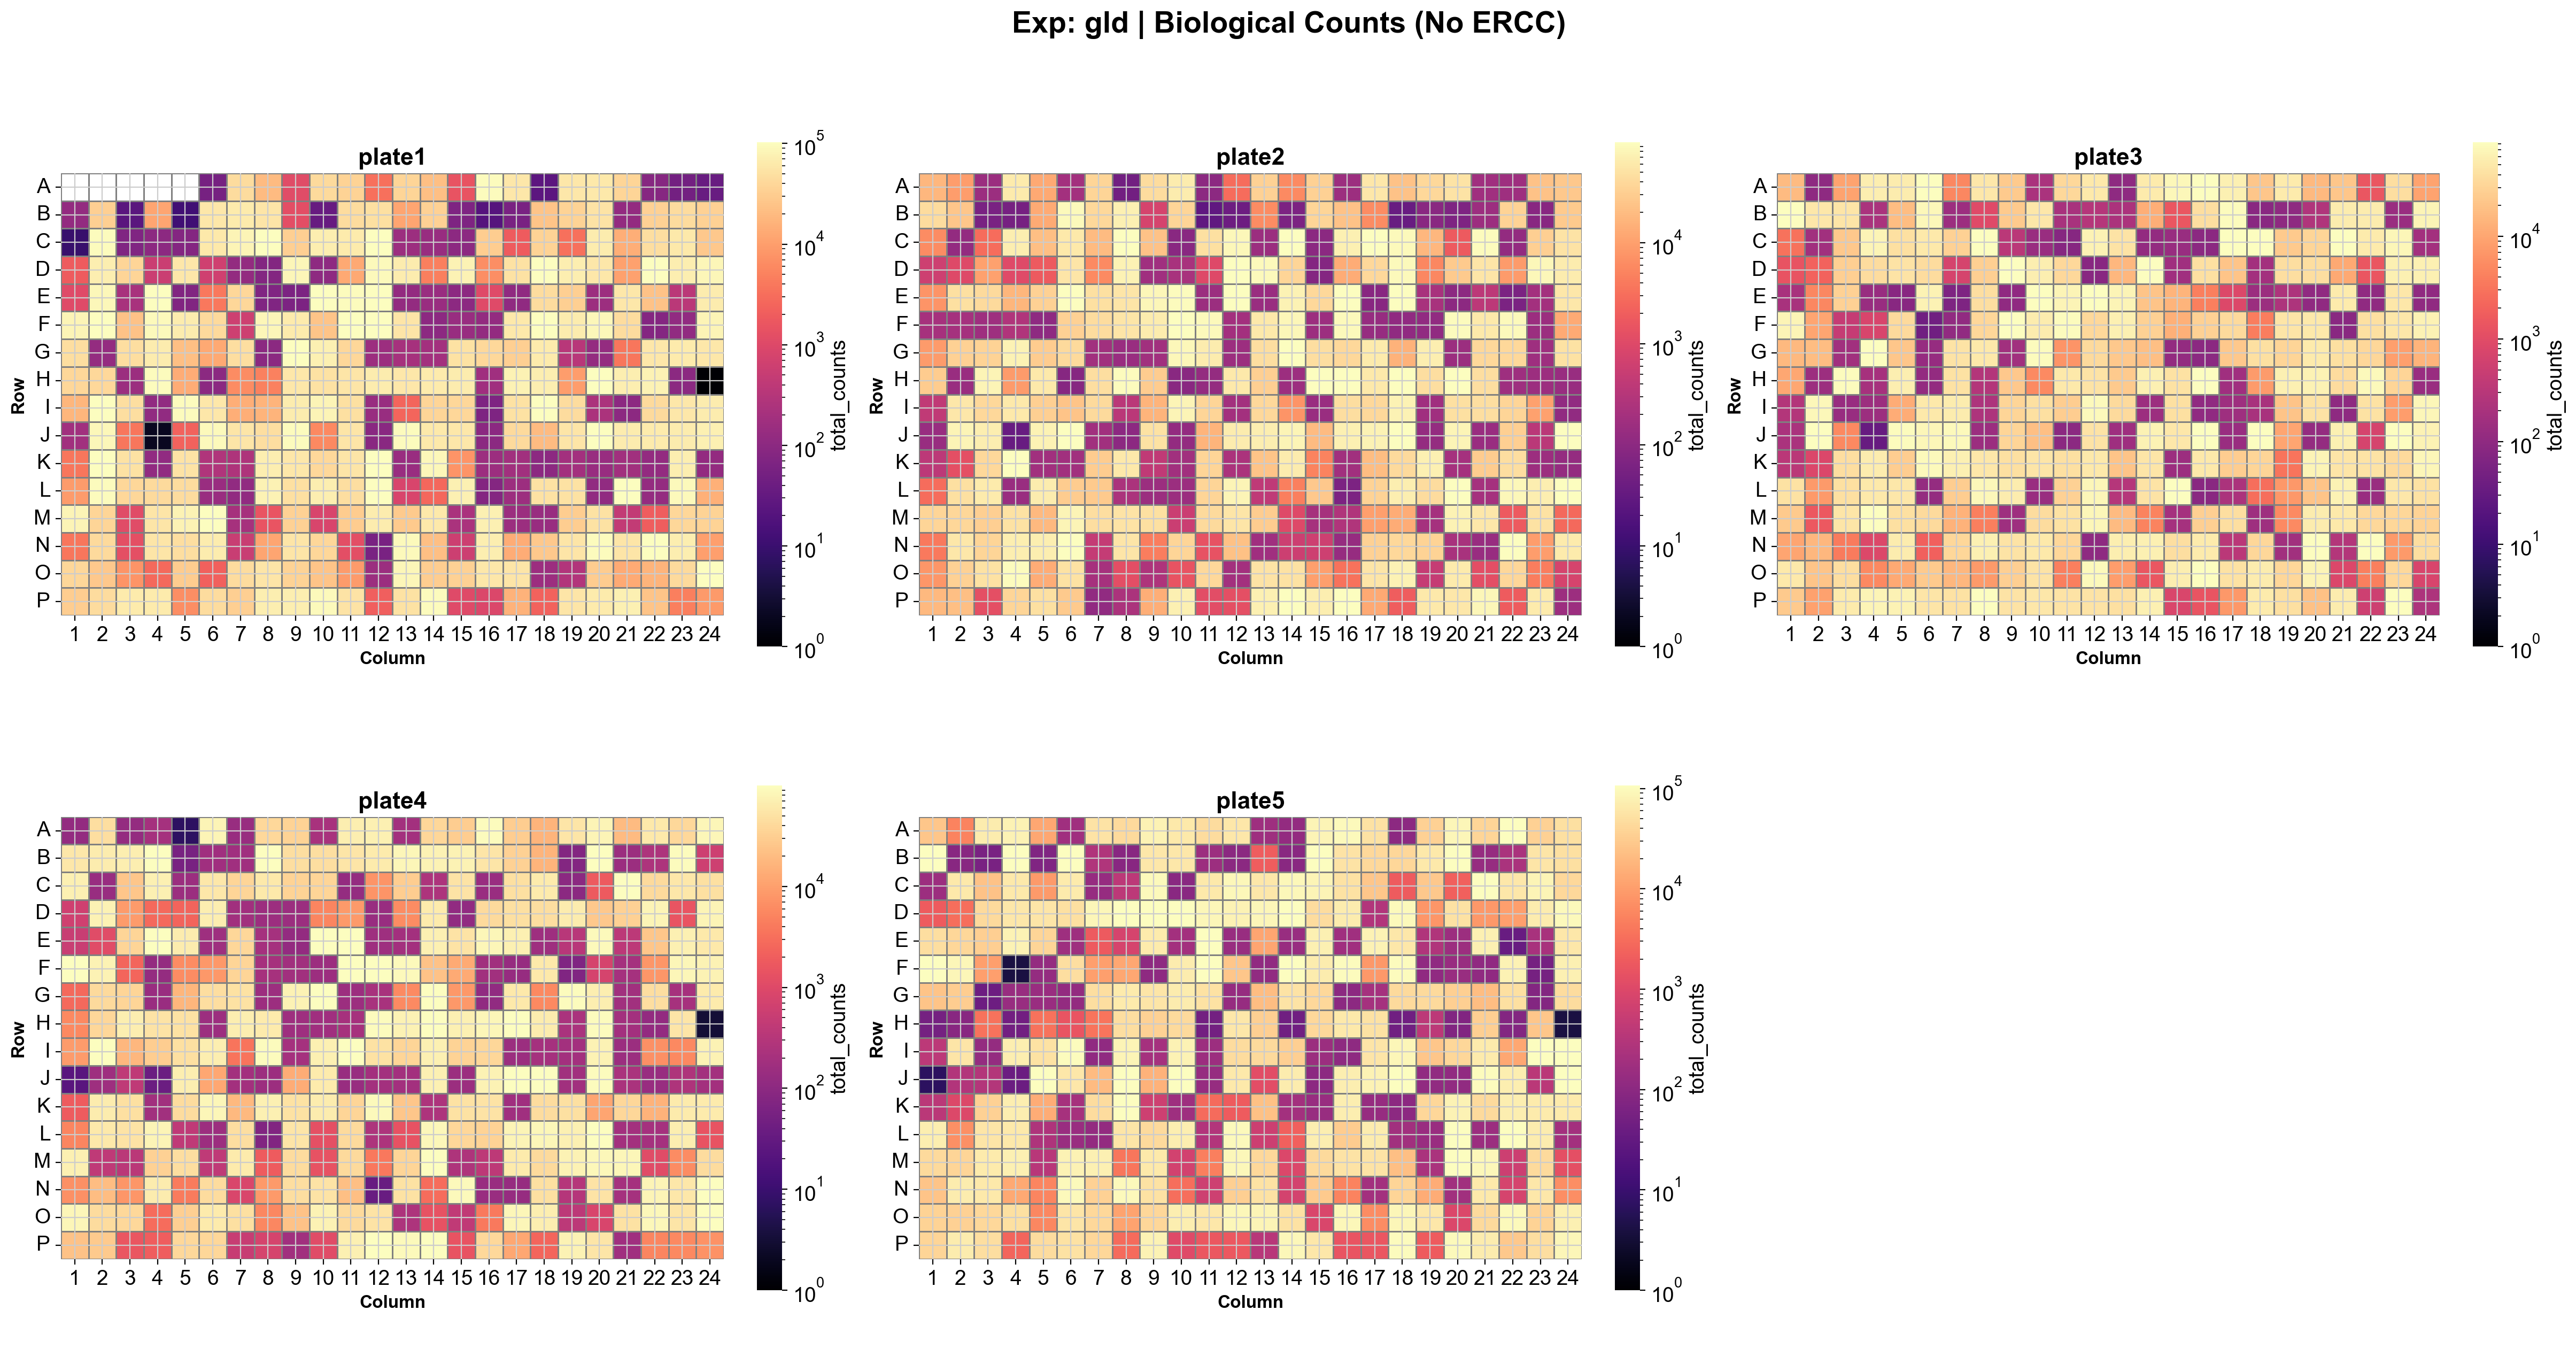

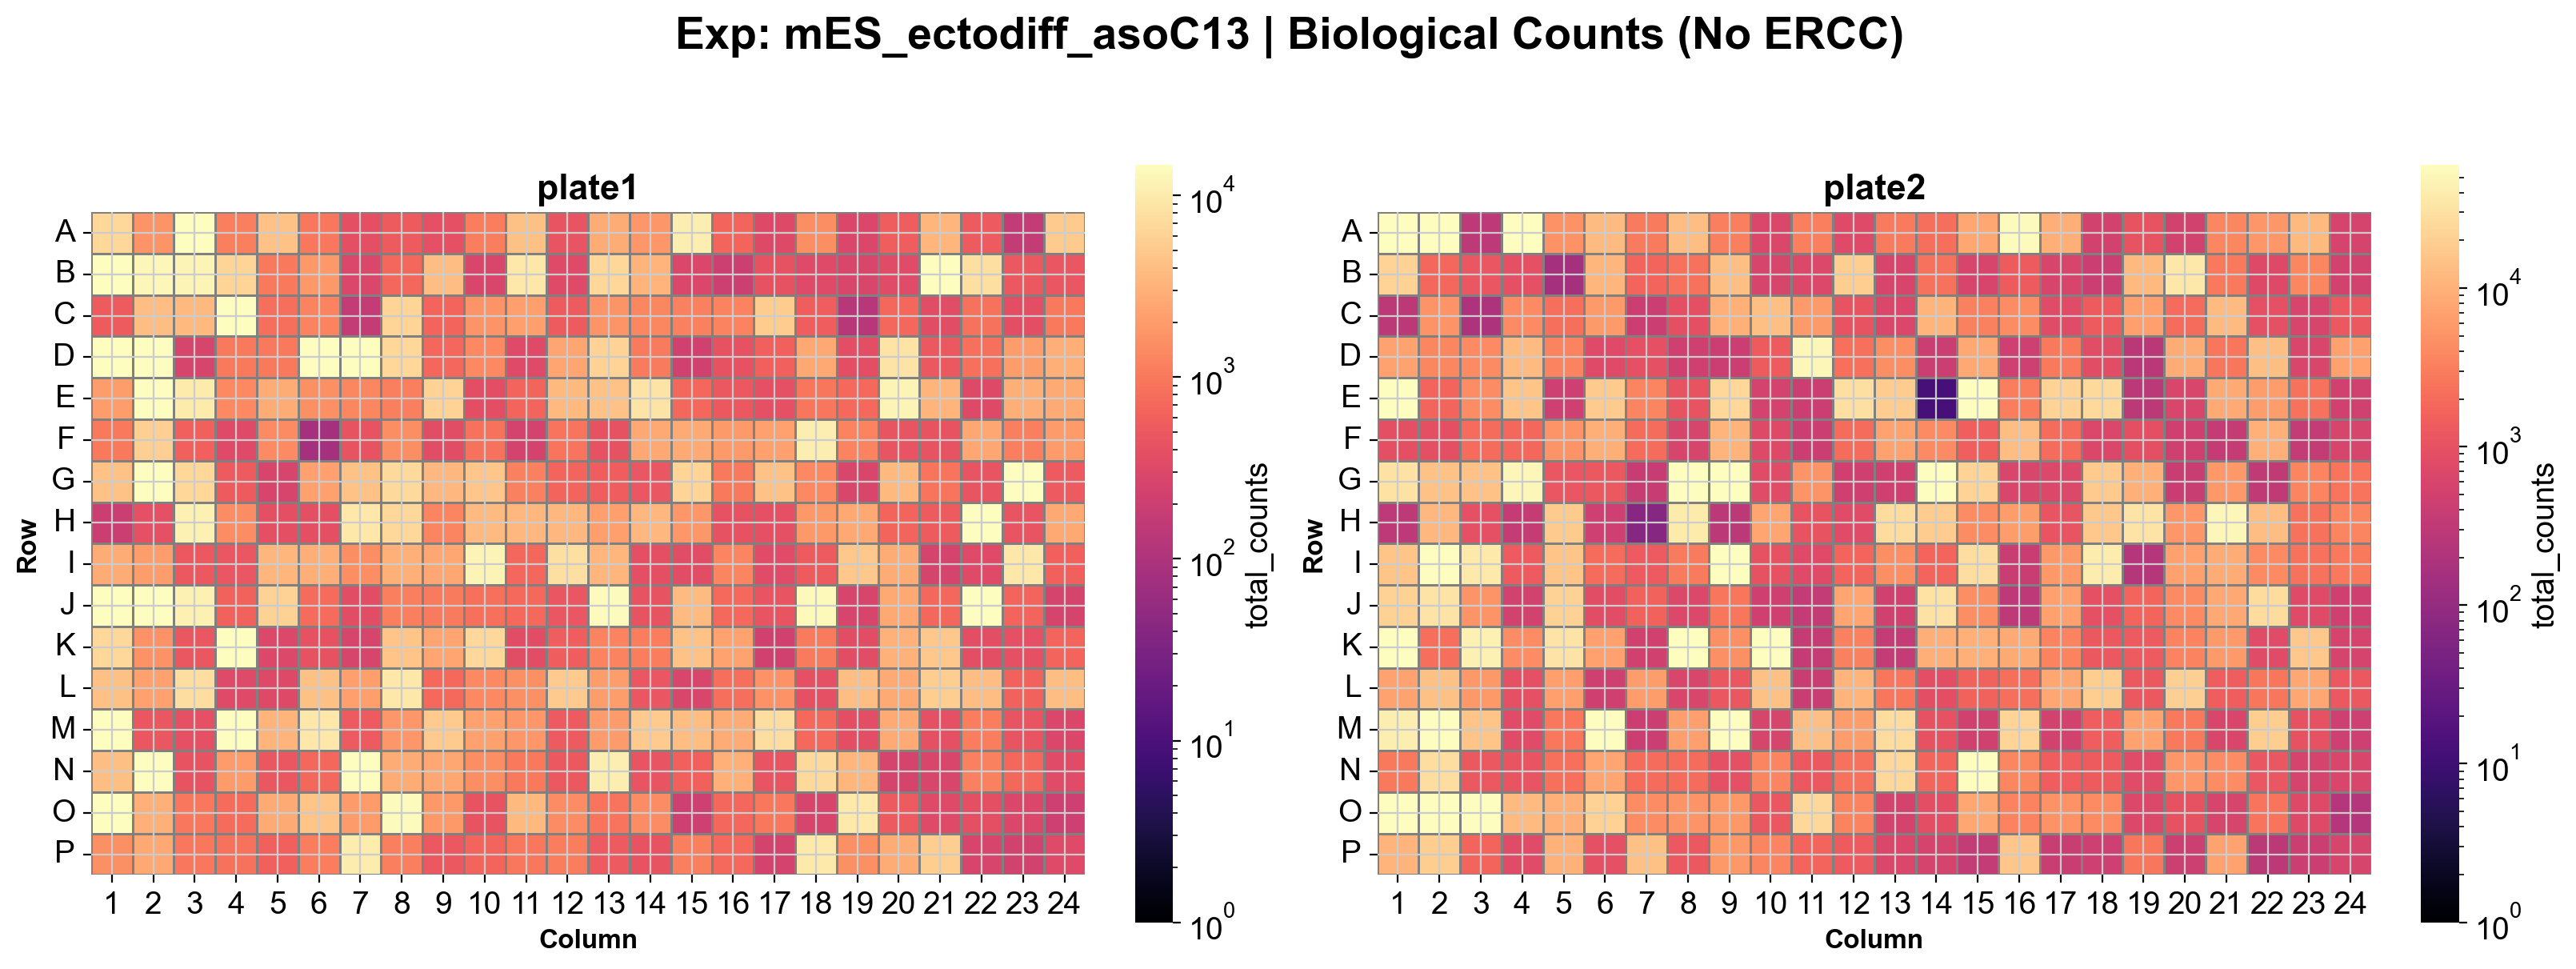

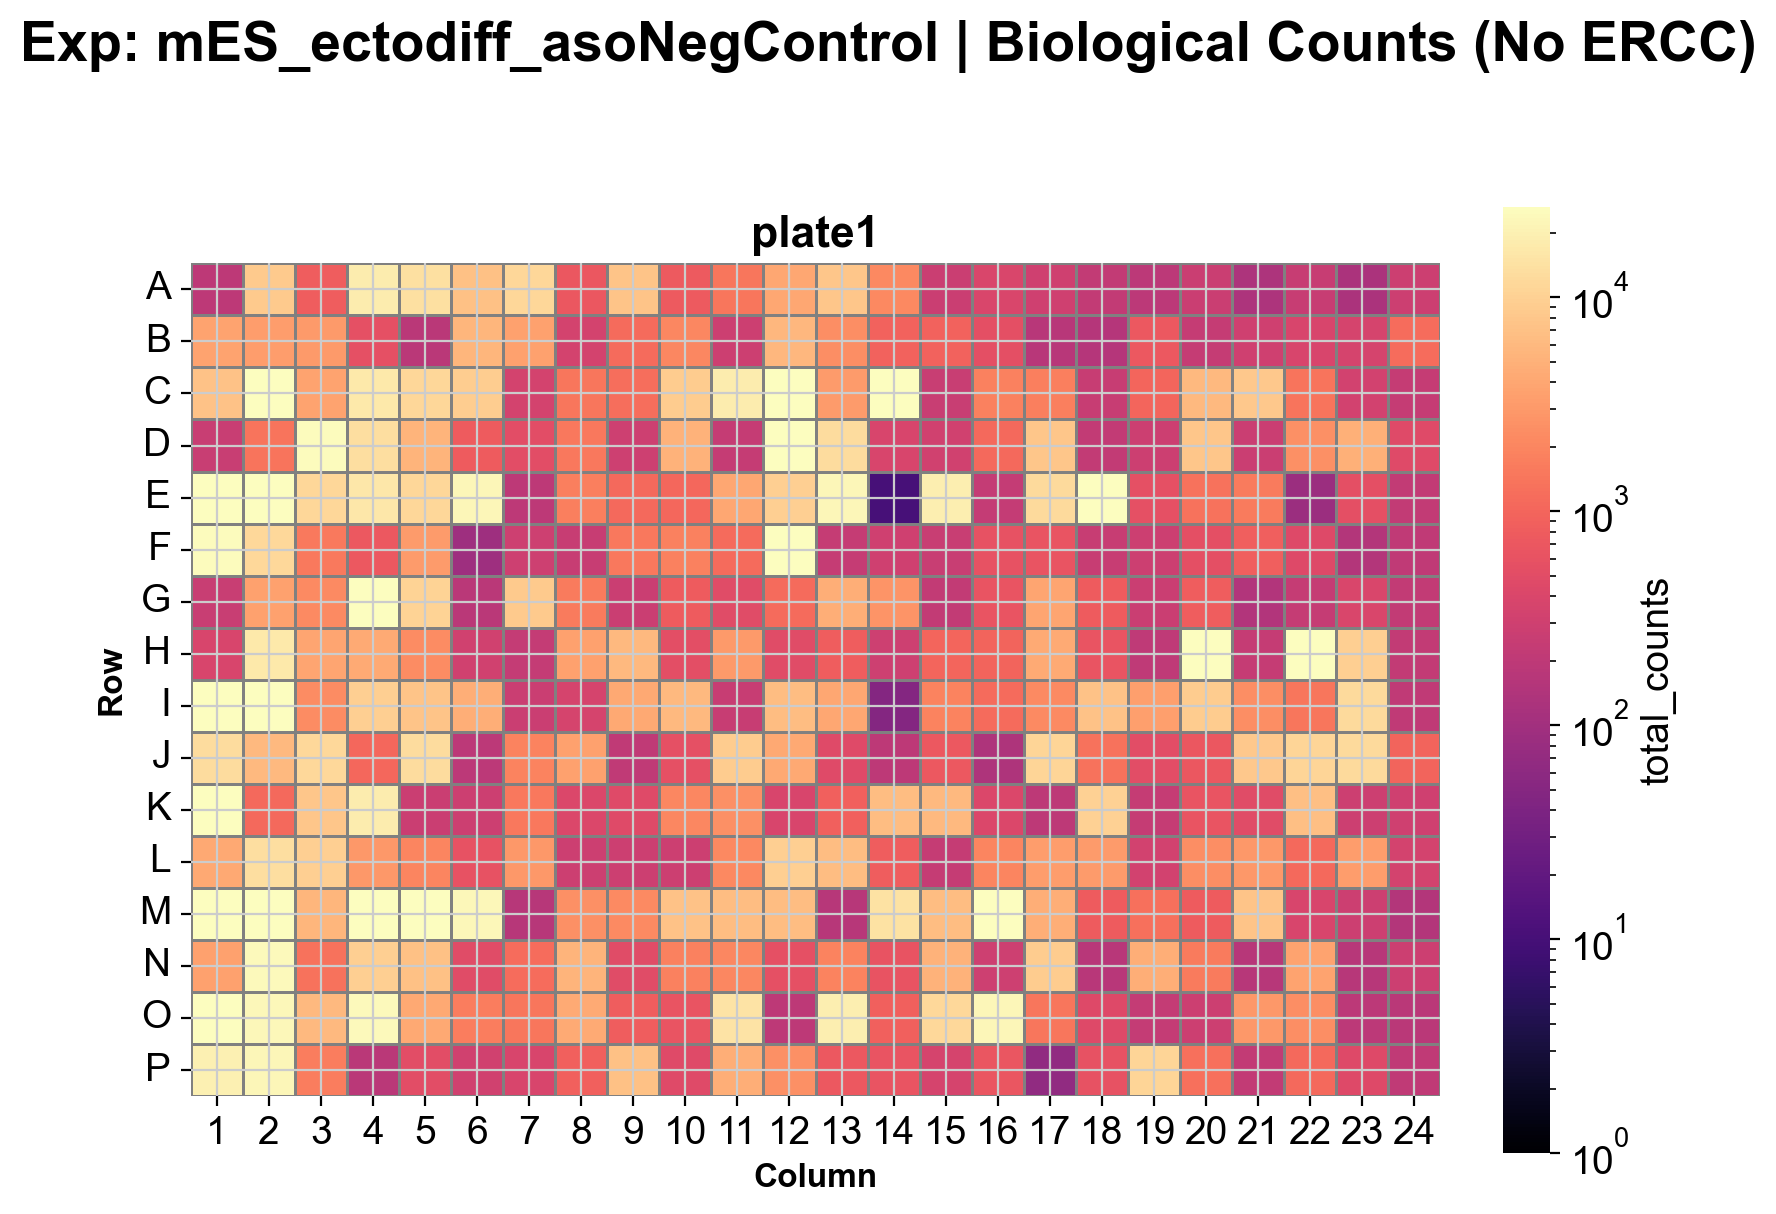

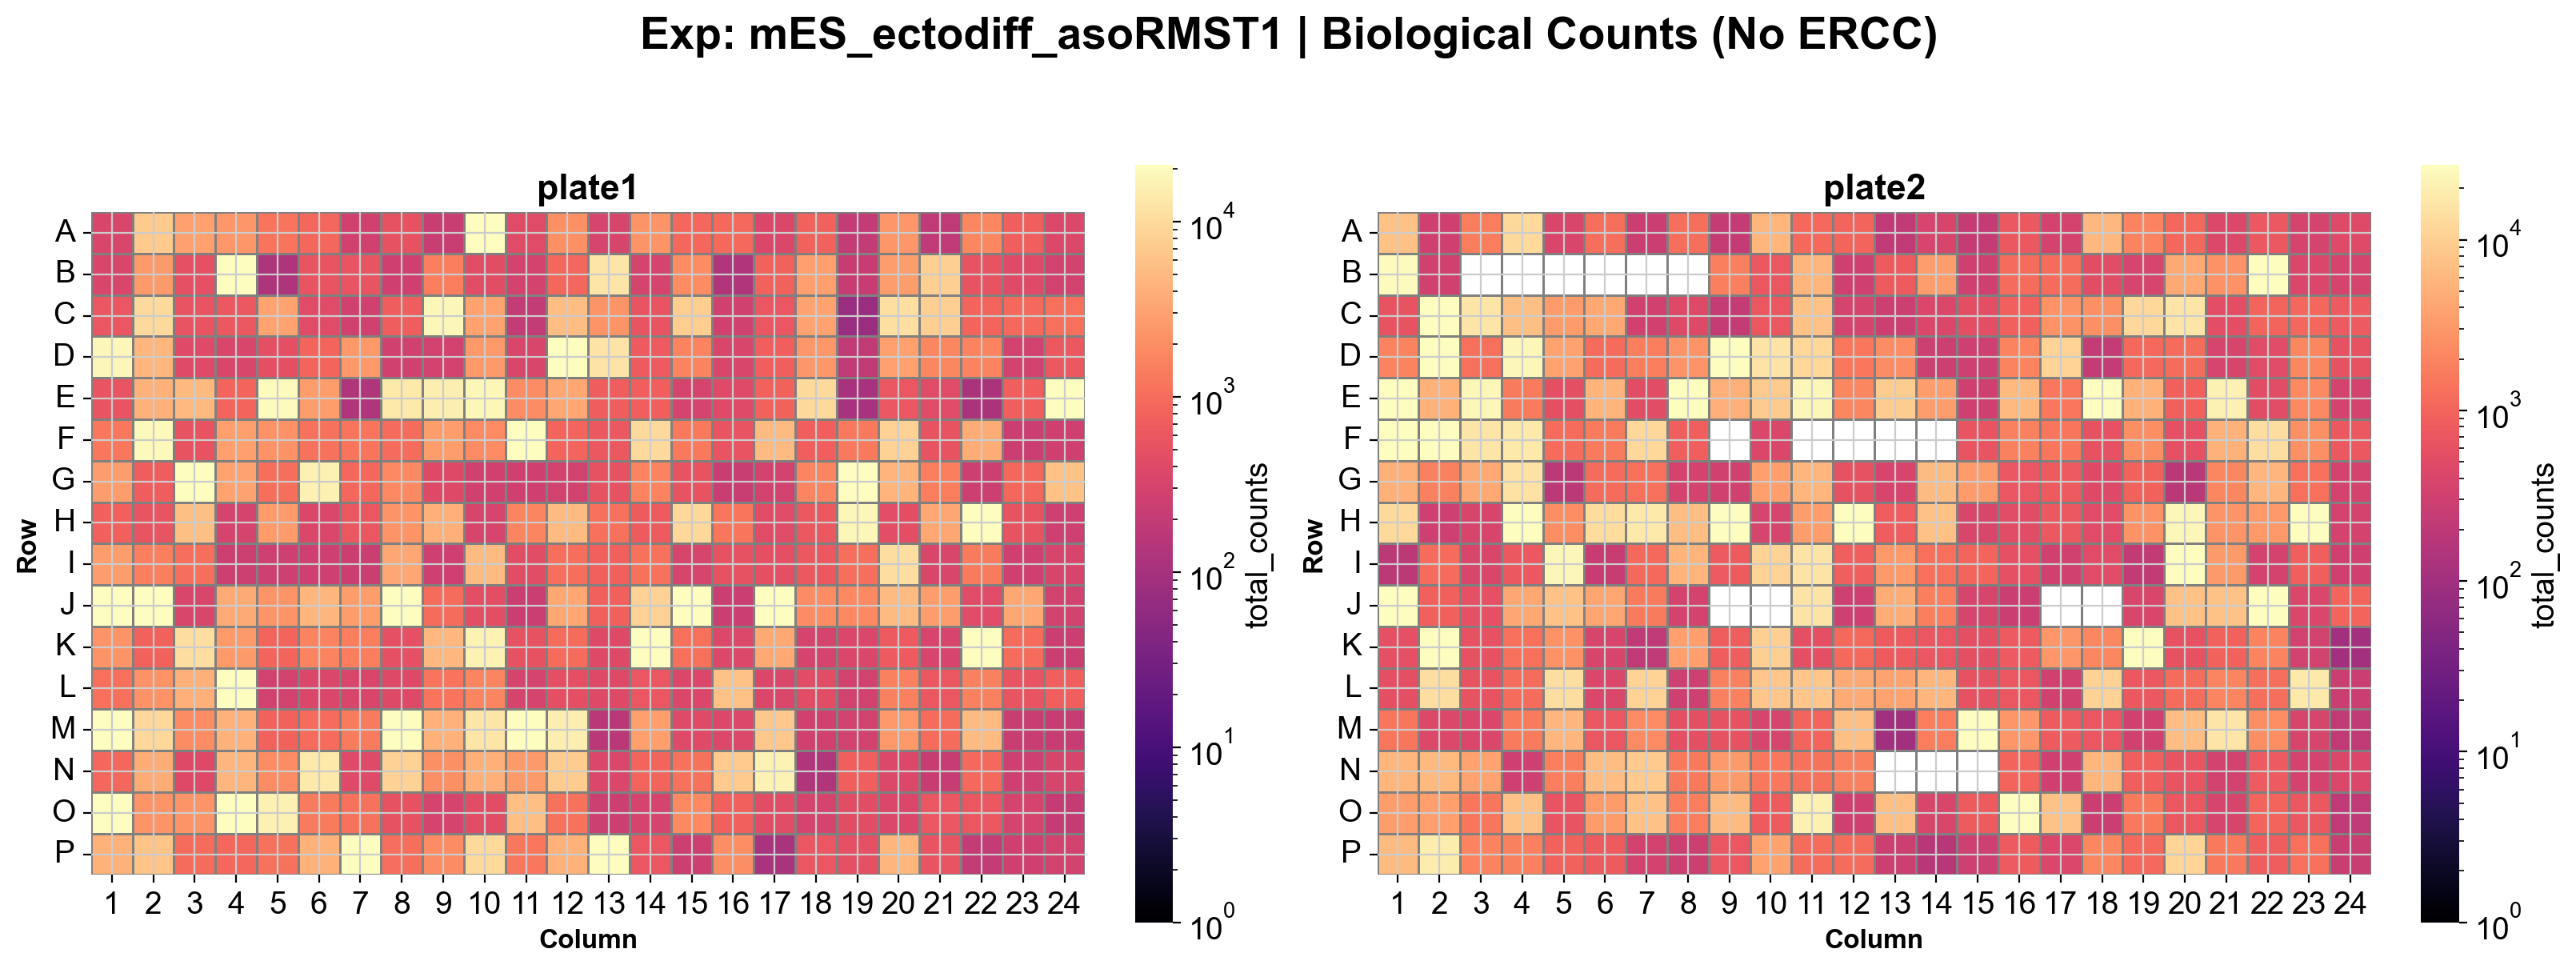

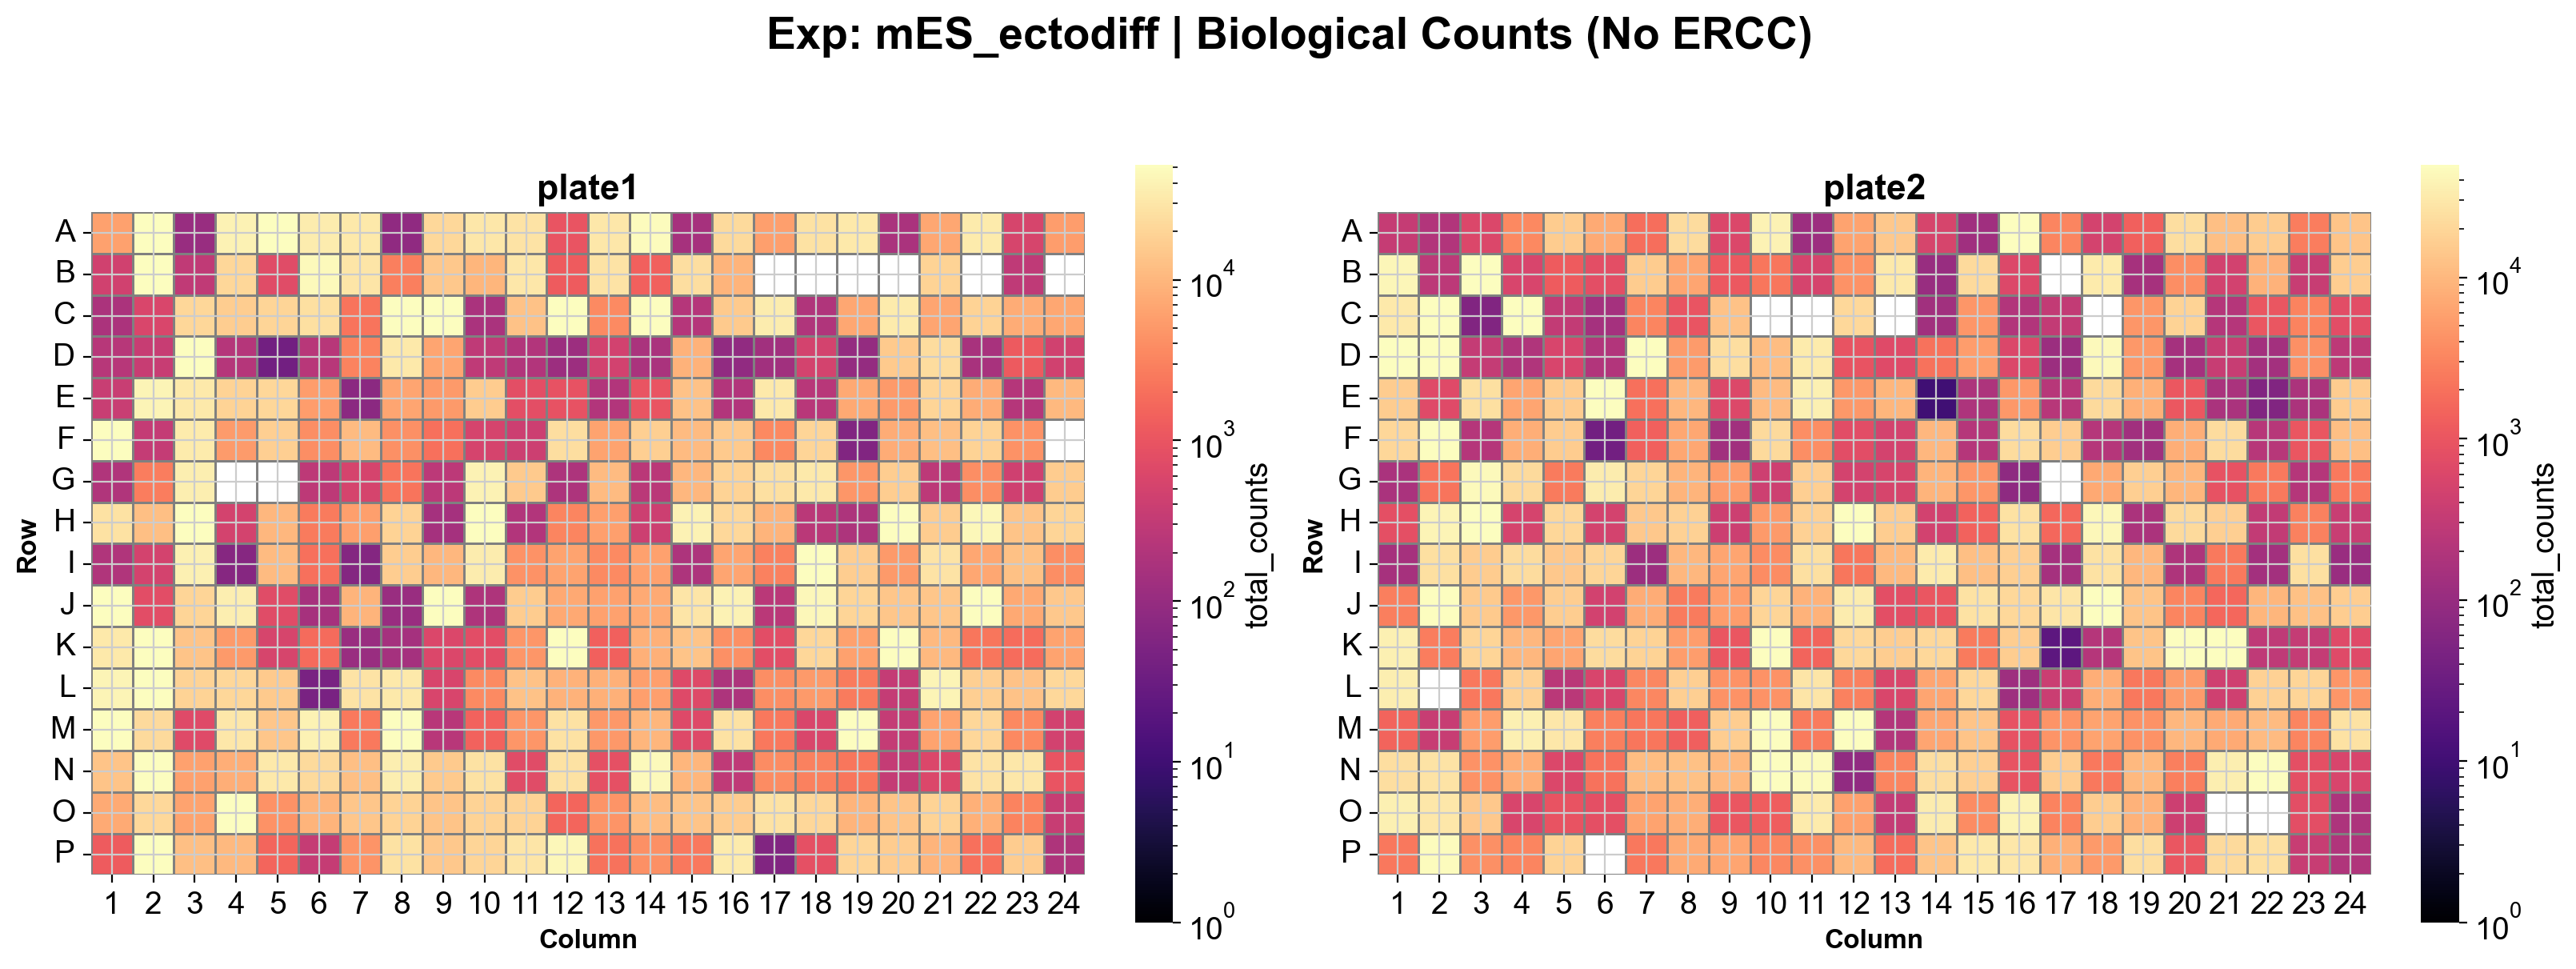

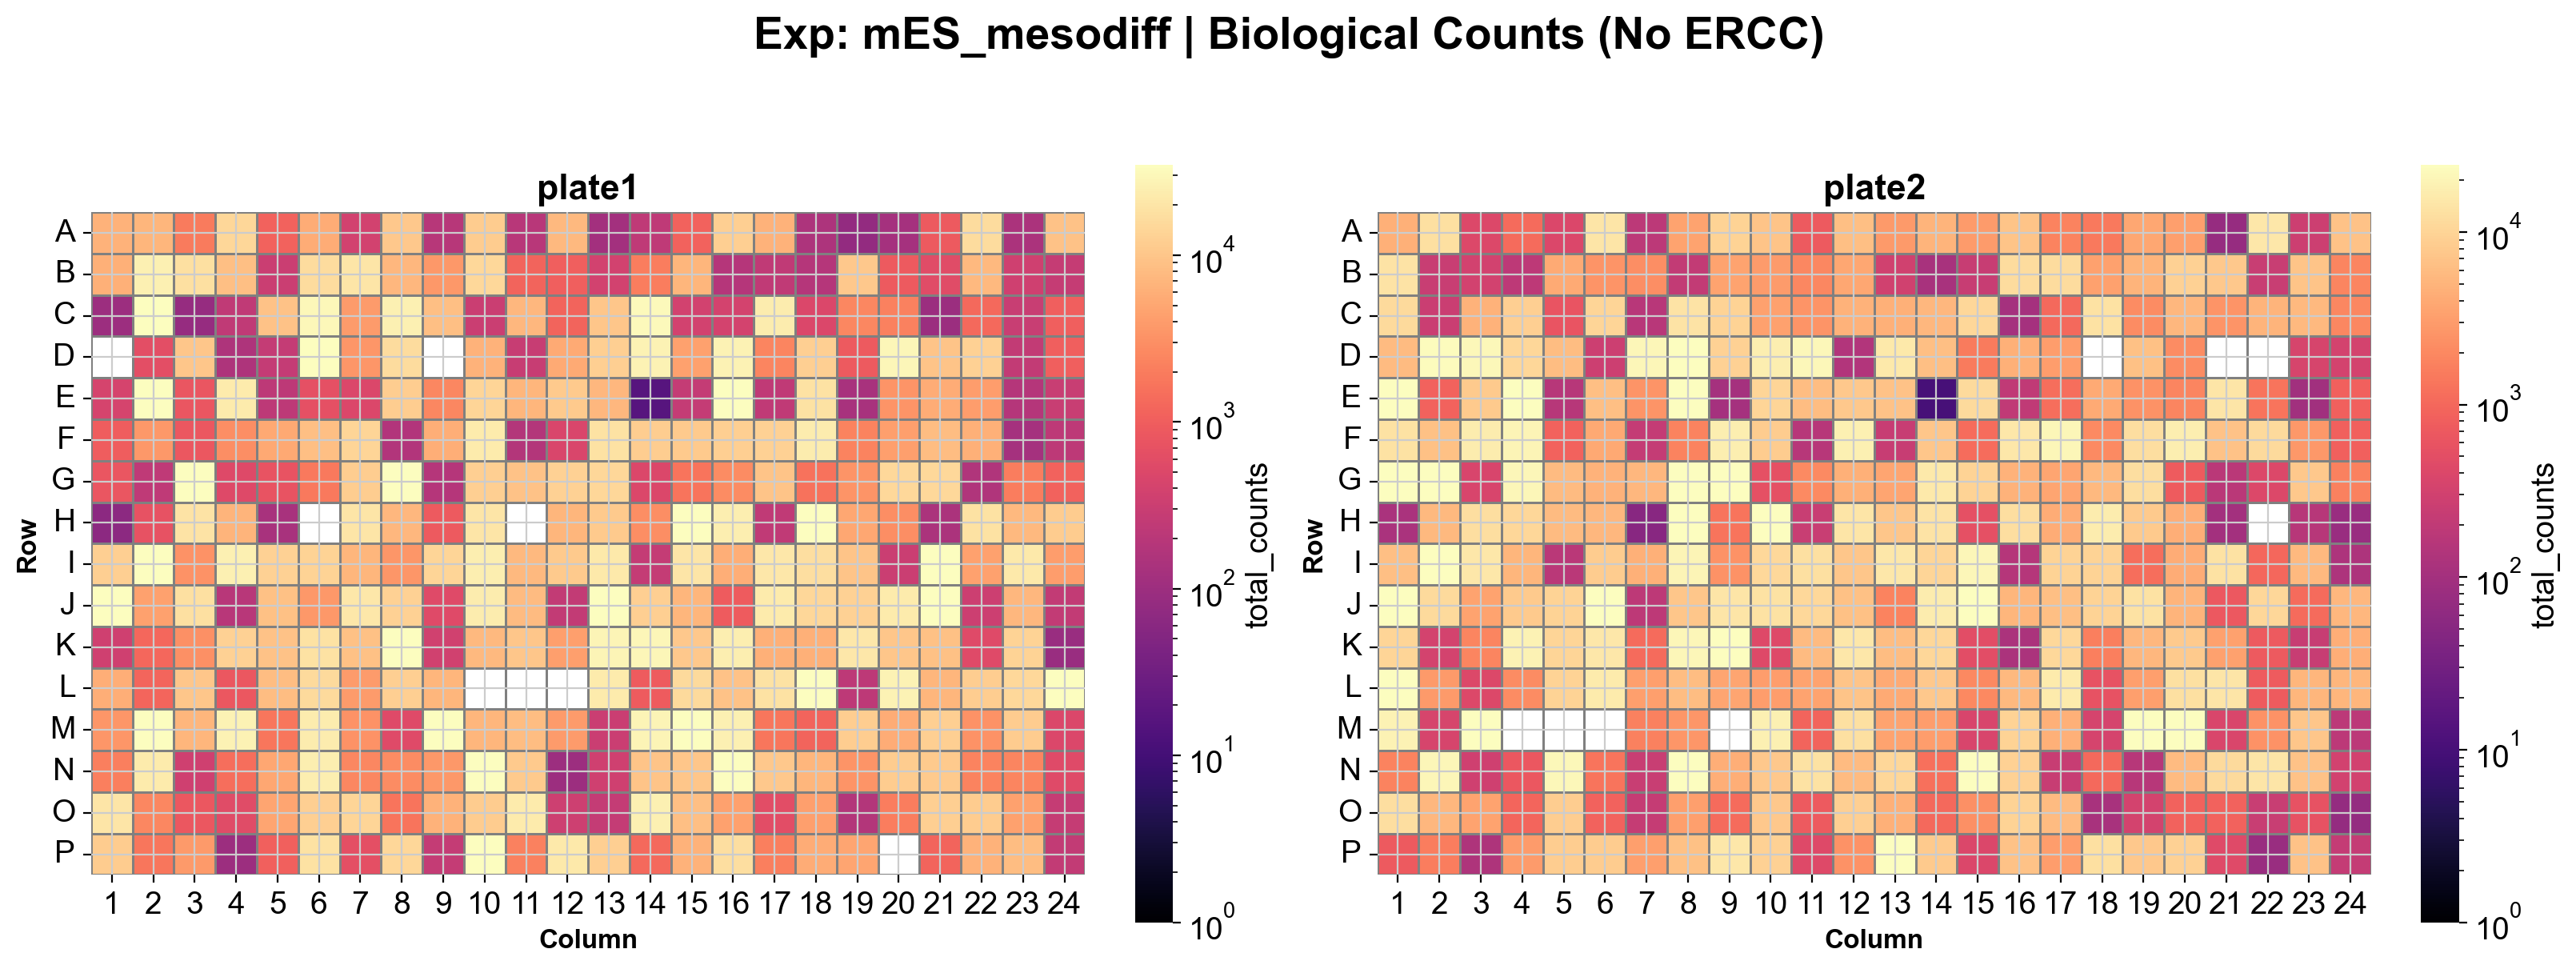

In [18]:
plot_plate_heatmap(adata, 'total_counts', title_suffix="Biological Counts (No ERCC)")

## FILTERING BACKGROUND BY NOISE

Empty wells show the background noise. We can discard cells with counts: 

1. < average noise of the empty wells + 3x standard deviation
2. < max(noise of empty wells)

NOTE: We are not filtering by empty wells for now since heavy noise...

In [19]:
'''
# --- NOISE FLOOR ESTIMATION ---
# Extract Empty wells data
empty_obs = adata[adata.obs['sample_type'] == 'Empty'].obs

# Define noise threshold based on Empty wells statistics
# Using max() is conservative and safe for "ambient RNA" removal.
# Alternative: mean + 3*std_dev
ruido_max = empty_obs['total_counts'].max()
print(f"Noise floor determined by Empty wells: {ruido_max} counts")

# --- 3. HARD FILTERING (SIGNAL > NOISE) ---
# Keep only cells above noise floor AND remove the Empty wells themselves from the dataset
print(f"Cells before filtering: {adata.n_obs}")

# Combine logical masks: (Counts > Noise) AND (Type is NOT Empty)
mask_keep = (adata.obs['total_counts'] > ruido_max) & (adata.obs['sample_type'] != 'Empty')
adata = adata[mask_keep, :].copy() # Copy is important to free memory

print(f"Cells after noise filtering: {adata.n_obs}")
'''

'\n# --- NOISE FLOOR ESTIMATION ---\n# Extract Empty wells data\nempty_obs = adata[adata.obs[\'sample_type\'] == \'Empty\'].obs\n\n# Define noise threshold based on Empty wells statistics\n# Using max() is conservative and safe for "ambient RNA" removal.\n# Alternative: mean + 3*std_dev\nruido_max = empty_obs[\'total_counts\'].max()\nprint(f"Noise floor determined by Empty wells: {ruido_max} counts")\n\n# --- 3. HARD FILTERING (SIGNAL > NOISE) ---\n# Keep only cells above noise floor AND remove the Empty wells themselves from the dataset\nprint(f"Cells before filtering: {adata.n_obs}")\n\n# Combine logical masks: (Counts > Noise) AND (Type is NOT Empty)\nmask_keep = (adata.obs[\'total_counts\'] > ruido_max) & (adata.obs[\'sample_type\'] != \'Empty\')\nadata = adata[mask_keep, :].copy() # Copy is important to free memory\n\nprint(f"Cells after noise filtering: {adata.n_obs}")\n'

## GENE COMPLEXITY HISTOGRAMS OVERVIEW

We need to take into account that a read is only ok if it maps enough the gene space.

=> First let's have a look at the distribution. We will filter after the general count filtering if necessary.

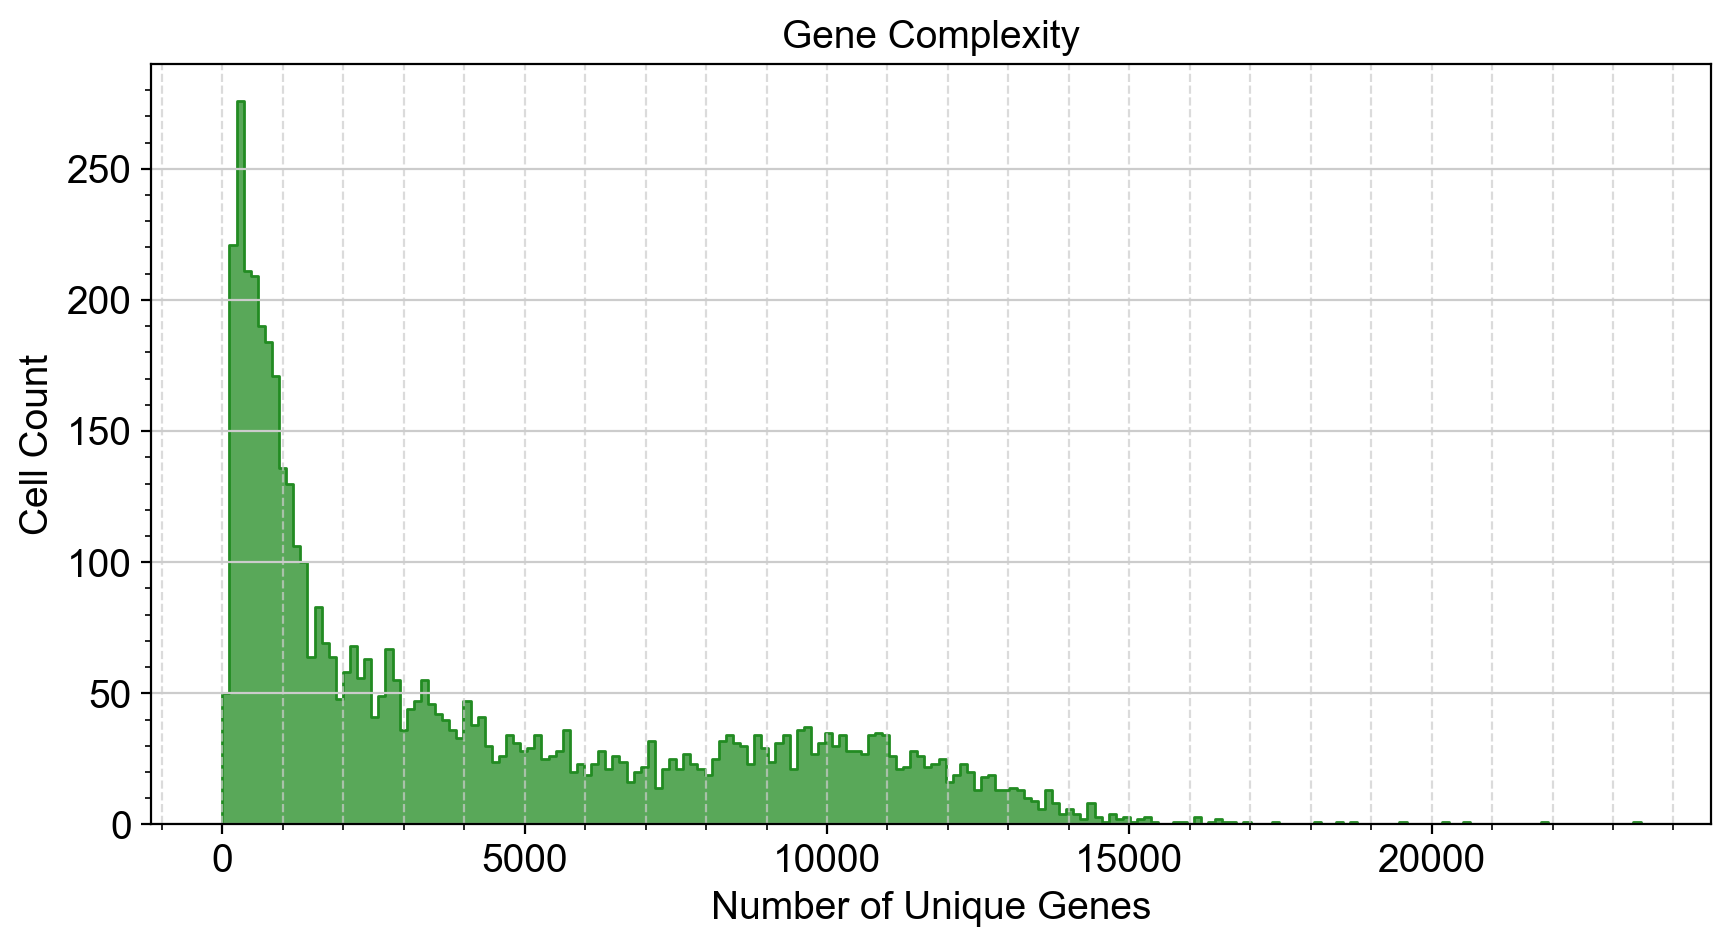

In [20]:
# Gene complexity distribution
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(adata.obs['n_genes_by_counts'], bins=200, color='forestgreen', element='step')

ax.set_title('Gene Complexity')
ax.set_xlabel('Number of Unique Genes')
ax.set_ylabel('Cell Count')
ax.grid(True, which='both', axis='x', linestyle='--', alpha=0.7)
ax.minorticks_on()

plt.show()

## COUNT HISTOGRAMS OVERVIEW

Histograms per experiment and plate to see low outliers to discard.

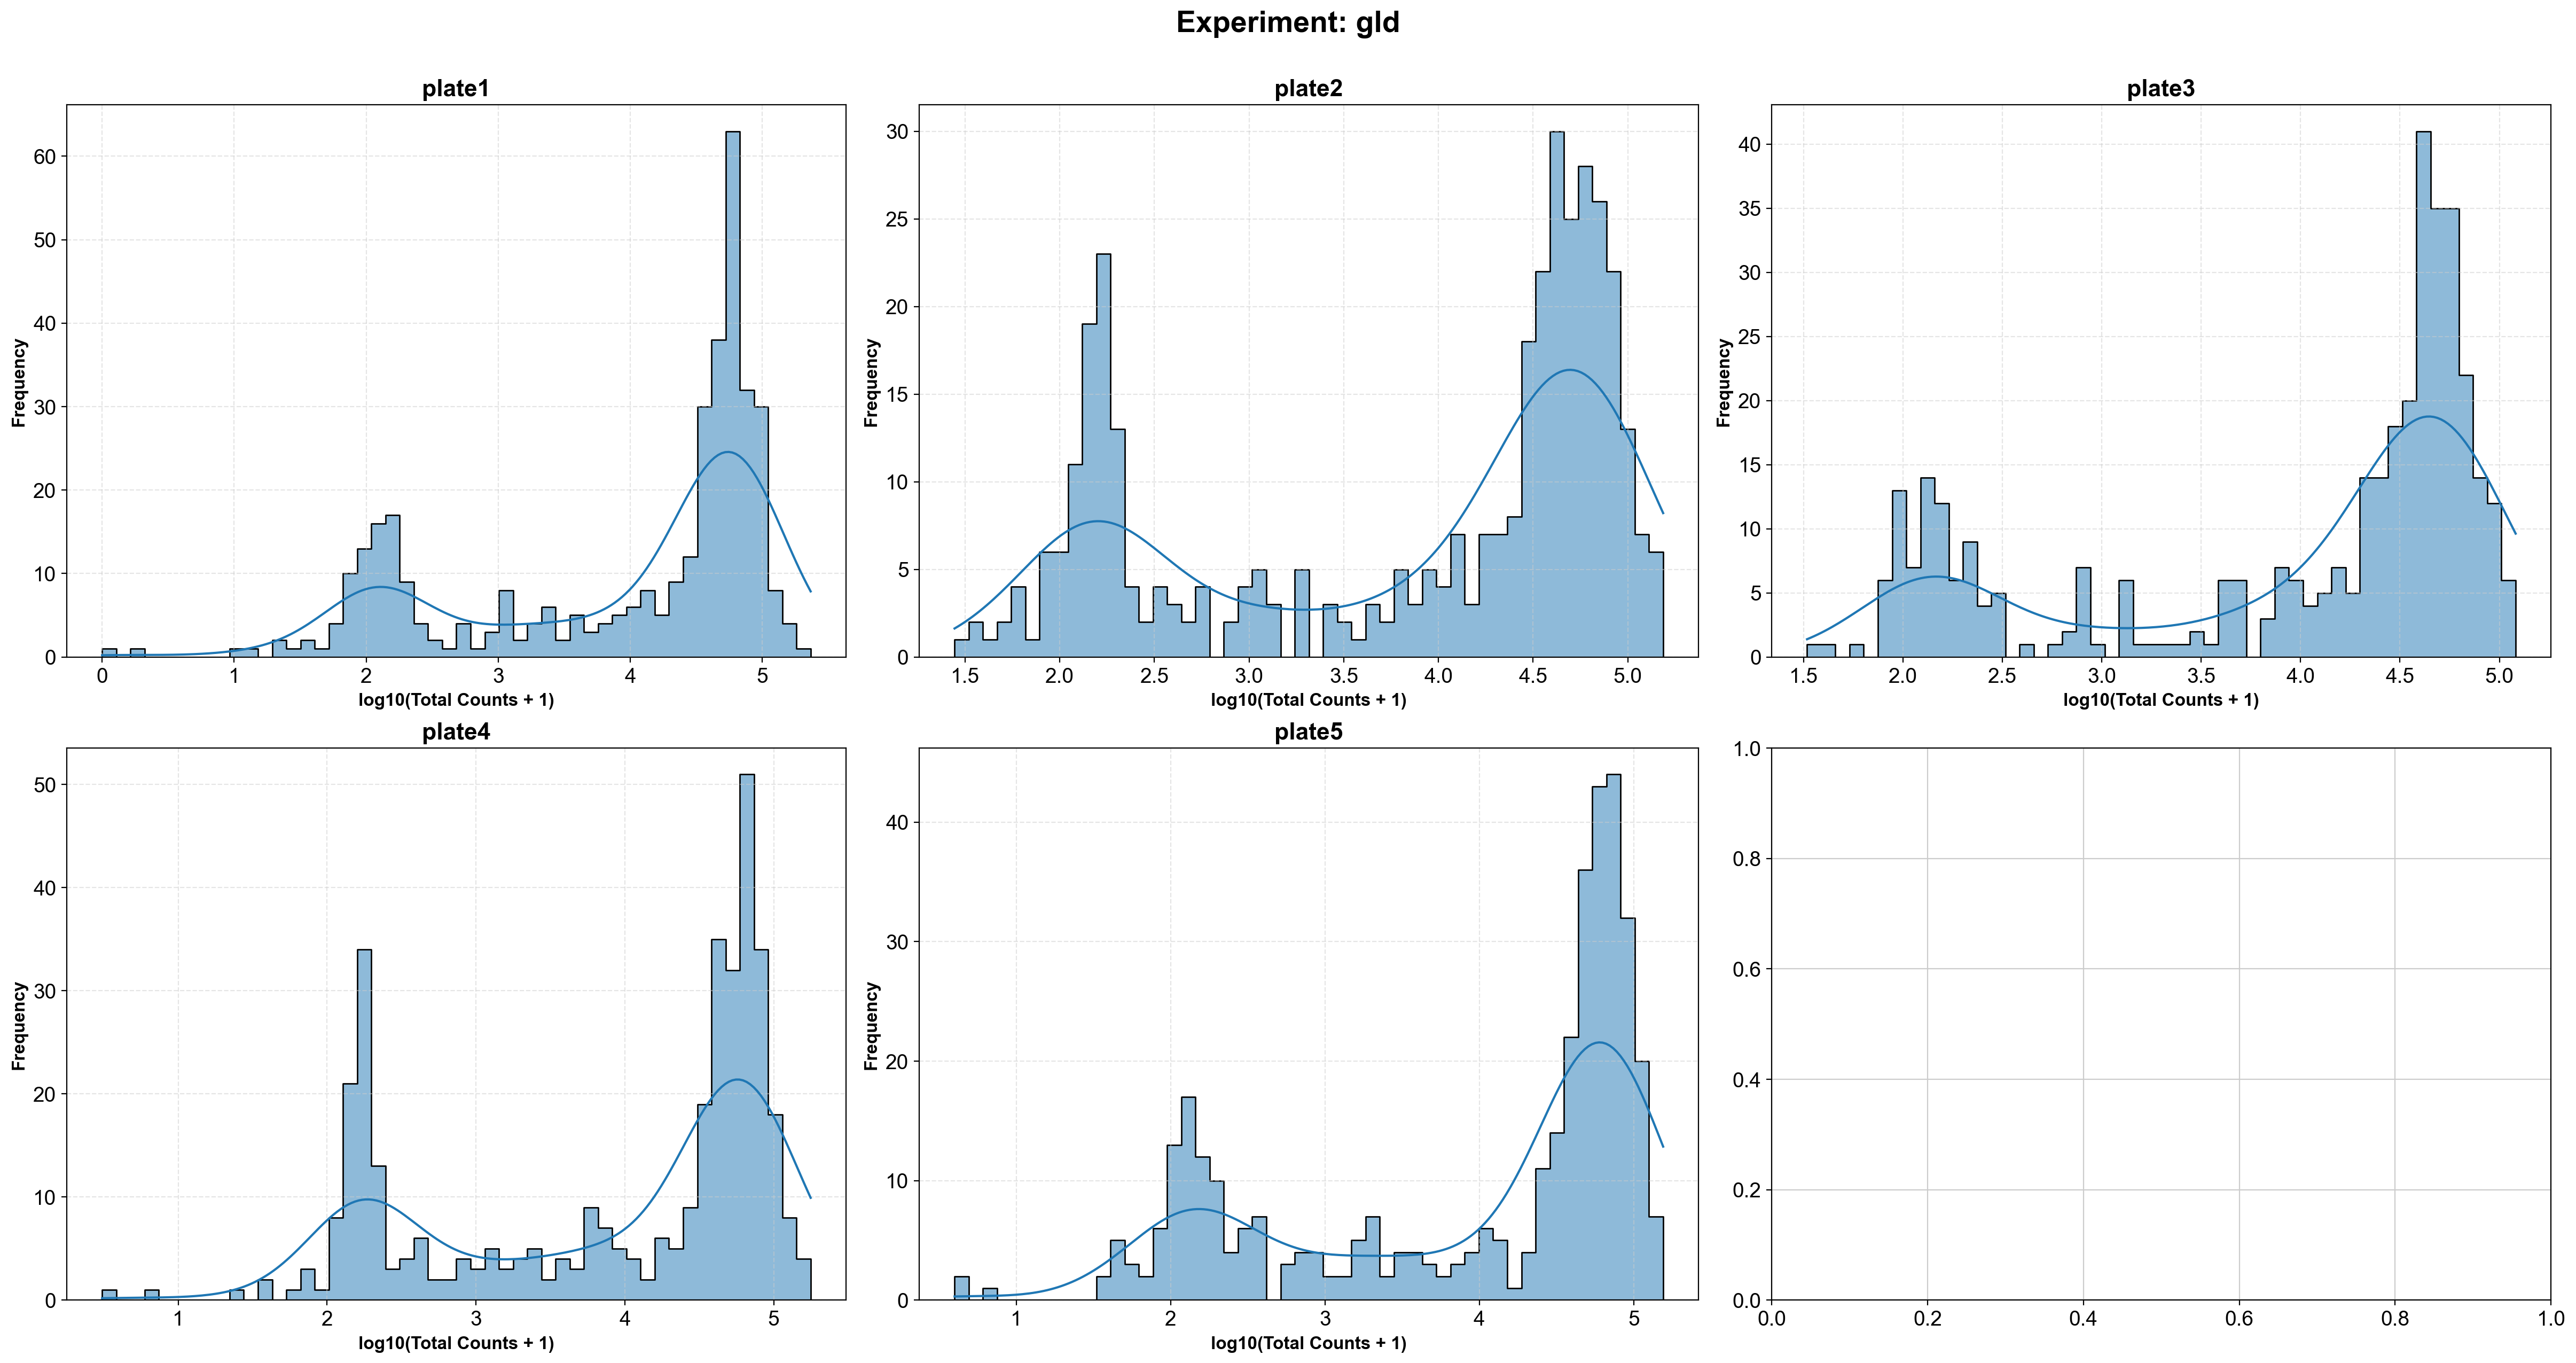

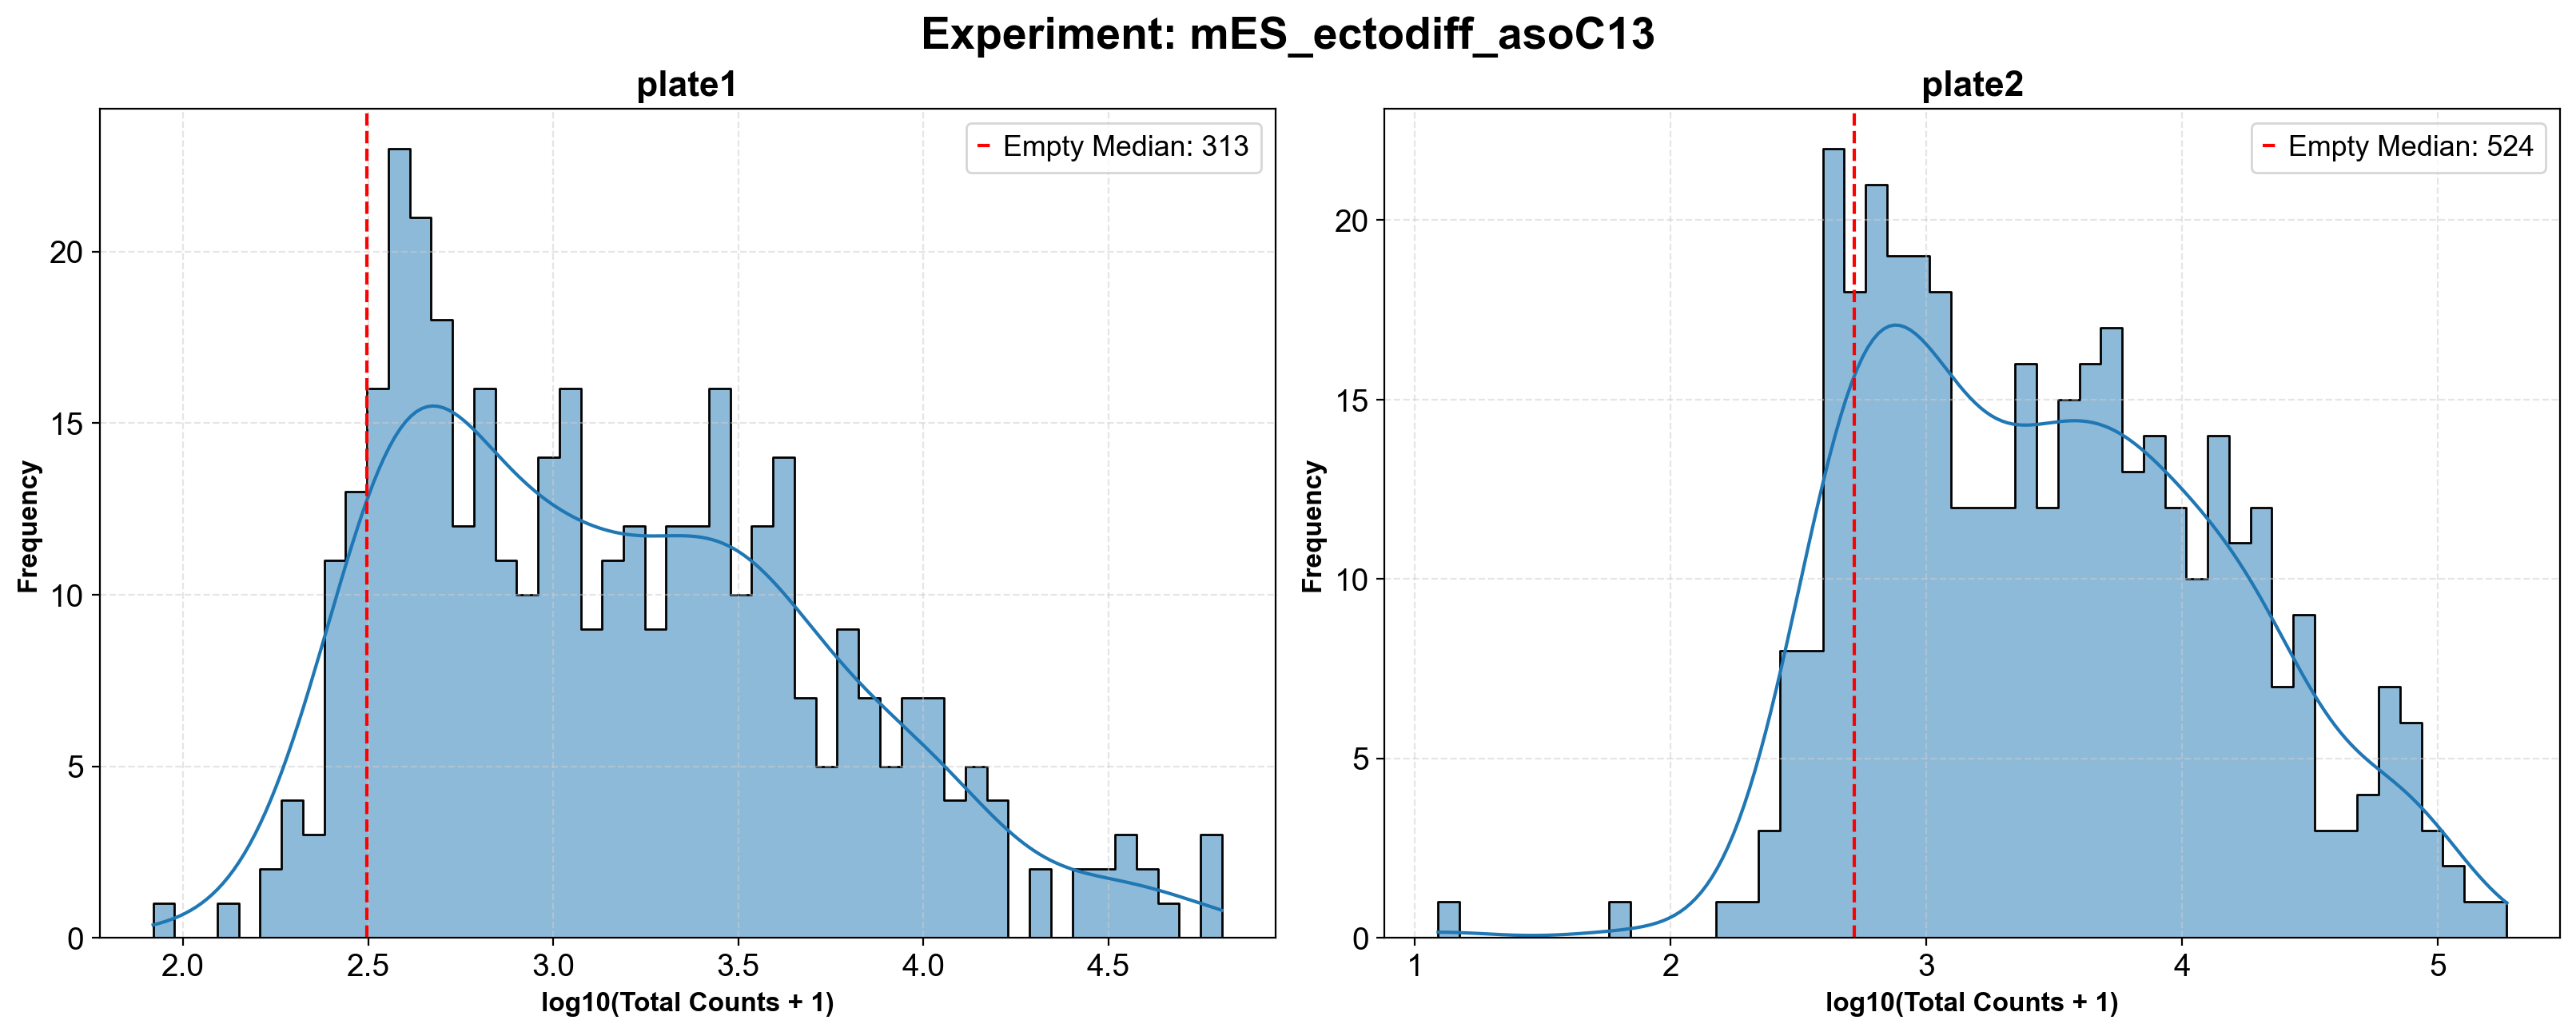

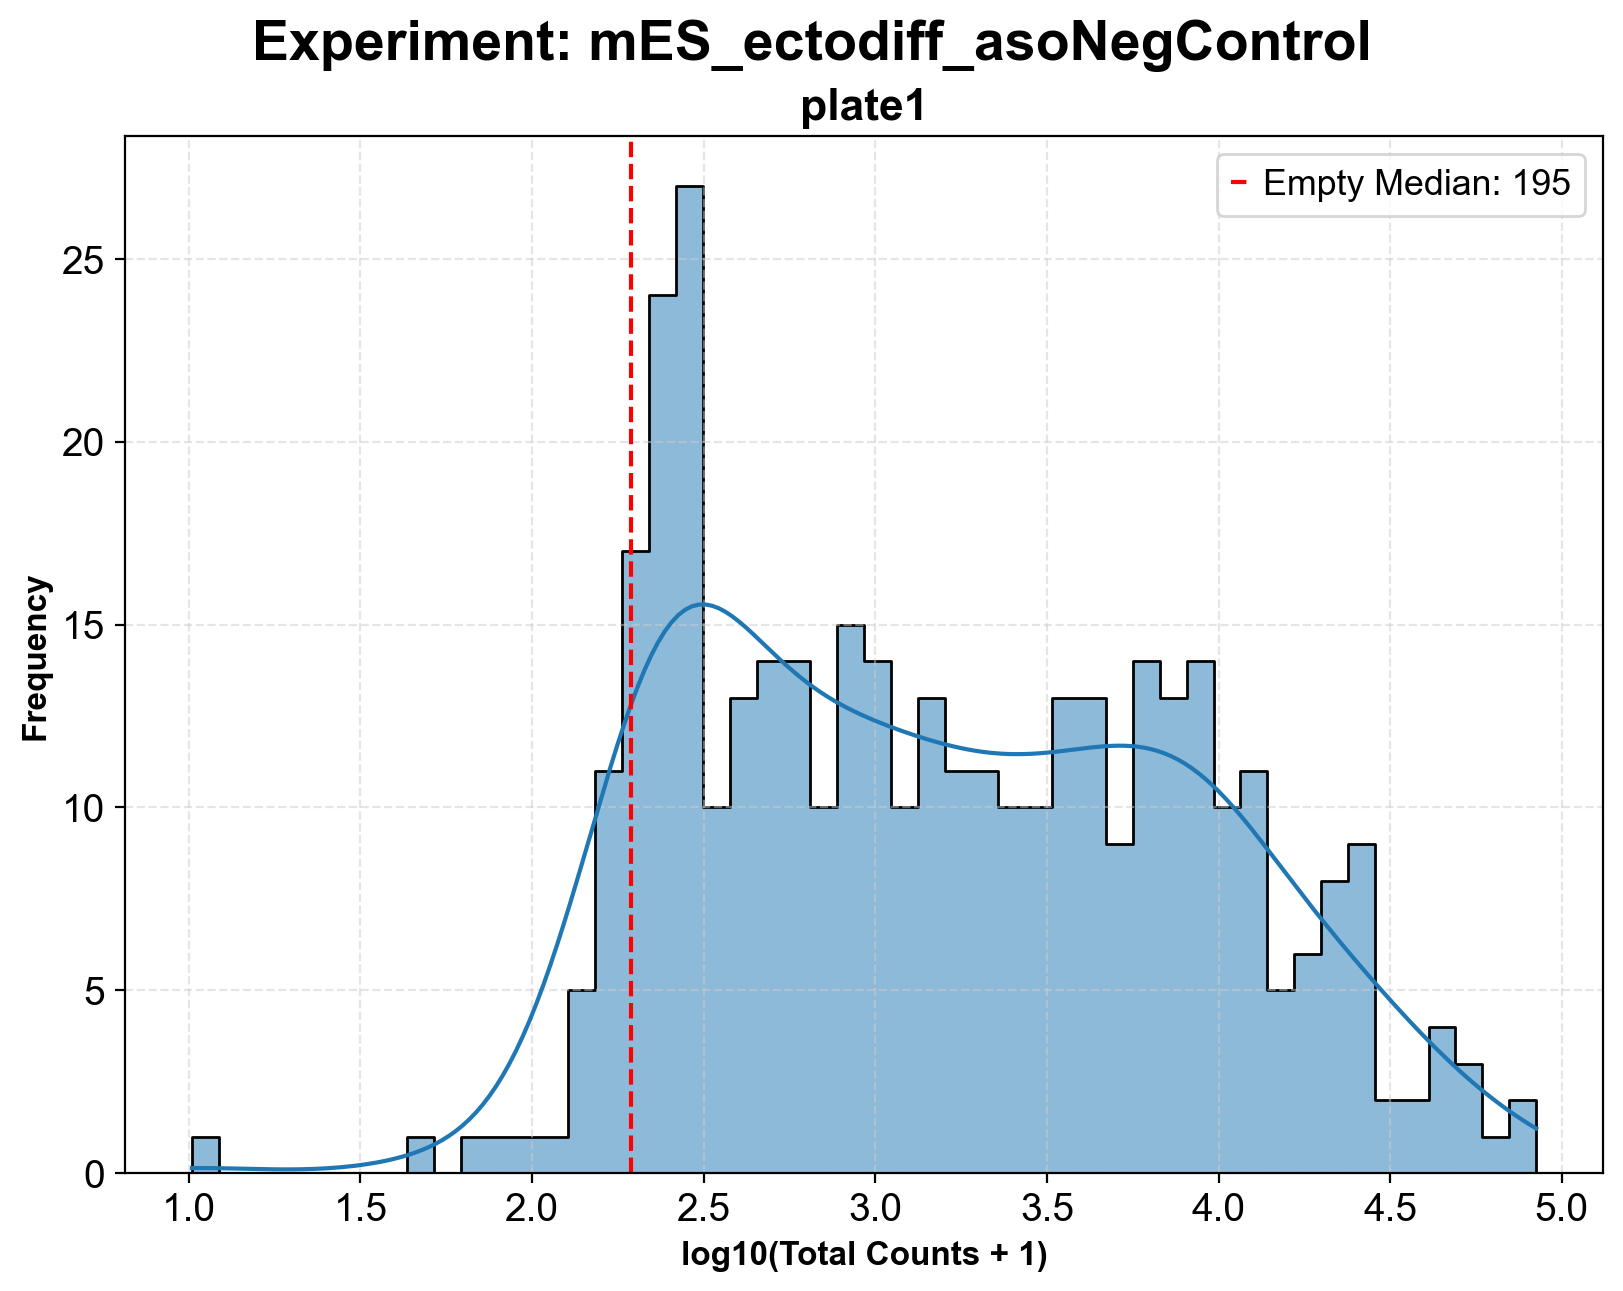

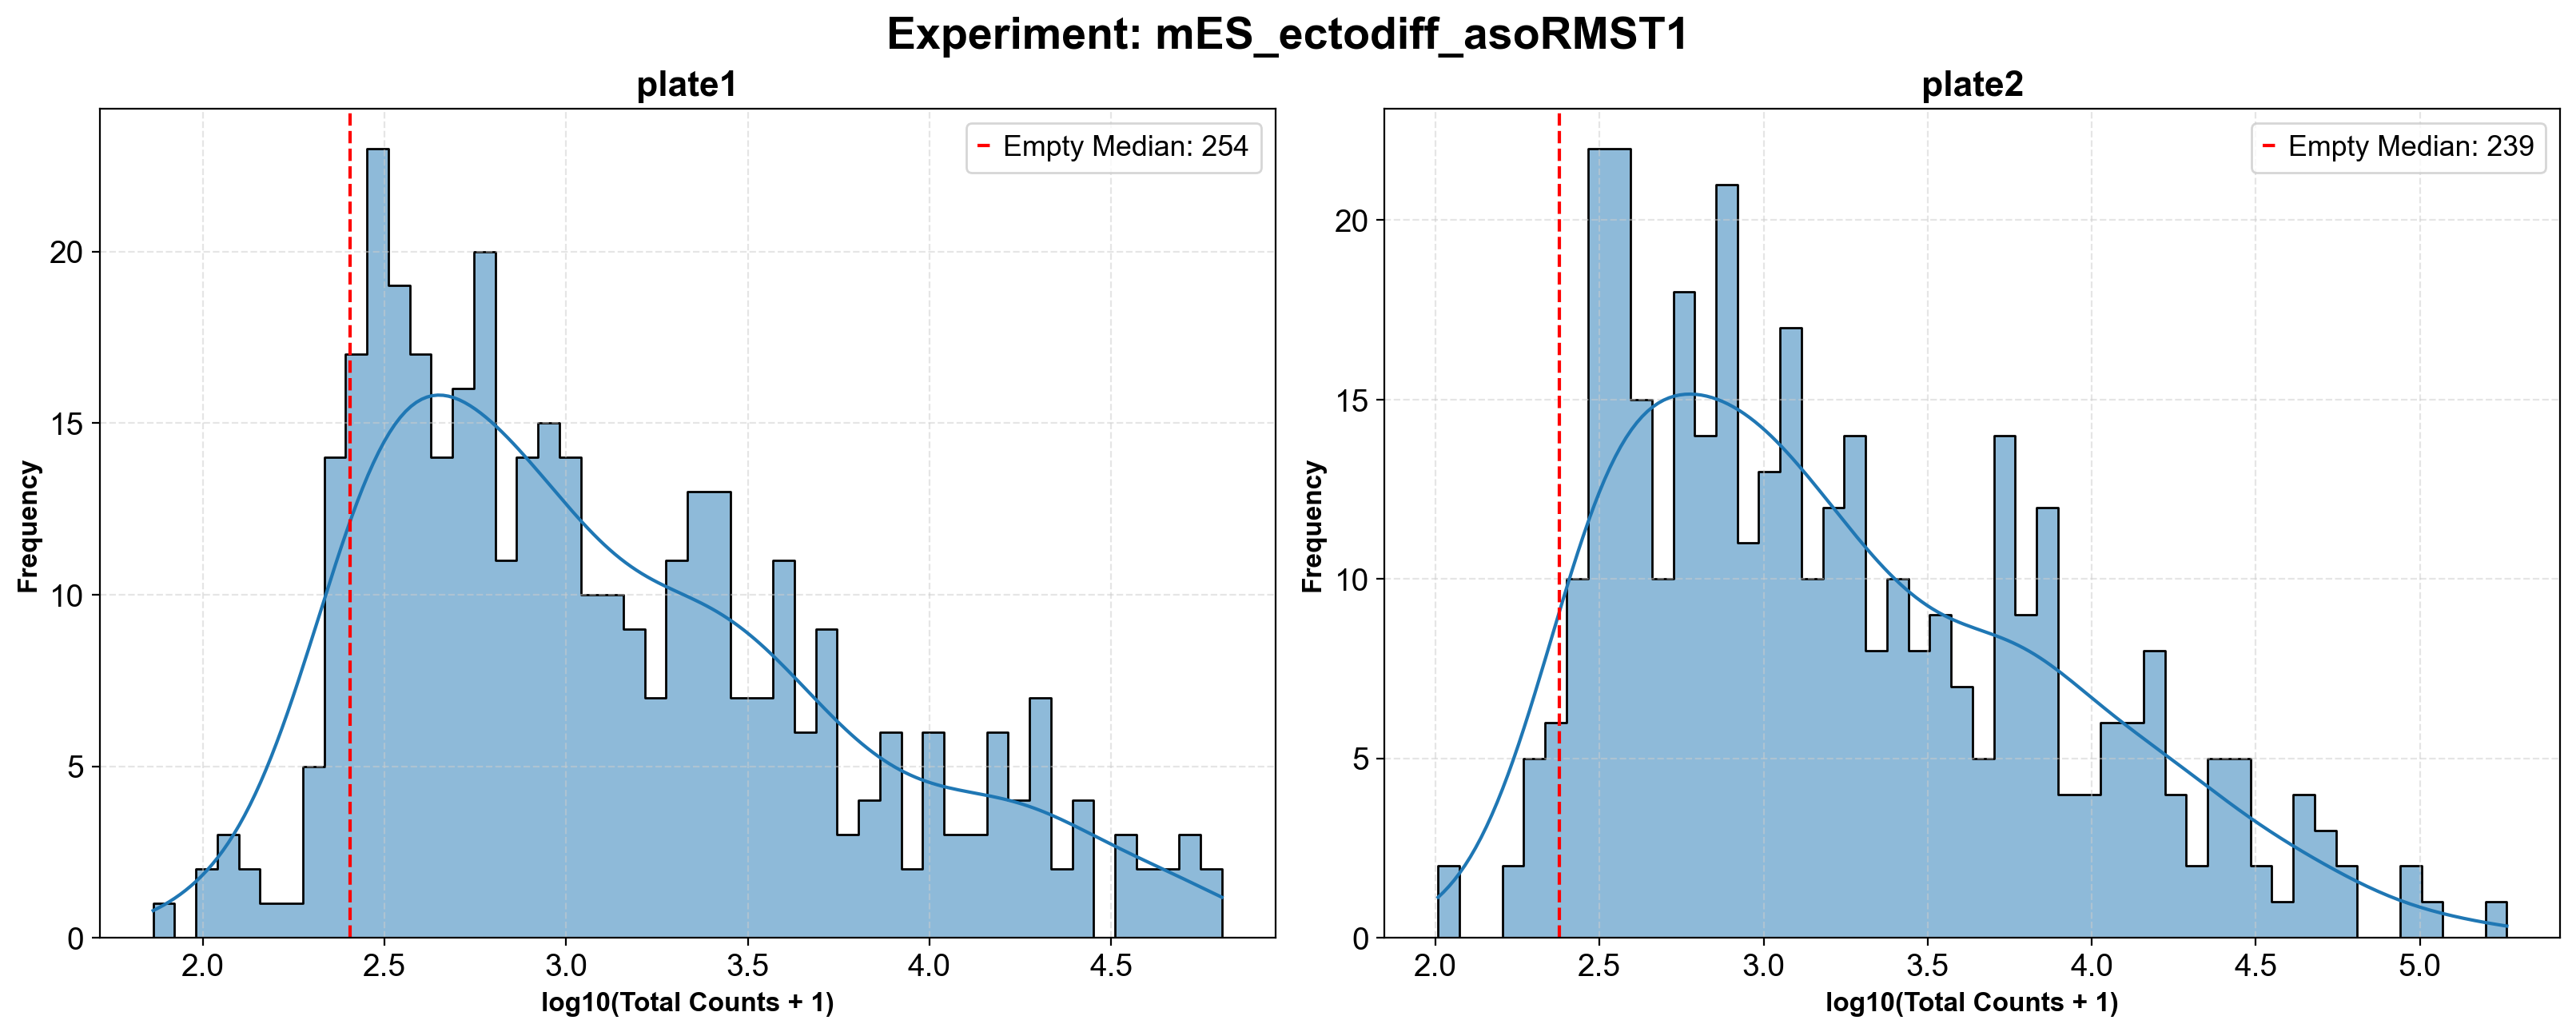

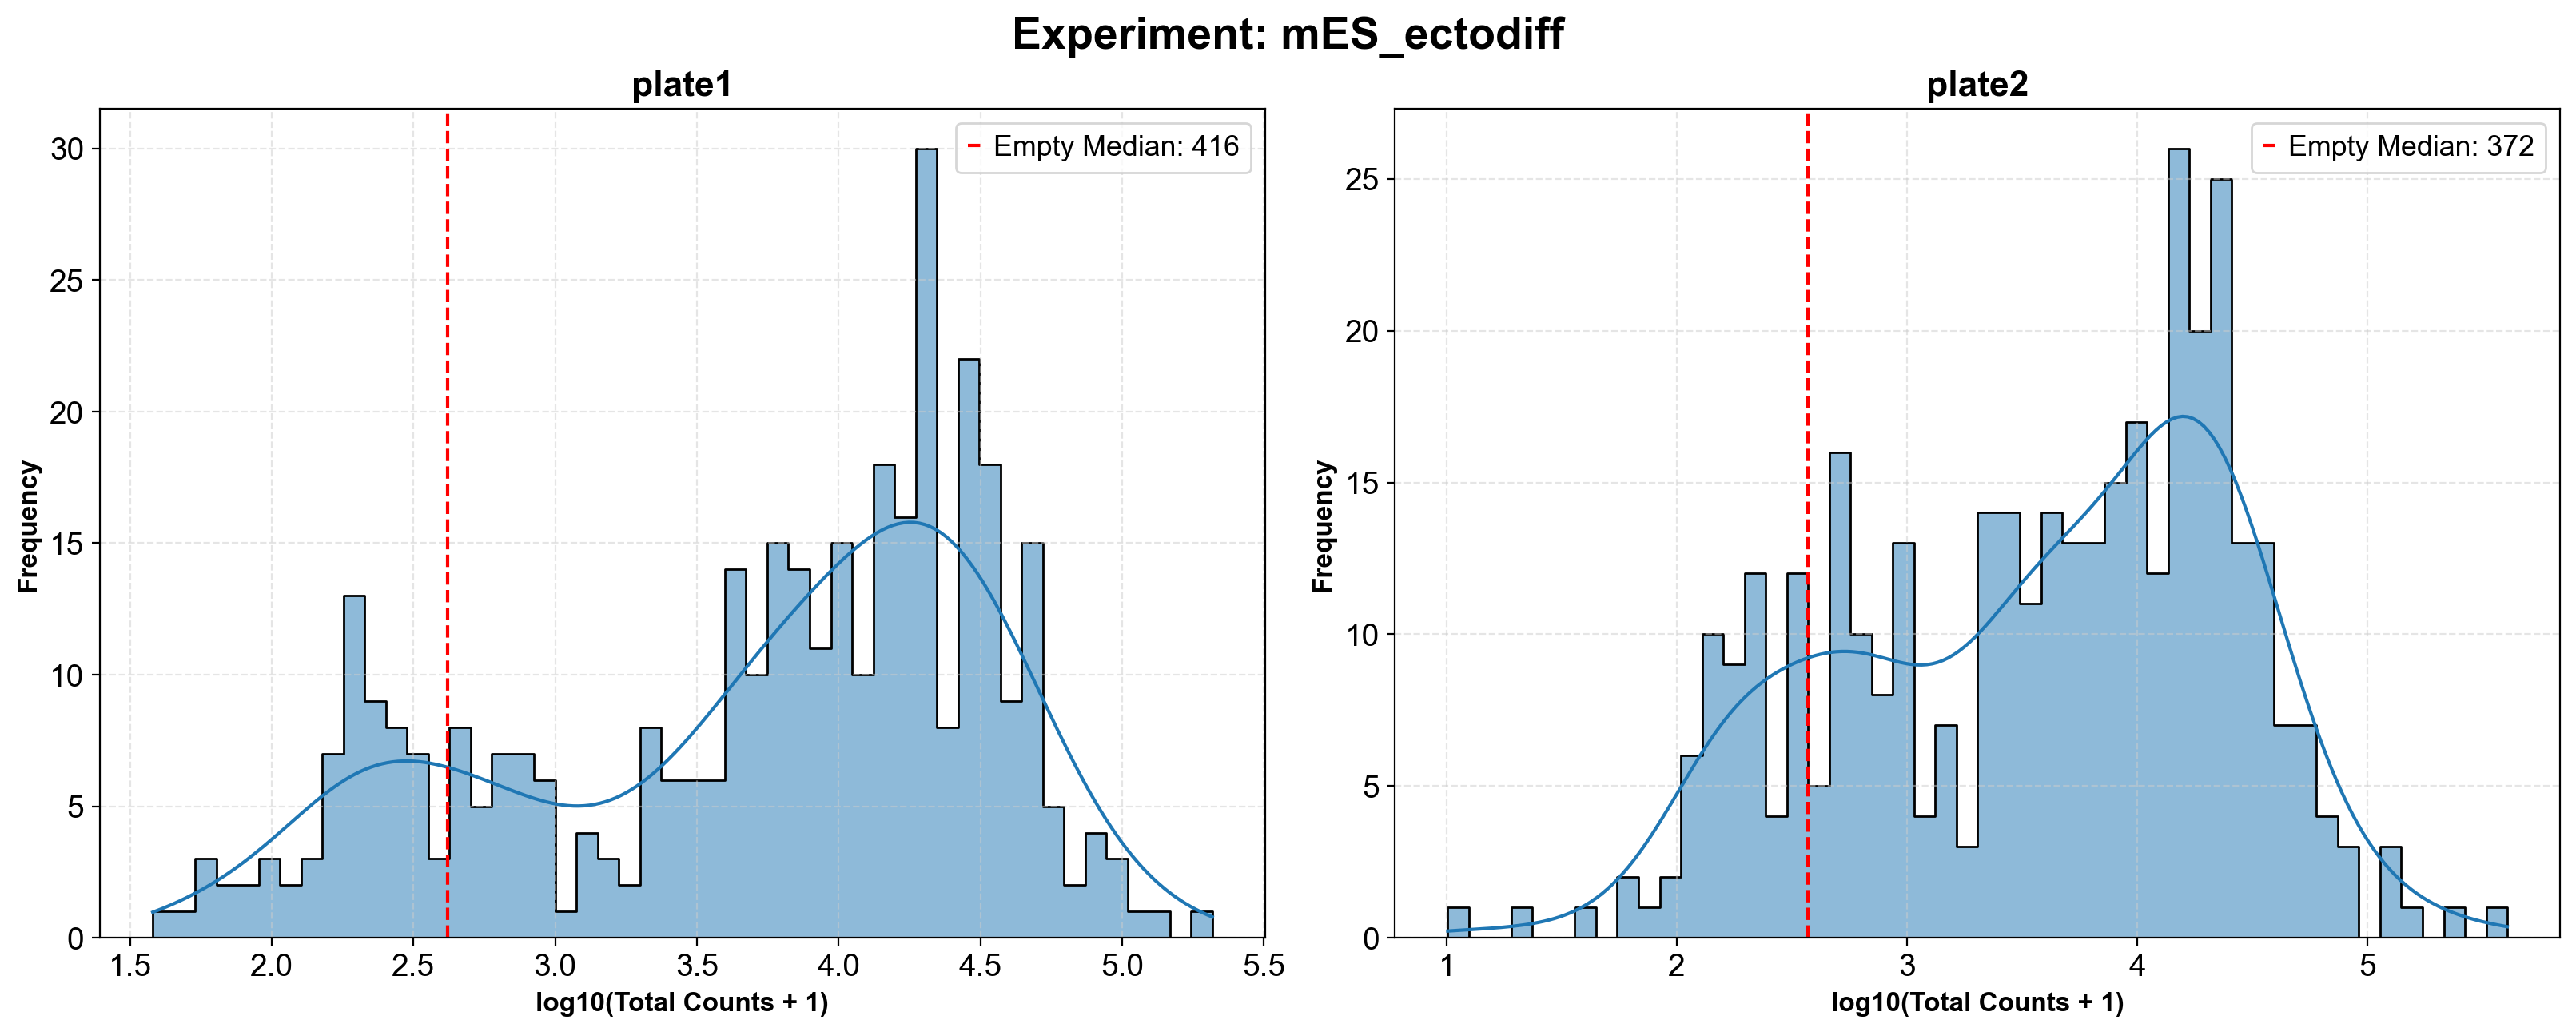

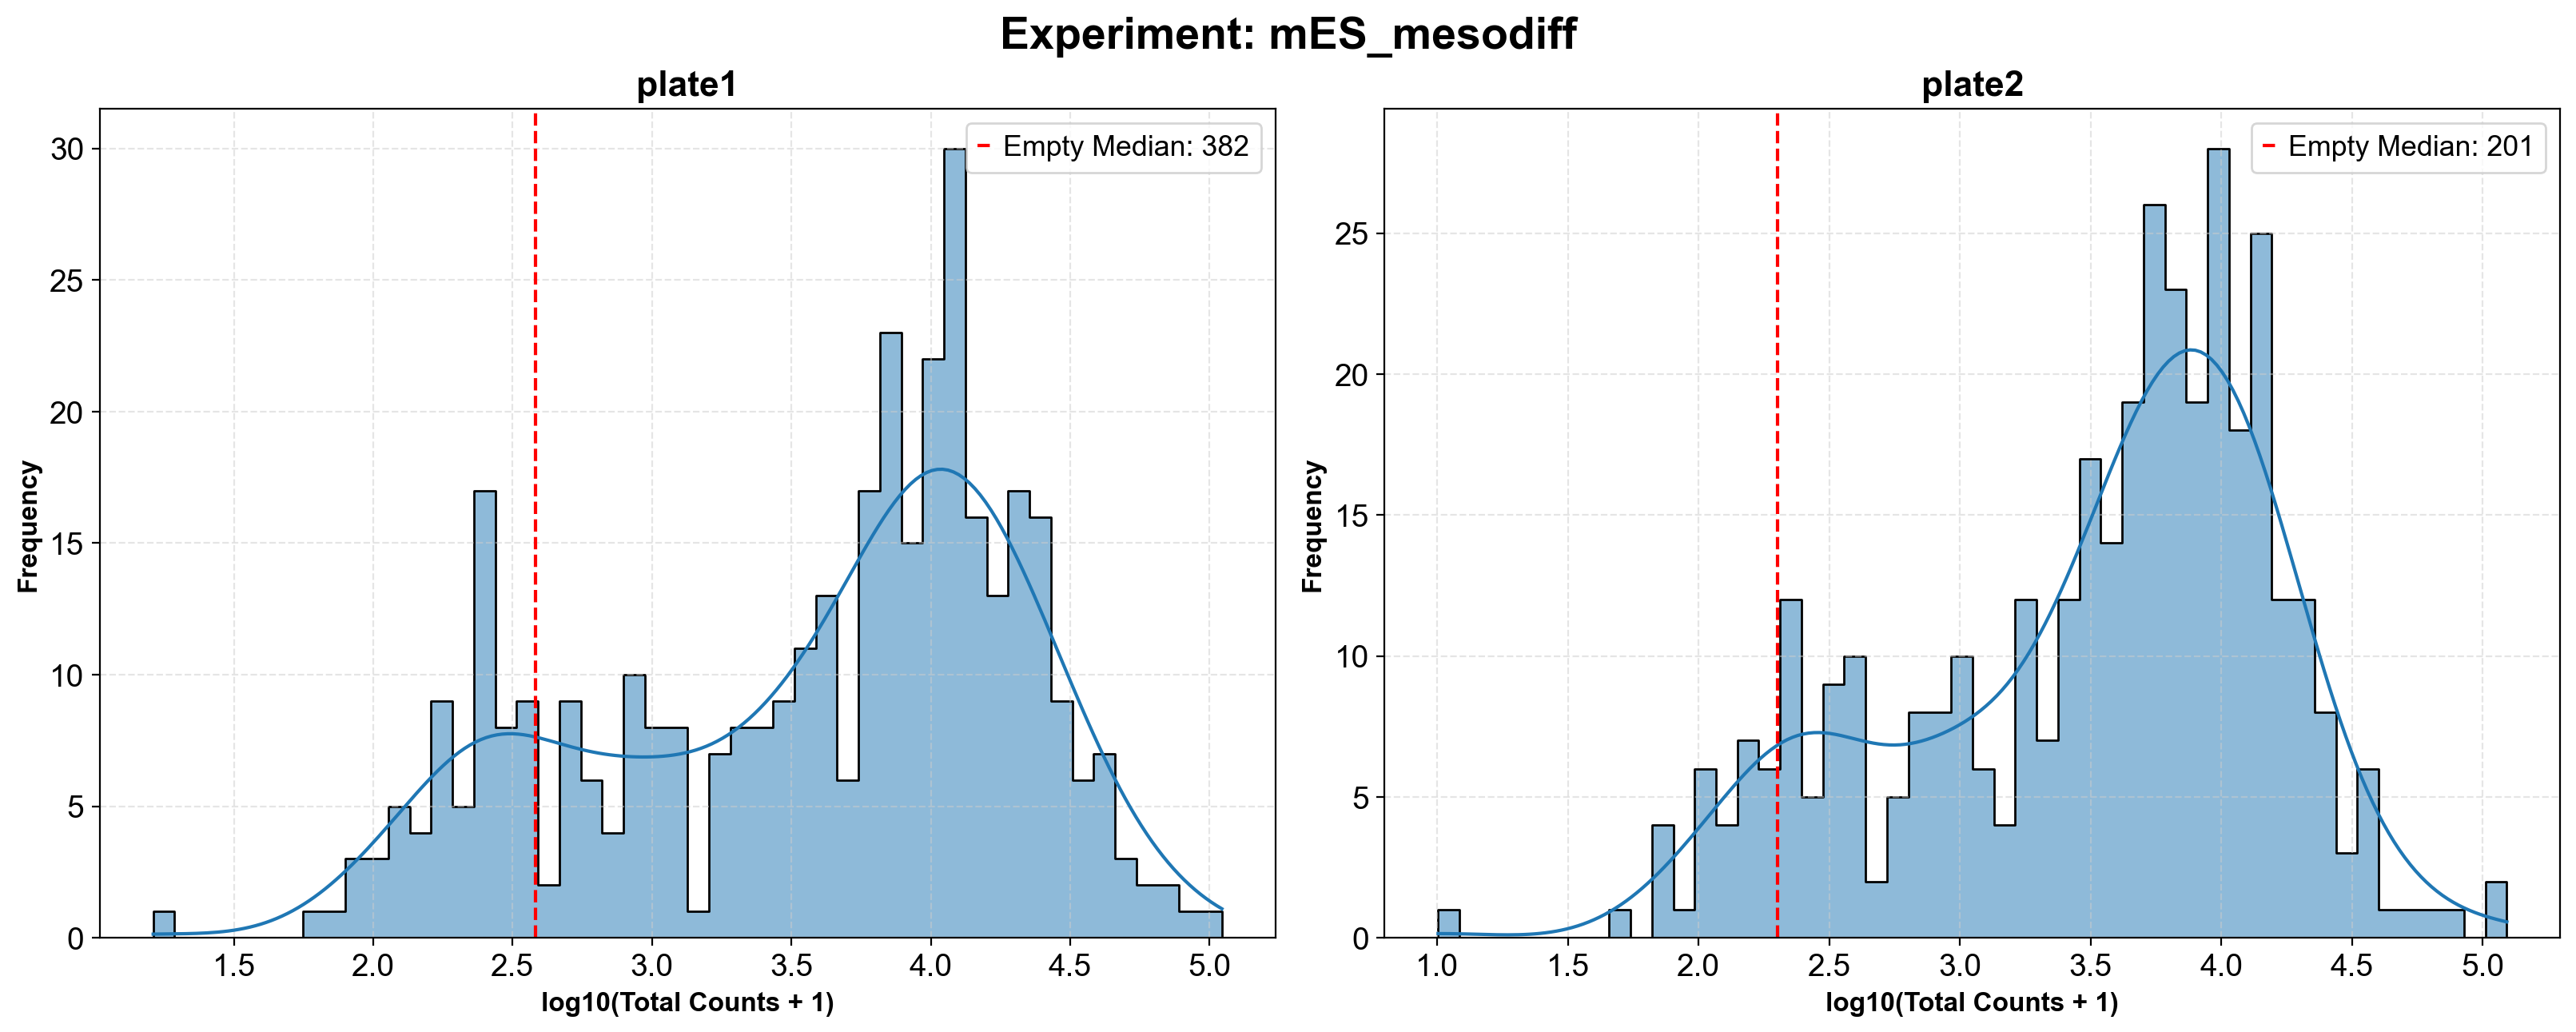

In [21]:
# --- PLOTTING LOG-HISTOGRAM ---
experiments = adata.obs['experiment'].unique()

for exp in experiments:
    # Filter data for current experiment
    subset = adata.obs[adata.obs['experiment'] == exp].copy()
    
    # Get plates and setup grid
    plates = sorted(subset['plate'].unique())
    n_plates = len(plates)
    n_cols = min(n_plates, 3)
    n_rows = math.ceil(n_plates / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 6 * n_rows), constrained_layout=True)
    
    # Main Title
    fig.suptitle(f"Experiment: {exp}", 
                 fontsize=20, fontweight='bold', y=1.05)
    
    # Handle single subplot case
    if n_plates > 1:
        axes = axes.flatten()
    else:
        axes = [axes]
    
    for i, plate in enumerate(plates):
        ax = axes[i]
        plate_data = subset[subset['plate'] == plate]
        
        # --- Log transformation ---
        data_to_plot = np.log10(plate_data['total_counts'] + 1)
        
        # Plot Histogram
        sns.histplot(
            data=plate_data,
            x=data_to_plot,
            multiple='stack',     # Stack them to see total distribution
            bins=50,              # Resolution
            ax=ax,
            kde=True,             # Add density line
            element='step'
        )
        
        # --- AESTHETICS ---
        ax.set_title(f"{plate}", fontsize=16, fontweight='bold')
        ax.set_xlabel("log10(Total Counts + 1)", fontsize=12, fontweight='bold')
        ax.set_ylabel("Frequency", fontsize=12, fontweight='bold')
        
        # Grid 
        ax.grid(True, which="both", ls="--", alpha=0.5)

        # Median of empty wells (vertical line for reference)
        if 'Empty' in plate_data['sample_type'].values:
            median_noise = np.log10(plate_data[plate_data['sample_type'] == 'Empty']['total_counts'].median() + 1)
            ax.axvline(median_noise, color='red', linestyle='--', label=f'Empty Median: {10**median_noise:.0f}')
            ax.legend()

    plt.show()

## FINDING THRESHOLD FROM HISTOGRAMS

Note: Normally less than 500 counts is not a good read.

1. Bimodal distributions: valley for cut-off
2. Unimodal distributions: use the mean of the rest of 'similar experiments' (i.e. no gastruloids one) to set the threshold

Detected 14 unique (Experiment, Plate) combinations.
Found Valley for gld-plate1: 1085
Found Valley for gld-plate2: 1972
Found Valley for gld-plate3: 1350
Found Valley for gld-plate4: 1549
Found Valley for gld-plate5: 2207
Found Valley for mES_ectodiff_asoC13-plate1: 1871
Found Valley for mES_ectodiff_asoC13-plate2: 2441
Found Valley for mES_ectodiff_asoNegControl-plate1: 2584
Found Valley for mES_ectodiff-plate1: 1193
Found Valley for mES_ectodiff-plate2: 1148
Found Valley for mES_mesodiff-plate1: 938
Found Valley for mES_mesodiff-plate2: 559


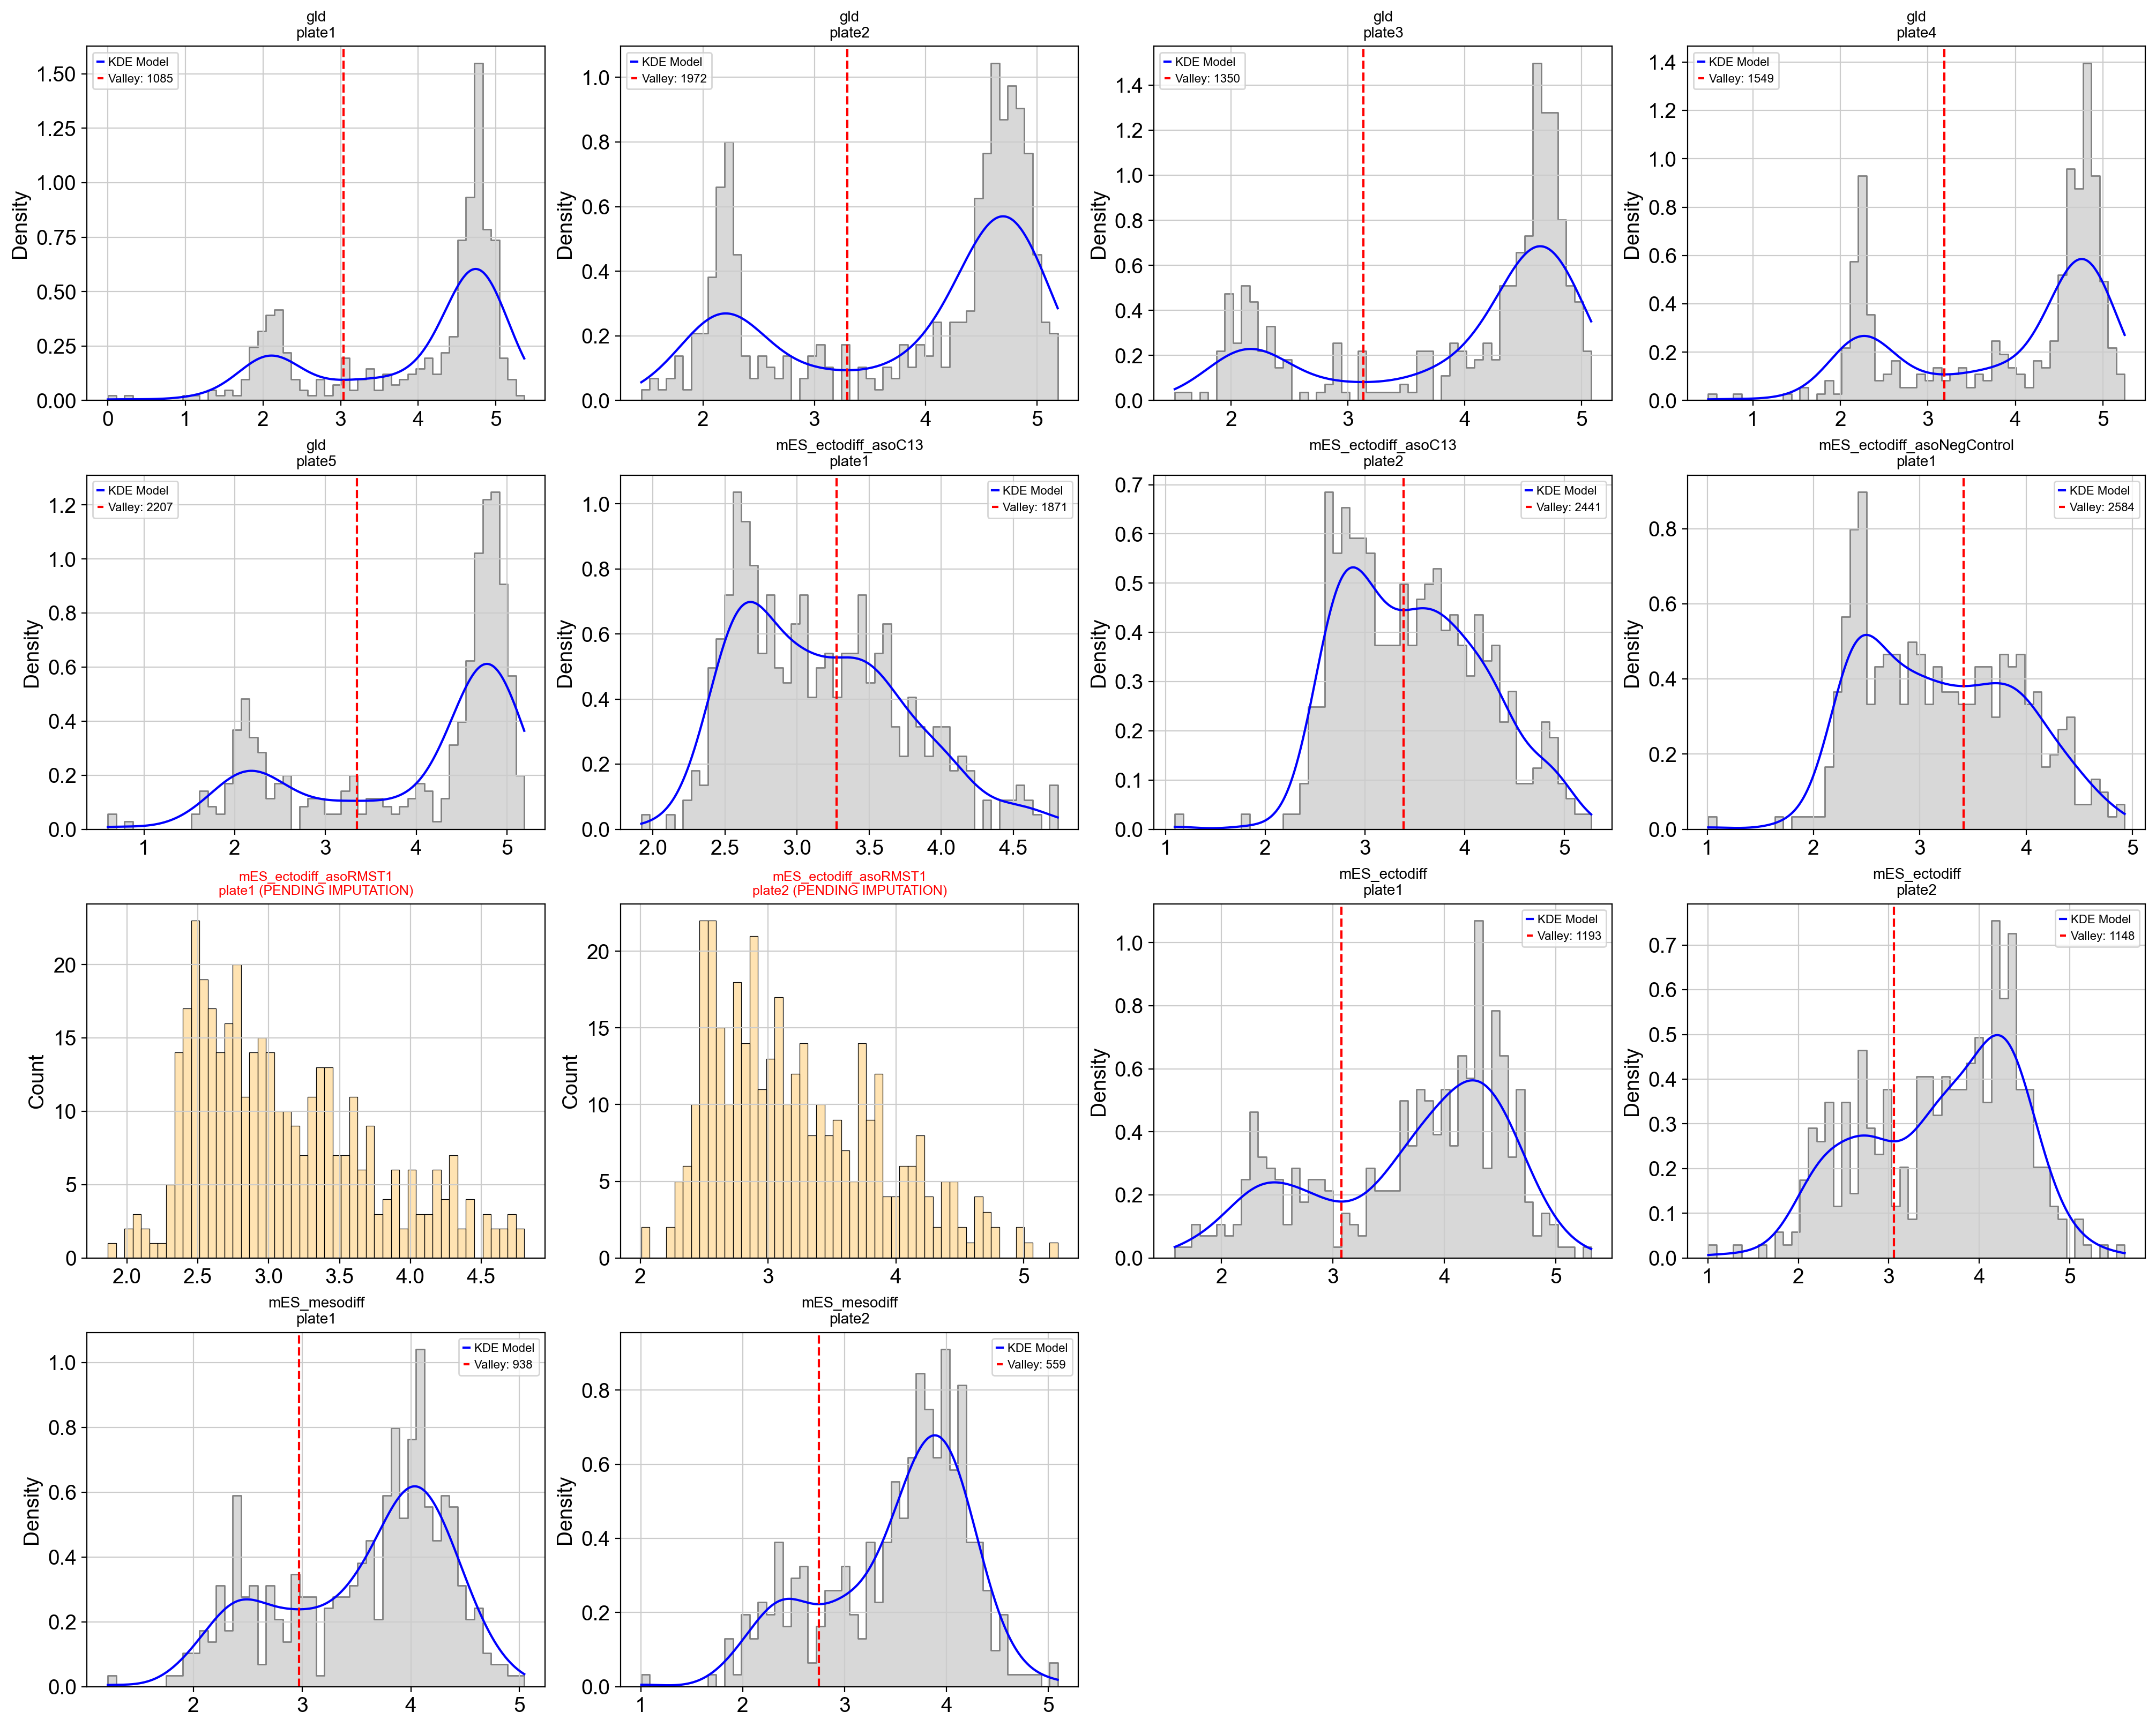

In [22]:
# --- CONFIGURATION ---
unimodal_experiment = 'mES_ectodiff_asoRMST1'
gld_experiment = 'gld'

thresholds_map = {}      
reference_values = []    

experiments = adata.obs['experiment'].unique()

# --- CORRECT GRID CALCULATION ---
# We need to count total (Experiment, Plate) combinations, not just unique plate names.
# Pandas drop_duplicates on the pair gives the true number of subplots needed.
total_plots = len(adata.obs[['experiment', 'plate']].drop_duplicates())

print(f"Detected {total_plots} unique (Experiment, Plate) combinations.")

# Setup Grid
n_cols = 4
n_rows = math.ceil(total_plots / n_cols)

# Create Figure
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows), constrained_layout=True)

# Flatten axes array for 1D iteration. 
# Robust check: if n_rows=1 and n_cols=1, axes is not an array, so we wrap it.
if total_plots > 1:
    axes = axes.flatten()
else:
    axes = [axes]

ax_idx = 0

## --- Calculate thresholds and plot for each plate ---
for exp in experiments:
    # Get plates for this experiment
    plates = sorted(adata.obs[adata.obs['experiment'] == exp]['plate'].unique())
    
    for plate in plates:
        # Get data
        subset = adata.obs[(adata.obs['experiment'] == exp) & (adata.obs['plate'] == plate)]
        counts = subset['total_counts'].values
        
        ax = axes[ax_idx]
        
        # --- LOGIC BRANCHING ---
        
        if exp == unimodal_experiment:
            # Case 1: Unimodal experiment. 
            # We DO NOT calculate valley here. We mark it as None for imputation later.
            thresholds_map[(exp, plate)] = None
            
            # Just plot histogram for reference
            sns.histplot(np.log10(counts+1), bins=50, color='orange', alpha=0.3, ax=ax)
            ax.set_title(f"{exp}\n{plate} (PENDING IMPUTATION)", fontsize=9, color='red')
            
        else:
            # Case 2: Bimodal (Standard or Gastruloid)
            # Try to find the valley analytically
            val = find_valley(counts, title=f"{exp}\n{plate}", ax=ax)
            
            if val is not None:
                thresholds_map[(exp, plate)] = val
                print(f"Found Valley for {exp}-{plate}: {val:.0f}")
                
                # CRITICAL: Only add to reference mean if it's NOT gastruloid
                if exp != gld_experiment:
                    reference_values.append(val)
            else:
                # If algorithm fails on a "good" plate, we will also impute
                thresholds_map[(exp, plate)] = None
                print(f"WARNING: No valley found for {exp}-{plate}. Will impute.")

        ax_idx += 1

# Hide unused axes
for i in range(ax_idx, len(axes)):
    axes[i].axis('off')

plt.show()

Add the mean threshold for unimodal-like distributions

In [23]:
# Calculate the robust mean from the bimodal distributions
if len(reference_values) > 0:
    mean_threshold = np.mean(reference_values)
    print(f"Calculated Mean Threshold: {mean_threshold:.0f} counts")
else:
    # if everything unimodal default value
    print("CRITICAL: No valid valleys found anywhere. Defaulting to 500.")
    mean_threshold = 500

# Assign the mean to the missing plates
for key, val in thresholds_map.items():
    if val is None:
        thresholds_map[key] = mean_threshold
        print(f"Imputing {mean_threshold:.0f} for {key[0]} - {key[1]}")

Calculated Mean Threshold: 1533 counts
Imputing 1533 for mES_ectodiff_asoRMST1 - plate1
Imputing 1533 for mES_ectodiff_asoRMST1 - plate2


## Genes per cell filtering?

=> Apparently a bimodal distribution

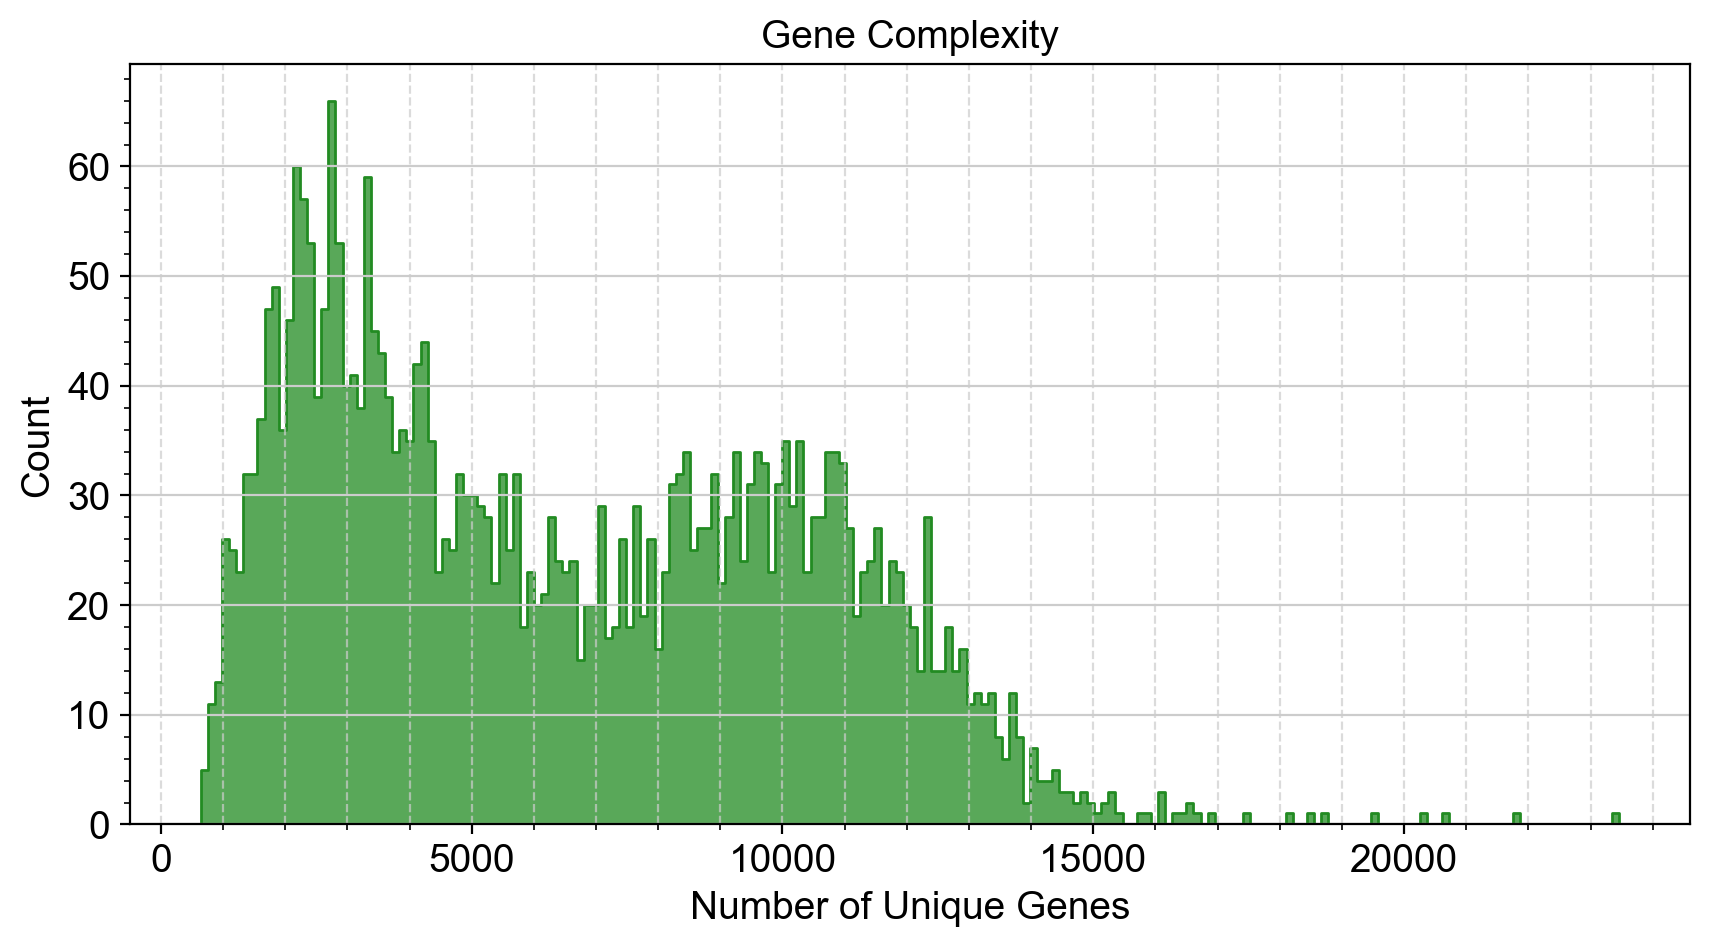

In [31]:
# Gene complexity distribution
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(adata.obs['n_genes_by_counts'], bins=200, color='forestgreen', element='step')

ax.set_title('Gene Complexity')
ax.set_xlabel('Number of Unique Genes')
ax.set_ylabel('Count')
ax.grid(True, which='both', axis='x', linestyle='--', alpha=0.7)
ax.minorticks_on()

plt.show()

BUT Batch effect from grastuloids. 

=> We work with the lncRNA subset so no filtering needed.

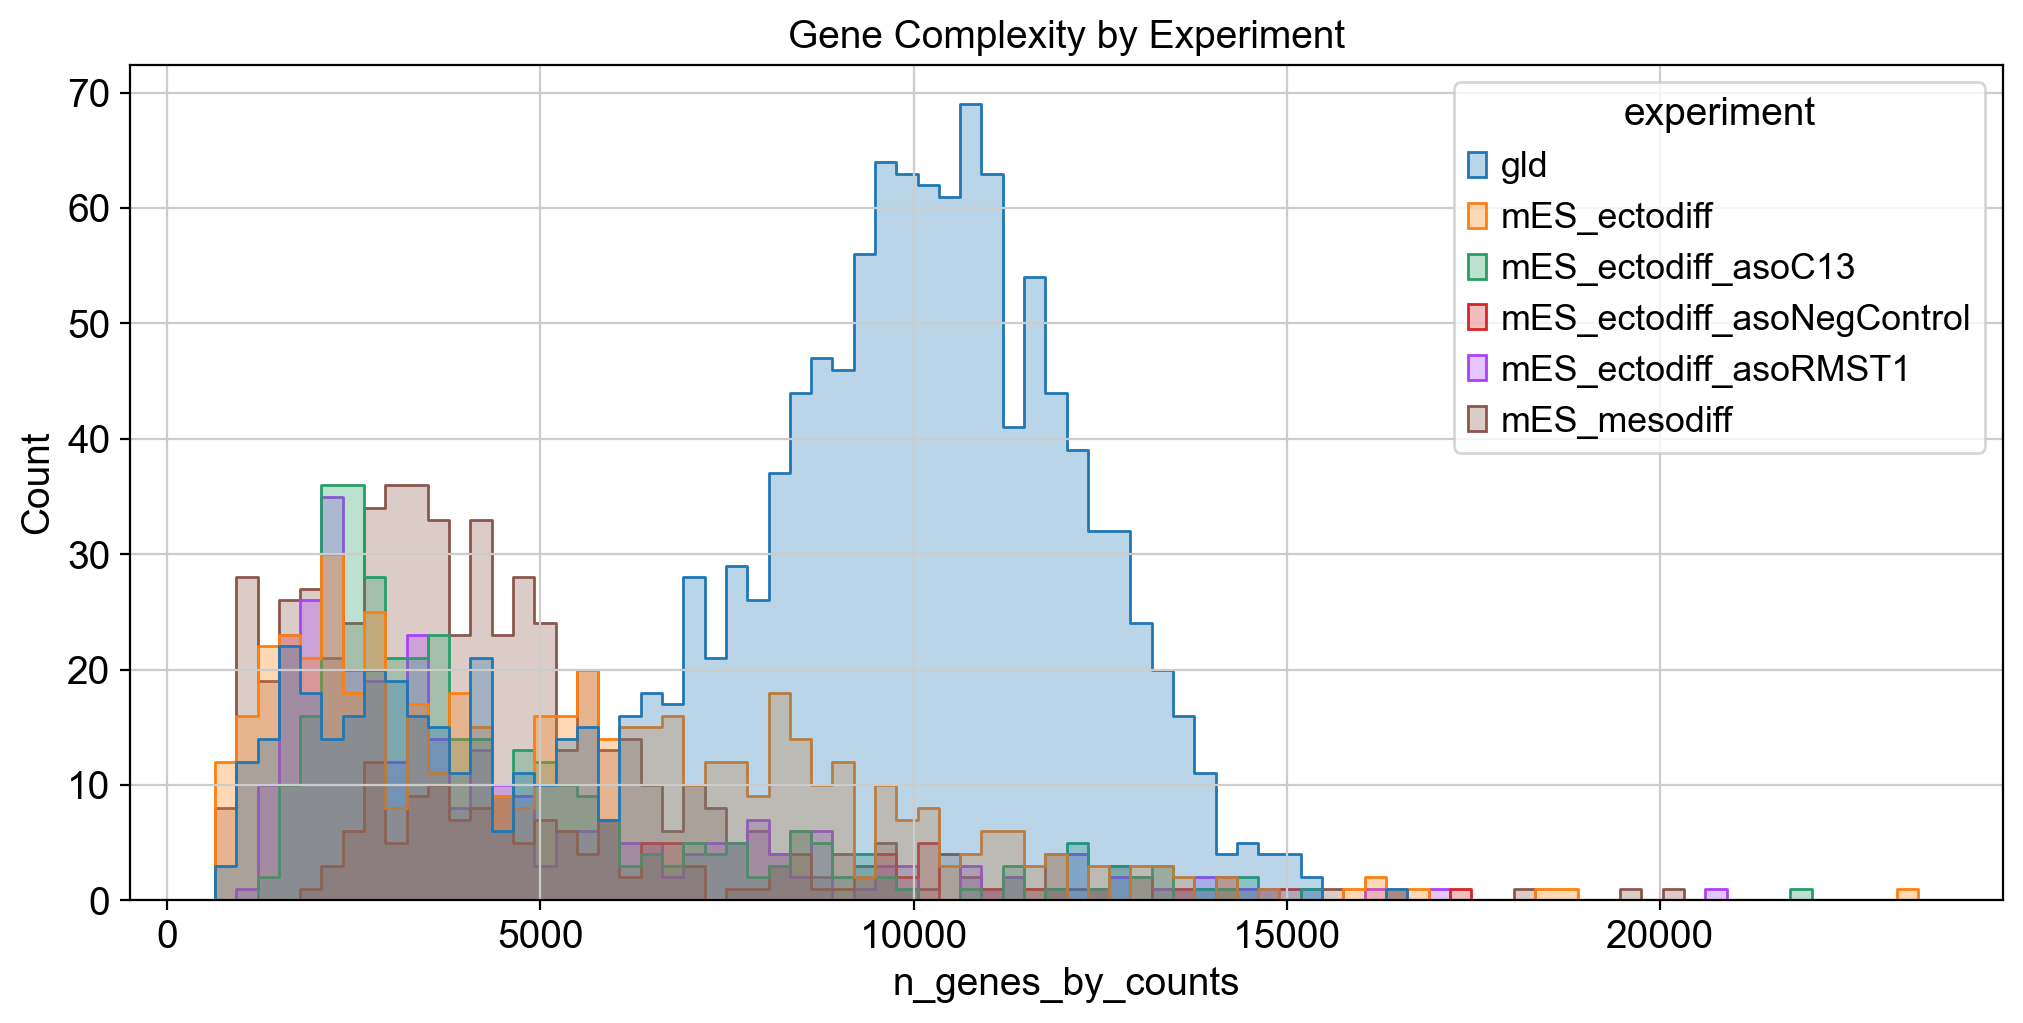

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5), constrained_layout=True)

# Batch Effect (By Experiment)
sns.histplot(
    data=adata.obs, 
    x='n_genes_by_counts', 
    hue='experiment', 
    element='step', 
    bins=80, 
    alpha=0.3
)
ax.set_title('Gene Complexity by Experiment')

plt.show()

## Filtering data under the calculated thresholds

In [26]:
# --- APPLY FILTER ---

# Create a False mask
keep_mask = np.zeros(adata.n_obs, dtype=bool)

for exp in experiments:
    plates = adata.obs[adata.obs['experiment'] == exp]['plate'].unique()
    for plate in plates:
        # Get specific threshold
        thr = thresholds_map[(exp, plate)]
        
        # Build mask for this plate
        plate_mask = (adata.obs['experiment'] == exp) & \
                     (adata.obs['plate'] == plate) & \
                     (adata.obs['total_counts'] > thr)
        
        # Combine with global mask
        keep_mask = keep_mask | plate_mask

# Execute filtering
n_before = adata.n_obs
adata = adata[keep_mask, :].copy()
n_after = adata.n_obs

print(f"Filtering:")
print(f"Before: {n_before} -> After: {n_after} cells")
print(f"Removed {n_before - n_after} cells ({((n_before-n_after)/n_before)*100:.1f}%)")

Filtering:
Before: 5318 -> After: 3311 cells
Removed 2007 cells (37.7%)


## Filter cells with overexpression of mitochondrial counts

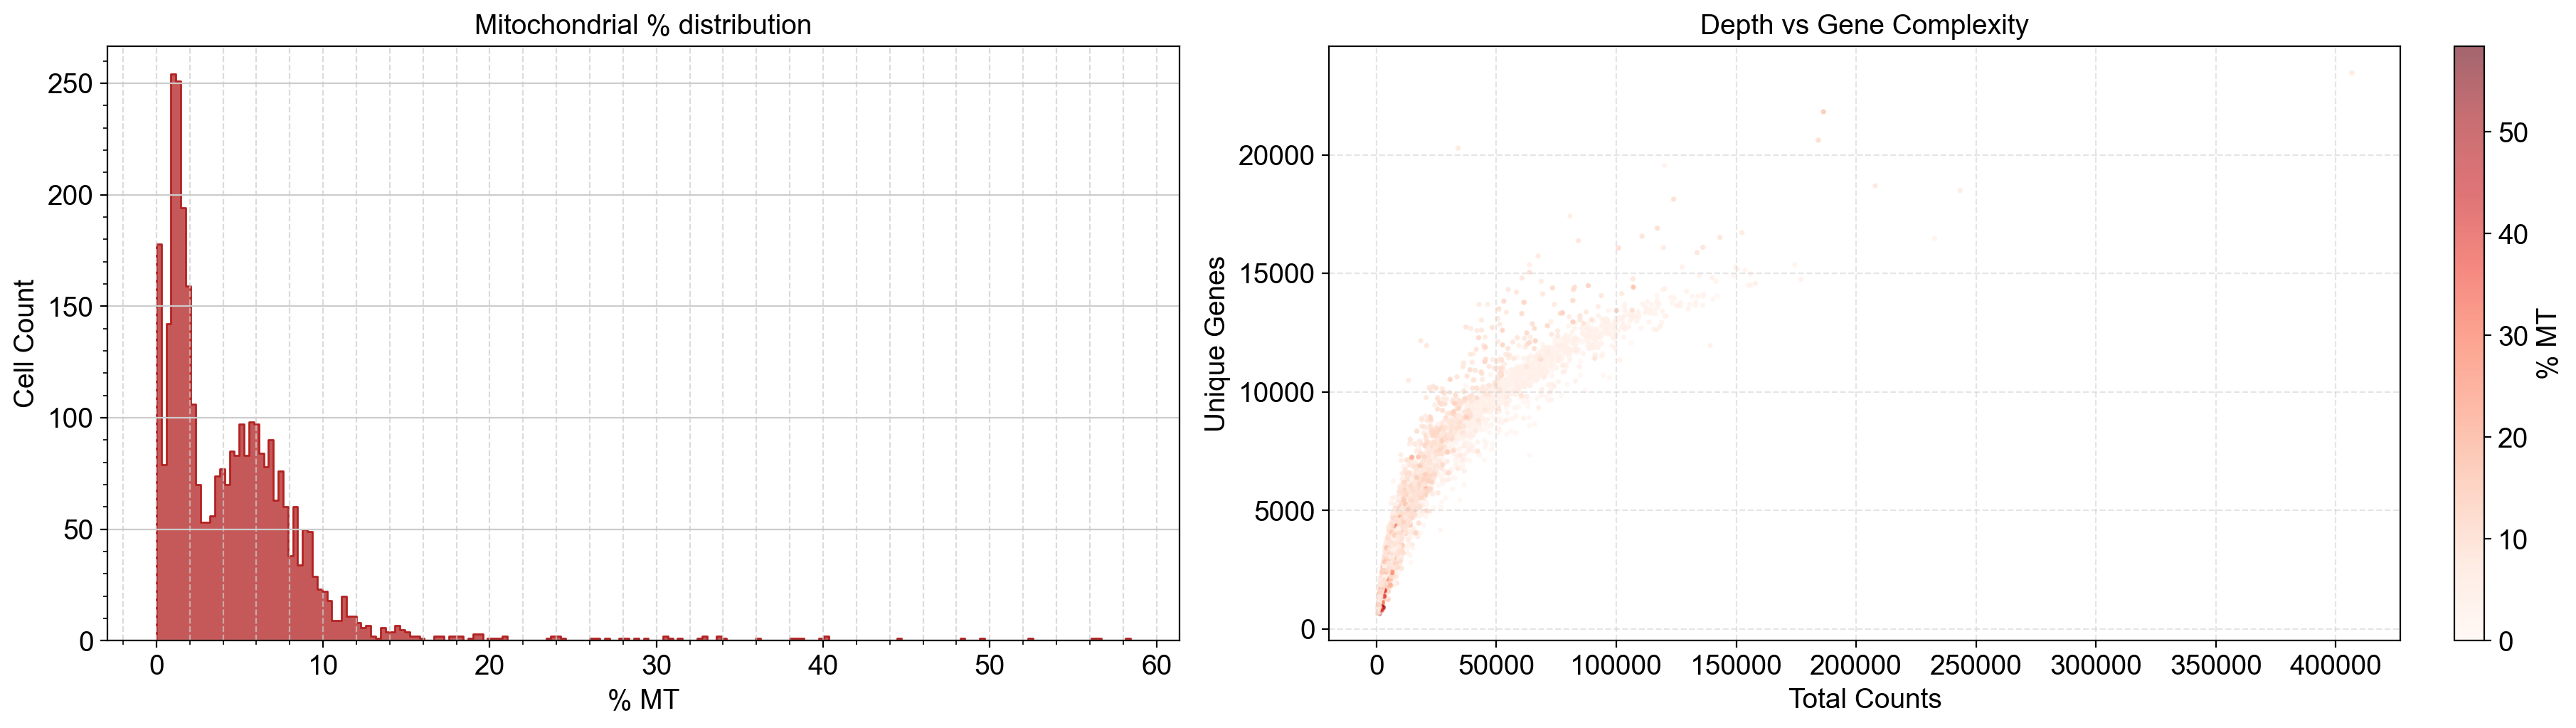

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), constrained_layout=True)

# 1. Mitochondrial % Distribution
sns.histplot(adata.obs['pct_counts_mt'], bins=200, ax=axes[0], color='firebrick', element='step')
axes[0].set_title('Mitochondrial % distribution')
axes[0].set_xlabel('% MT')
axes[0].set_ylabel('Cell Count')
# Add dense grid
axes[0].grid(True, which='both', axis='x', linestyle='--', alpha=0.7)
# Minor ticks
axes[0].minorticks_on()

# Depth vs Complexity
# We use a scatter plot colored by MT% 
scatter = axes[1].scatter(
    adata.obs['total_counts'], 
    adata.obs['n_genes_by_counts'], 
    c=adata.obs['pct_counts_mt'], 
    cmap='Reds', 
    s=3, 
    alpha=0.6
)
axes[1].set_title('Depth vs Gene Complexity')
axes[1].set_xlabel('Total Counts')
axes[1].set_ylabel('Unique Genes')
axes[1].grid(True, linestyle='--', alpha=0.5)

# Add colorbar for MT%
cbar = fig.colorbar(scatter, ax=axes[1])
cbar.set_label('% MT')

plt.show()

Separated by experiment to check batch effects:

/var/folders/x7/st5qbw1x4w3gr8j8_kcwrvgc0000gn/T/ipykernel_80368/2240050709.py:35: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


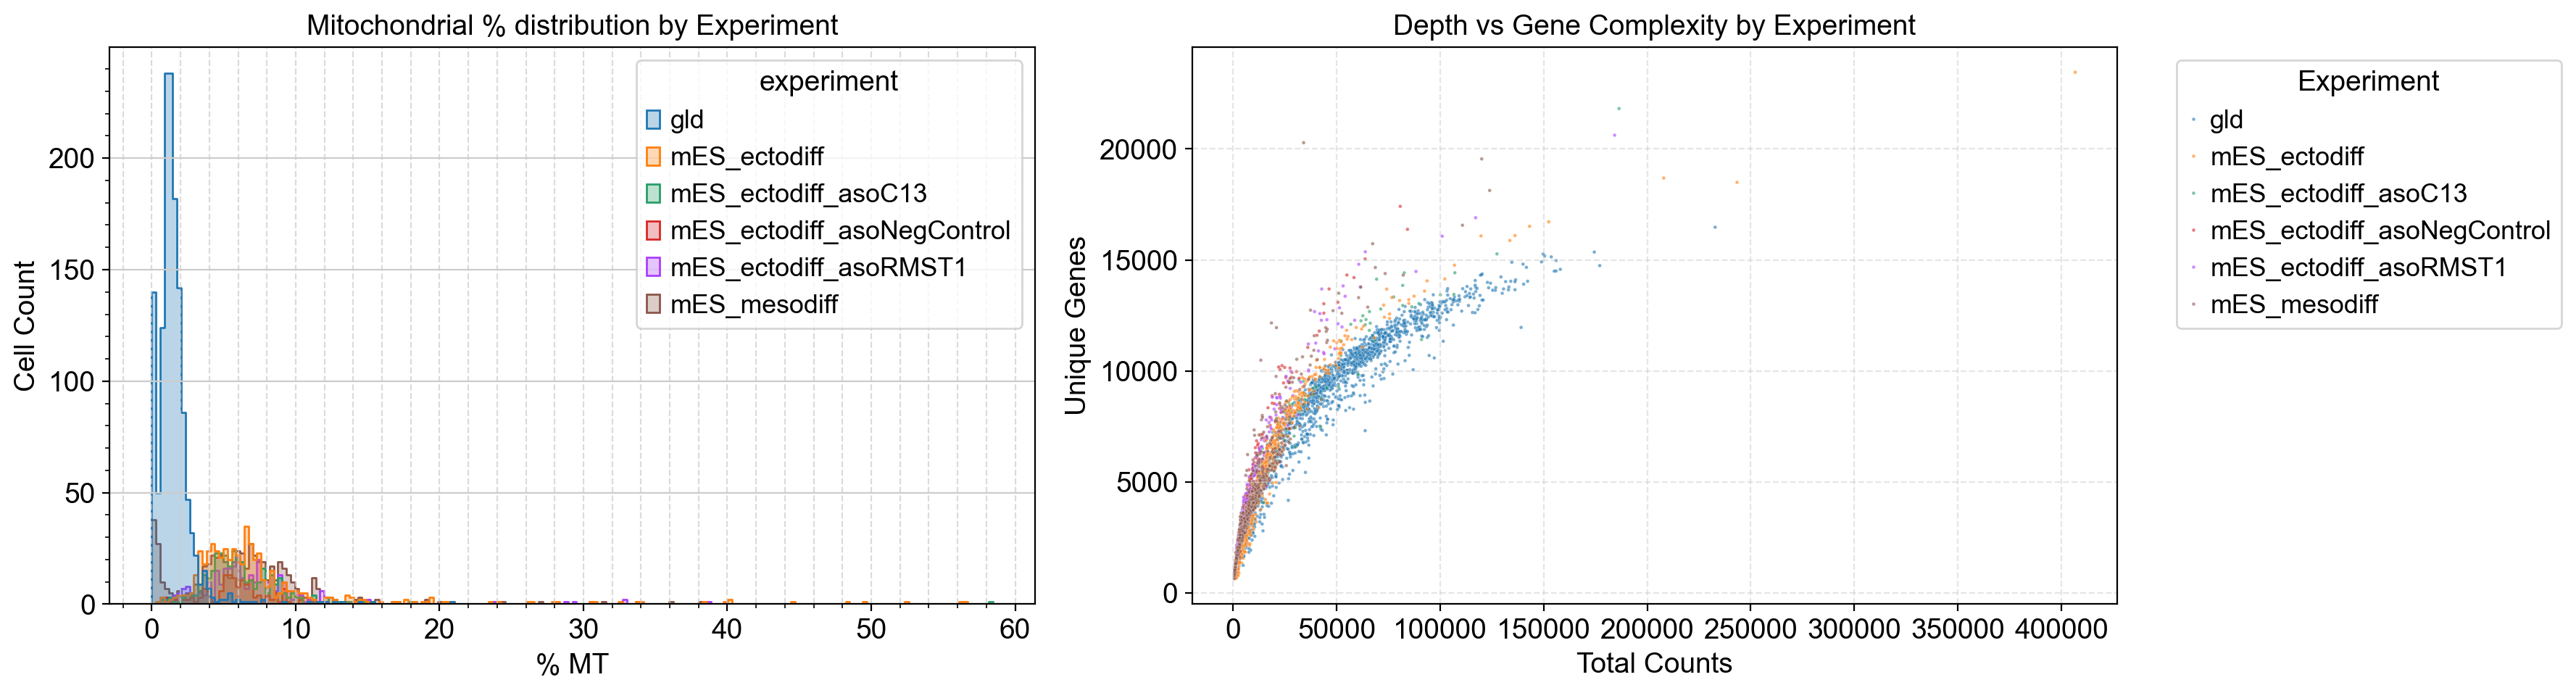

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), constrained_layout=True)

# 1. Mitochondrial % Distribution by Experiment
sns.histplot(
    data=adata.obs, 
    x='pct_counts_mt', 
    hue='experiment', 
    bins=200, 
    ax=axes[0], 
    element='step', 
    alpha=0.3
)
axes[0].set_title('Mitochondrial % distribution by Experiment')
axes[0].set_xlabel('% MT')
axes[0].set_ylabel('Cell Count')
axes[0].grid(True, which='both', axis='x', linestyle='--', alpha=0.7)
axes[0].minorticks_on()

# 2. Depth vs Gene Complexity colored by Experiment usando seaborn
sns.scatterplot(
    data=adata.obs,
    x='total_counts',
    y='n_genes_by_counts',
    hue='experiment',
    ax=axes[1],
    s=3,
    alpha=0.6
)
axes[1].set_title('Depth vs Gene Complexity by Experiment')
axes[1].set_xlabel('Total Counts')
axes[1].set_ylabel('Unique Genes')
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend(title='Experiment', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

Filter cells with > 12% mitochondrial counts

In [ ]:
# Set the mask for mitochondrial reads
mito_threshold=12
mitoribo_mask = adata.obs['pct_counts_mt'] < mito_threshold

# Execute filtering
n_before = adata.n_obs
adata = adata[mitoribo_mask, :].copy()
n_after = adata.n_obs

print(f"Filtering:")
print(f"Before: {n_before} -> After: {n_after} cells")
print(f"Removed {n_before - n_after} cells ({((n_before-n_after)/n_before)*100:.1f}%)")

Filtering:
Before: 3311 -> After: 3193 cells
Removed 118 cells (3.6%)


## SAVE DATA

In [ ]:
# --- SAVE FILTERED RAW DATA ---

# 1. Verification before saving
print(f"Saving object with {adata.n_obs} cells and {adata.n_vars} genes.")

# 2. Optimization: Remove Unused Categories
# Since we filtered cells, some 'plate' or 'experiment' categories might be empty.
# We clean metadata to save space and avoid errors later.
for col in adata.obs.columns:
    if adata.obs[col].dtype.name == 'category':
        adata.obs[col] = adata.obs[col].cat.remove_unused_categories()

# 3. Save to disk (Compressed)
# .h5ad is the HDF5 format for AnnData. Compression reduces disk size significantly.
adata.write("../data/data_filtered_raw_mito.h5ad", compression="gzip")

Saving object with 3193 cells and 244105 genes.
